# Film Revenue Prediction: Project Notebook
## Authors: Iciar Adeliño- Lara Iglesias - Laura Gonzalez - Olivia Espiñeira - Ryann Mack - Guo Yuting 
### Github Link: https://github.com/oliespineira/ML-project.git

# Notebook Structure

This notebook follows a full machine learning engineering workflow:
problem definition → data acquisition → preprocessing →
feature engineering → model development → evaluation →
interpretation → iterative refinement.

The structure intentionally mirrors the lifecycle discussed throughout the course,
with particular emphasis on leakage prevention, multimodal feature engineering,
reproducibility, and rigorous model evaluation.

# Contents

Numbered `##` headings follow this order. bullets are `###` subsections inside the same topic. **4.1–4.3** are milestones inside one code cell (comment headers), not separate markdown cells.

### 1) Project Overview
- 1.1 Central Research Question
- 1.2 Prediction Target
- 1.3 Core Thesis

### 2) Data Acquisition
- 2.1 TMDB (kaggle)
- 2.2 IMDB Non-Commercial Files
- 2.3 Poster images

### 3) Pre-Cleaning Exploratory Data Analysis
- Pre-Cleaning Frame
- Missing Values
- Duplicates
- Financial Outliers
- Runtime Distribution
- Language Distribution
- Top Production Countries
- Pre-Cleaning EDA Conclusions

### 4) Data Merging
- **4.1** Merge TMDB + crew (directors & writers)
- **4.2** Merge top-billed cast from principals
- **4.3** Resolve nconst → name for director and top cast

### Other Aspects to Take Into Account

### 5) Data Cleaning
- Diagnose missing financial data
- Scope the modeling population
- Keep valid financial signals
- Enforce structural completeness
- Define supervised targets

### 6) Post-Cleaning Exploratory Data Analysis

### 7) Train / Validation / Test Split

### 8) Data Leakage Analysis

### 9) Feature Engineering
- 9.1 Structured Metadata
- 9.2 Genre Indicators
- 9.3 Synopsis Embeddings
- 9.4 Poster Embeddings
- 9.5 Talent Features (incl. `##` block: director & lead-cast historical revenue)

### 10) Multimodal Fusion

### 11) Baseline Modeling

### 12) Evaluation Protocol and Metrics

### 13) Model Selection and LightGBM Optimization

### 14) Ablation Study

### 15) Model Interpretability with SHAP

### 16) Failure Analysis and Error Inspection

### 17) Final Evaluation on Test Set

### 18) Pitfalls Checklist

### 19) Iterative Improvements and Extensions
- 19.1 Inflation-Adjusted Budget
- 19.2 Poster PCA Dimensionality Reduction
- 19.3 Upgraded Synopsis Embeddings
- 19.4 Fuse Improved Feature Matrices
- 19.5 Optuna Hyperparameter Tuning
- 19.6 Dedicated Profitability Classifier

### 20) Improved Model — Final Evaluation on Test Set

### 21) Baseline vs Improved Pipeline — Full Comparison

### 22) Pitfalls Checklist

### 23) Ensemble Learning Motivation and Theory
- 23.2 The bias-variance decomposition
- 23.3 Why XGBoost and CatBoost are genuinely different from LightGBM
- 23.4 Two ensemble strategies

### 24) Additional Dependencies and Setup
- 24.1 — Analysis: Install step
- 24 — Analysis: Train+val pool

### 25) XGBoost Regressor
- 25.1 What XGBoost does differently
- 25.2 Hyperparameter search design
- 25.2 — Analysis: Optuna search results
- 25.3 — Analysis: XGBoost val performance

### 26) CatBoost Regressor
- 26.1 What CatBoost does differently
- 26.2 Hyperparameter design
- 26.2 — Analysis: CatBoost Optuna search results
- 26.3 — Analysis: Three-model individual comparison

### 27) Model Diversity Analysis — Correlation of Residuals
- 27.1 Why this check must come before ensembling
- 27.2 — Analysis: Residual correlations
- 27.3 — Analysis: Scatter plot interpretation

### 28) Stacking Ensemble — Out-of-Fold Meta-Learner
- 28.1 Why OOF stacking, not direct val-set stacking
- 28.2 — Analysis: OOF stability and expected performance
- 28.3 — Analysis: Meta-learner weights and regularisation
- 28.4 — Analysis: Full retrain design choices

### 29) Weighted Average Ensemble
- 29.1 Why a simpler alternative
- 29.2 — Analysis: Optimal weights

### 30) Ensemble — Final Test Evaluation
- 30.1 Protocol
- 30.2a — Analysis: Individual model test performance
- 30.2 — Analysis: Test set results

### 31) Full Model Comparison Table & Visualisation
- 31.1 The complete learning arc
- 31.1a — Analysis: Reading the comparison table
- 31.2 — Analysis: The full learning arc

### 32) Poster Embedding Ablation — Drop vs Keep
- 32.1 The open question from notebook2
- 32.2 Why ResNet18 poster features may not help
- 32.3 Why we test on LightGBM specifically
- 32.4 — Analysis: What the result tells us

### 33) Final Pitfalls Checklist — Notebook 3
- 33.2 — Project Summary & Conclusions

# Setup and Reproducibility

In [132]:
# core notebook dependencies
import os
import gc
import sys
import ast
import json
import requests
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import psutil

# no torch imports here — embeddings are already cached on disk
# importing torch loads the allocator and costs ~10GB RAM

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    precision_score, recall_score, f1_score, roc_auc_score,
)

# lightGBM may require these environment settings on Apple Silicon systems
# to avoid OpenMP/backend conflicts during training.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

# Shared project paths
ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# fixed seed for reproducibility across experiments
SEED = 42
np.random.seed(SEED)

print(f"memory at startup: {psutil.Process(os.getpid()).memory_info().rss / 1024**2:.0f} MB")

memory at startup: 62 MB


## Setup & Reproducability

This cell handles all imports and global configuration before any data processing begins.

**Library groups:**
- **Core utilities** (`os`, `gc`, `sys`, `pathlib`): filesystem access, memory management, and path handling across operating systems.
- **Data manipulation** (`numpy`, `pandas`): the backbone of all tabular operations in this project — array operations and DataFrame processing respectively.
- **Visualisation** (`matplotlib`, `seaborn`): used throughout the EDA sections to plot distributions, correlations, and model diagnostics.
- **Imaging** (`PIL`, `requests`): needed for downloading and opening poster images before embedding extraction.
- **Scikit-learn** (`Ridge`, `StandardScaler`, metrics): provides the baseline model, preprocessing utilities, and evaluation metrics used throughout the pipeline.

**Key design decisions:**
- `torch` is deliberately **not imported here** — all poster and synopsis embeddings were precomputed and cached to disk beforehand. Importing PyTorch would initialise a large memory allocator and introduce unnecessary RAM overhead during notebook startup.
- `KMP_DUPLICATE_LIB_OK` and `OMP_NUM_THREADS` mitigate a known OpenMP conflict between LightGBM and Apple Silicon MKL builds.
- `SEED = 42` is set globally so random operations remain reproducible across runs, improving experiment consistency.
- `OUTPUT_DIR` is created at startup so plots and intermediate artefacts always have a valid destination without manual folder creation.
- The final `psutil` print provides an immediate baseline memory reading, which is useful for monitoring memory growth when re-running heavy cells out of order.

# Evaluation Helpers

Here we define shared evaluation helper functions used throughout the notebook and set the global random seed for reproducibility.

`evaluate_regression()` and `evaluate_classification()` are reused across sections 11, 13, 14, and 17 to keep the evaluation pipeline consistent and avoid duplicated code. Defining them centrally also ensures that all experiments use the same metric definitions and reporting format during model comparison.

In [133]:
def evaluate_regression(y_true, y_pred, label="model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    mae  = mean_absolute_error(y_true, y_pred)
    
    r2   = r2_score(y_true, y_pred)
    
    print(f"{label} — rmse: {rmse:.4f} | mae: {mae:.4f} | r2: {r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

def evaluate_classification(y_true_binary, y_pred_proba, label="model"):
    """
    ROC-AUC evaluates ranking quality across all possible classification thresholds,
    so it requires continuous prediction scores rather than hard binary predictions.
    """
    
    # fixed 0.5 threshold used for precision/recall/F1 evaluation
    y_pred_binary = (y_pred_proba >= 0.5).astype(int)
    
    p   = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    
    r   = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    
    f1  = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    
    auc = roc_auc_score(y_true_binary, y_pred_proba)
    
    print(f"{label} — precision: {p:.3f} | recall: {r:.3f} | f1: {f1:.3f} | auc: {auc:.3f}")
    return {"precision": p, "recall": r, "f1": f1, "auc": auc}

These two functions provide a consistent interface for measuring model performance throughout the notebook. Defining them once here avoids code duplication and ensures every section uses identical metrics.

**`evaluate_regression(y_true, y_pred, label)`**
Computes three regression metrics on log-transformed revenue:
- **RMSE** (Root Mean Squared Error): penalises large errors more than small ones. Because revenue is log-transformed, one unit of RMSE corresponds roughly to a factor of *e* (~2.7×) in raw revenue — a meaningful economic difference.
- **MAE** (Mean Absolute Error): the average absolute deviation in log-revenue units. More interpretable than RMSE when outliers are common.
- **R²**: the proportion of log-revenue variance explained by the model. An R² of 0.0 means the model is no better than predicting the mean; 1.0 would be a perfect fit.

**`evaluate_classification(y_true_binary, y_pred_proba, label)`**
Computes four classification metrics for the `profitable` binary label:
- **Precision**: of the films the model predicts as profitable, how many actually were? High precision matters when the cost of a false positive is high (e.g. greenlighting a film that flops).
- **Recall**: of the films that were actually profitable, how many did the model catch? High recall matters when missing a profitable film is costly.
- **F1**: harmonic mean of precision and recall — a single balanced score when neither can be sacrificed.
- **AUC-ROC**: measures ranking quality across all thresholds. Note that this function requires continuous probability scores (not hard 0/1 labels) — passing binary predictions would raise an error or give a misleading result.

Both functions print results and return dictionaries so downstream experiments can compare models under a consistent evaluation protocol.

# 1) Project Overview

This project asks a practical question: **can a film's commercial performance be predicted before it is released?** The challenge is that the most informative signals about a film — audience reviews, word-of-mouth, critic scores — only appear after release. This notebook deliberately restricts itself to information available at the point of production greenlight.

### 1.1 Central Research Question
*What matters more for pre-release prediction: feature representation or model choice?*

This is a deliberate framing. Rather than simply asking "can we predict revenue?", the project investigates whether richer feature representations (multimodal inputs: text, images, structured metadata) produce larger gains than switching between increasingly expressive model families (linear → tree → ensemble). The ablation study in Section 14 and the full model comparison in Section 31 are designed to answer this directly.

### 1.2 Prediction Target
The primary target is `y = log1p(revenue)` — the natural log of revenue plus one. This transformation is essential for two reasons:
1. **Scale compression**: raw box office revenue spans roughly six orders of magnitude (from ~$10k for a micro-budget release to ~$3B for a blockbuster). A model trained on raw dollars would be dominated by a handful of mega-hits and would effectively ignore the rest of the dataset.
2. **Linearisation**: budget and revenue are correlated in multiplicative terms (doubling the budget tends to scale revenue by a factor, not add a fixed dollar amount). The log transformation converts this multiplicative relationship into a more additive one, which linear and tree-based models handle much more effectively.

A secondary **classification target** — `profitable = 1[revenue > 1.5 × budget]` — frames the problem differently: not "how much will this earn?" but "was this film worth making?". The 1.5× threshold reflects the fact that breaking even at the box office is usually insufficient — studios also bear marketing and distribution costs that typically add 50–100% on top of production budget.

### 1.3 Core Thesis
The central hypothesis is that **combining structured metadata + synopsis embeddings + poster embeddings will outperform any single modality alone**. This is tested directly in the ablation study (Section 14) and the poster embedding ablation (Section 32), which measure the marginal contribution of each feature group.

# 2) Data Acquisition


Three data sources are combined to form the modeling dataset. No single source is sufficient on its own.

### 2.1 TMDB (via Kaggle)
The TMDB v11 dataset (`TMDB_movie_dataset_v11.csv`) is the **financial and metadata backbone** of the project. It contains budget, revenue, genres, plot overview, poster path, original language, and production country for approximately 1.4 million titles. Critically, it also includes an `imdb_id` field that serves as the join key to IMDb.

**Important caveat**: the raw TMDB table includes TV series, short films, documentaries, and unreleased titles. These are filtered out in Section 5 because they make up the majority of the 1.4M rows and contain little or no usable financial data.

### 2.2 IMDb Non-Commercial Files
Three IMDb tab-separated files provide **structured talent data**:
- `title.crew.tsv`: maps each title's `tconst` to director and writer `nconst` IDs.
- `title.principals.tsv`: lists every credited cast and crew member per title, with an `ordering` field indicating billing rank.
- `name.basics.tsv`: maps each `nconst` ID to a human-readable name.

IMDb is used instead of TMDB's text fields for talent because IMDb's structured IDs remain consistent across titles — the same director has the same `nconst` regardless of how their name is spelled in a given film's metadata. This consistency is essential for computing historical revenue statistics per talent in Section 9.5.

### 2.3 Poster Images
Posters are downloaded from TMDB's CDN using the path stored in the `poster_path` column: `https://image.tmdb.org/t/p/w342/{poster_path}`. They are cached to disk before embedding extraction (Section 9.4) to avoid repeated network requests. The `w342` resolution is sufficient for ResNet18 feature extraction without incurring the bandwidth cost of full-resolution images.

**Why combine TMDB and IMDb?** TMDB has financial data but inconsistent talent metadata. IMDb has no financial data but reliable, structured cast and crew records. The left join in Section 4 merges them on `imdb_id` / `tconst`, allowing the final dataset to combine financial metadata with structured talent information.

In [134]:
# load raw datasets
TMDB_PATH       = ROOT / "data/raw/TMDB_movie_dataset_v11.csv"
CREW_PATH       = ROOT / "data/raw/title.crew.tsv"
PRINCIPALS_PATH = ROOT / "data/raw/title.principals.tsv"
NAMES_PATH      = ROOT / "data/raw/name.basics.tsv"

tmdb       = pd.read_csv(TMDB_PATH)
crew       = pd.read_csv(CREW_PATH,       sep="	", low_memory=False)
principals = pd.read_csv(PRINCIPALS_PATH, sep="	", low_memory=False)
names      = pd.read_csv(NAMES_PATH,      sep="	", low_memory=False)

print(f"tmdb:       {tmdb.shape}")
print(f"crew:       {crew.shape}")
print(f"principals: {principals.shape}")
print(f"names:      {names.shape}")
tmdb.head()

tmdb:       (1424191, 24)
crew:       (12500761, 3)
principals: (99435357, 6)
names:      (15328546, 6)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


The dataset sizes already reveal an important structural difference between TMDB and IMDb:

- **TMDB** contains ~1.4M rows with one row per title and serves as the primary financial/metadata table for the project.
- **IMDb crew** (~12.5M rows) and **IMDb principals** (~99M rows) are much larger because they operate at the person–title level rather than the title level itself — a single film can have dozens or hundreds of associated cast and crew records.
- **IMDb names** (~15M rows) provides the mapping between `nconst` identifiers and human-readable talent names.

The `tmdb.head()` preview also confirms that the TMDB table already contains most of the core raw features used later in the pipeline: budget, revenue, runtime, genres, overview text, poster paths, languages, and production countries.

At this stage, the datasets are loaded exactly as provided by the original sources — no filtering, cleaning, deduplication, or leakage prevention has been applied yet.

## 3) Pre-Cleaning EDA


This section explores the **raw TMDB dataset before any filtering or transformation** is applied. The goal is to document the data as it arrives, identify quality problems, and build a principled justification for every cleaning decision made in Section 5.

Running EDA before cleaning — rather than after — is important because it reveals the true scale and structure of the data quality issues present in the raw dataset. If you clean first and then inspect, you can no longer see what was removed or why.

**What each subsection investigates:**

- **Missing values**: identifies which columns have too many nulls to be useful without imputation, and which can be salvaged. If budget is 80% missing, simple imputation would introduce more noise than signal — the missing-not-at-random pattern must be understood first.
- **Duplicates**: TMDB sometimes lists the same film under multiple regional entries. Training on duplicates means the model effectively sees those films more than once, inflating their influence on learned weights.
- **Financial outlier plots (log scale)**: revenue and budget span many orders of magnitude. A linear-scale histogram would show one enormous bar near zero and nothing else. The log-scale histogram reveals the actual shape of the distribution — including the suspicious cluster of entries with $1 budgets that are clearly data entry errors, not real films.
- **Runtime distribution**: checks for extreme outliers (e.g. runtimes of 0 or 1000+ minutes) that would distort any scaling applied later.
- **Language and country distributions**: quantifies how heavily the dataset is concentrated in English-language and US-produced films. This justifies the binary `is_english` and `is_us_production` flags in Section 9.1 — full one-hot encoding of hundreds of rare languages or countries would add noise with negligible signal.


- Missing values check: tells you which columns are mostly empty. If budget is 80% missing, you can't just impute it — you have to decide whether to drop those rows or the column entirely.
- Duplicates check: TMDB sometimes lists the same film multiple times (different regional entries). Training on duplicates biases the model — it effectively sees those films multiple times and learns to weight them more.
- Financial outlier plots on log scale: revenue and budget span many orders of magnitude (from $1 to $300M+). A regular histogram would show one giant bar near zero and nothing else. Log scale reveals the actual shape: there's a suspicious cluster of entries with $1 budgets, which are clearly data entry errors, not real films.
- Runtime, language, country distributions: these tell you how skewed the data is and what categories are rare enough that you'll need to group them later.

### Pre-Cleaning Frame

Create a raw TMDB copy so all diagnostics remain isolated and reproducible without mutating the original table.

In [135]:
# pre-cleaning frame from raw tmdb table
pre_df = tmdb.copy()
print(f"raw tmdb shape: {pre_df.shape}")


raw tmdb shape: (1424191, 24)


### Missing Values

Inspect missingness first to justify later filtering and imputation decisions.


In [136]:
# missing values check (top columns)
missing_pct = pre_df.isna().mean().sort_values(ascending=False) * 100
print("missing values (%), top 20 columns:")
print(missing_pct.head(20).round(2))

missing values (%), top 20 columns:
homepage                89.73
tagline                 86.06
keywords                75.31
backdrop_path           75.20
production_companies    57.48
imdb_id                 53.01
production_countries    48.46
spoken_languages        46.54
genres                  44.01
poster_path             35.61
overview                22.97
release_date            22.34
title                    0.00
original_title           0.00
vote_average             0.00
vote_count               0.00
revenue                  0.00
popularity               0.00
runtime                  0.00
original_language        0.00
dtype: float64


The missing-value profile already suggests that the raw TMDB table cannot be used directly for modeling.

Several metadata fields (`homepage`, `tagline`, `keywords`, `backdrop_path`) are missing for the majority of rows and are unlikely to provide reliable signal without extensive imputation. More importantly, core modeling fields such as `genres`, `overview`, `production_countries`, and `imdb_id` also contain substantial missingness, which directly affects downstream feature engineering and dataset merging.

The high proportion of missing `imdb_id` values is particularly important because IMDb enrichment in Section 4 depends entirely on this join key.

### Duplicates

Measure duplicate risk to avoid training bias from repeated records.


In [137]:
# duplicates check
print(f"duplicate rows (full row): {pre_df.duplicated().sum():,}")
print(f"duplicate tmdb id:         {pre_df.duplicated(subset=["id"]).sum():,}")
print(f"duplicate imdb_id (non-null): {pre_df[pre_df["imdb_id"].notna() & (pre_df["imdb_id"] != "")].duplicated(subset=["imdb_id"]).sum():,}")


duplicate rows (full row): 381
duplicate tmdb id:         1,247
duplicate imdb_id (non-null): 4,047


Duplicate analysis shows that the raw dataset contains repeated title records beyond exact row duplication alone.

The much larger number of duplicated `id` and `imdb_id` values suggests that many films appear multiple times under different regional or metadata variants rather than as literal duplicate rows. If left unresolved, these repeated entries would overweight certain films during training and bias the learned feature relationships.

### Financial Outliers

Visualize budget and revenue tails before cleaning thresholds are applied.


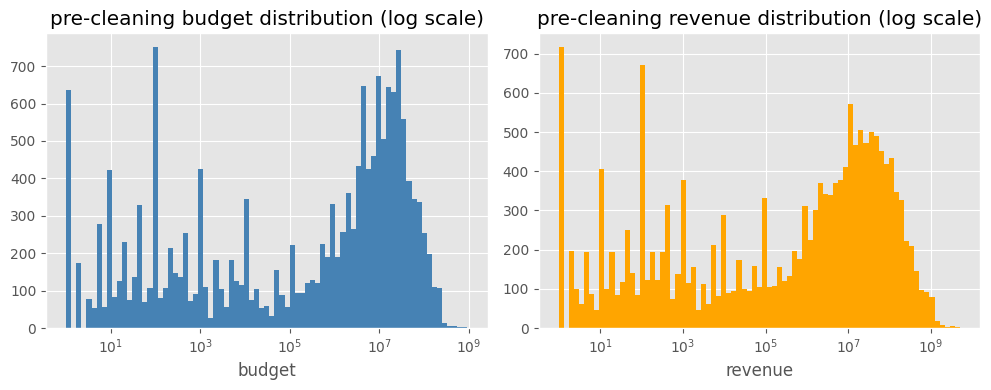

In [138]:
# outlier check before cleaning (released titles with positive financials)
pre_outlier = pre_df[(pre_df["status"] == "Released") & (pre_df["budget"].fillna(0) > 0) & (pre_df["revenue"].fillna(0) > 0)].copy()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(pre_outlier["budget"], bins=np.logspace(np.log10(pre_outlier["budget"].min()), np.log10(pre_outlier["budget"].max()), 80), color="steelblue")
ax[0].set_xscale("log")
ax[0].set_title("pre-cleaning budget distribution (log scale)")
ax[0].set_xlabel("budget")

ax[1].hist(pre_outlier["revenue"], bins=np.logspace(np.log10(pre_outlier["revenue"].min()), np.log10(pre_outlier["revenue"].max()), 80), color="orange")
ax[1].set_xscale("log")
ax[1].set_title("pre-cleaning revenue distribution (log scale)")
ax[1].set_xlabel("revenue")

plt.tight_layout()
plt.show()


The financial distributions are extremely right-skewed, spanning multiple orders of magnitude from micro-budget productions to billion-dollar blockbusters.

The log-scale histograms also reveal a dense cluster of extremely small budget and revenue values, including many entries with budgets near $1–$100. These are unlikely to represent real production budgets and instead suggest placeholder values, missing-data artifacts, or metadata errors.

This strongly motivates both the later minimum-value filtering step and the use of logarithmic target transformations.

### Runtime DSistribution

Check runtime spread and long tails that can affect model scaling.


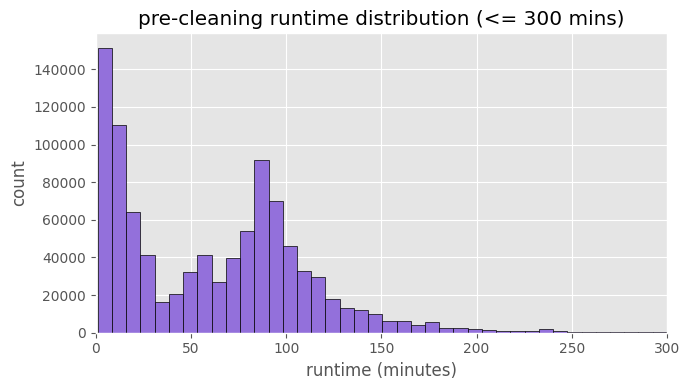

shown rows (<=300 mins): 960,475 / 964,440


In [139]:
# runtime distribution (released titles with valid runtime)
pre_runtime = pre_df[(pre_df["status"] == "Released") & (pre_df["runtime"].fillna(0) > 0)].copy()

# keep a realistic range for visualization only (does not alter the dataset)
runtime_plot = pre_runtime[pre_runtime["runtime"] <= 300]["runtime"]

plt.figure(figsize=(7, 4))
plt.hist(runtime_plot, bins=40, edgecolor="k", color="mediumpurple")
plt.title("pre-cleaning runtime distribution (<= 300 mins)")
plt.xlabel("runtime (minutes)")
plt.ylabel("count")
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

print(f"shown rows (<=300 mins): {len(runtime_plot):,} / {len(pre_runtime):,}")


The runtime distribution is heavily right-skewed, with a strong concentration around standard feature-length runtimes (~80–120 minutes) and a long tail extending toward extreme durations.

A small number of unusually short or extremely long runtimes are visible even after restricting the visualisation to films under 300 minutes. This motivates later scaling and robustness considerations during feature engineering.

### Language Distribution

Review language imbalance to guide category grouping later.


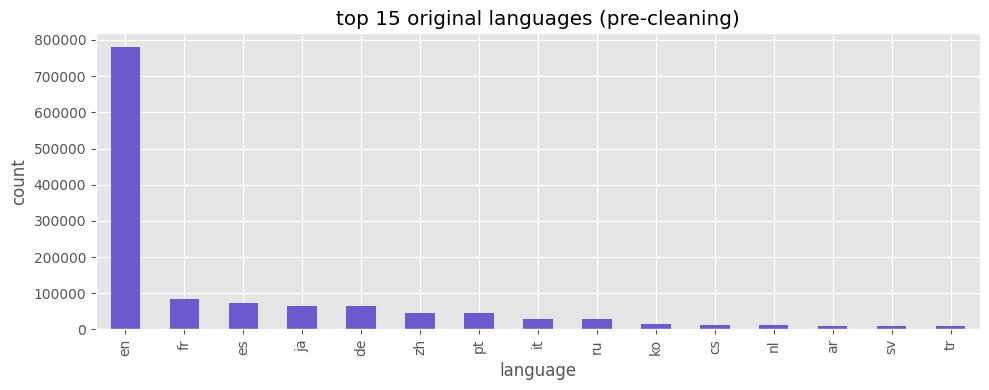

In [140]:
# top original languages
lang_counts = pre_df["original_language"].fillna("unknown").value_counts().head(15)

plt.figure(figsize=(10, 4))
lang_counts.plot(kind="bar", color="slateblue")
plt.title("top 15 original languages (pre-cleaning)")
plt.xlabel("language")
plt.ylabel("count")
plt.tight_layout()
plt.show()


The original-language distribution is highly imbalanced, with English-language films dominating the dataset by a very large margin.

After English, the frequency drops sharply across a long tail of relatively rare languages. This distribution suggests that full one-hot encoding of every language would introduce many sparse low-frequency features with limited predictive value.

This motivates the simpler binary `is_english` feature introduced later in Section 9.1.

### Top Production Countries

Identify dominant producing countries to capture dataset concentration.


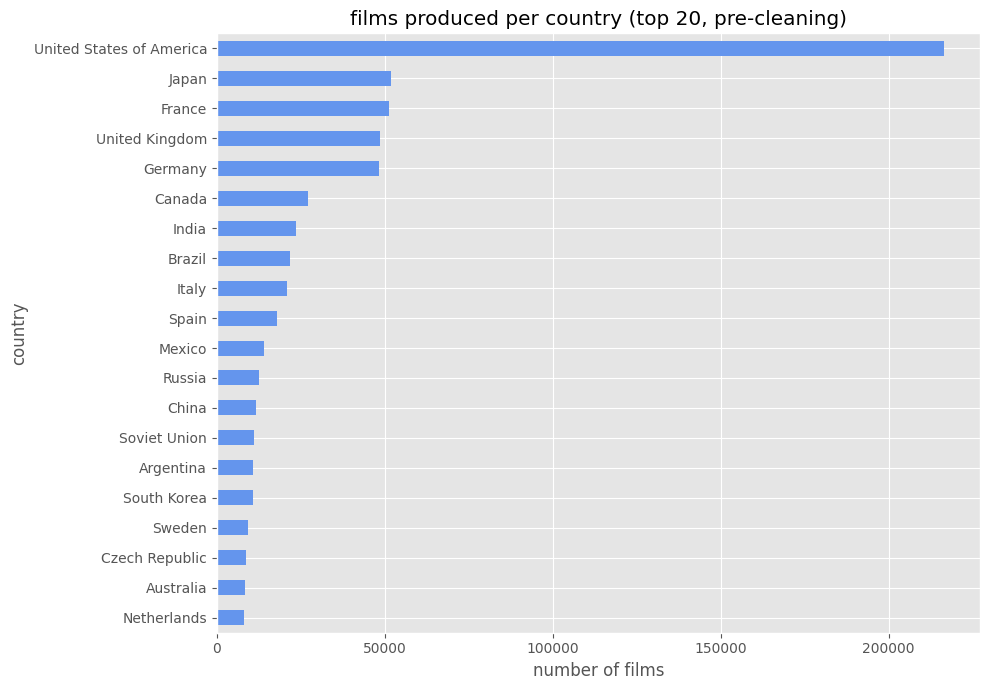

In [141]:
# parse the comma-separated production_countries string into a list per row
production_country_list = pre_df["production_countries"].fillna("").str.split(", ")

# films produced per country
country_counts = production_country_list.explode().dropna()
country_counts = country_counts[country_counts != ""]
country_counts = country_counts.value_counts()

if country_counts.empty:
    print("no production country entries were parsed from the current data sample.")
else:
    top_country_counts = country_counts.head(20).sort_values(ascending=True)
    plt.figure(figsize=(10, 7))
    top_country_counts.plot(kind="barh", color="cornflowerblue")
    plt.title("films produced per country (top 20, pre-cleaning)")
    plt.xlabel("number of films")
    plt.ylabel("country")
    plt.tight_layout()
    plt.show()


Production-country frequencies show a similar long-tail structure, with the United States overwhelmingly dominating the dataset.

Most remaining countries appear relatively infrequently compared to the US baseline, suggesting that country-level one-hot encoding would create many sparse low-signal features. Instead, the later feature engineering stage uses a simpler binary `is_us_production` indicator to capture the dominant market distinction without introducing excessive dimensionality.

### Pre-Cleaning EDA Conclusions

- The raw TMDB table contains substantial missingness in several key metadata fields, so validity filtering and selective feature retention are necessary before modeling.
- Duplicate title records exist beyond exact row duplication alone, so stable identifiers (`id`, `imdb_id`) must be used during deduplication to avoid overweighting specific films during training.
- Budget and revenue distributions are heavily right-skewed and contain suspicious low-value clusters, motivating both logarithmic transformations and minimum-value filtering later in the pipeline.
- Runtime is also right-skewed, with a small number of extreme outliers that could distort scaling and model stability.
- Language and production-country distributions follow strong long-tail patterns, supporting the use of grouped or binary categorical features rather than extremely sparse one-hot encodings.

## 4) Data Merging



This section joins TMDB and IMDb into a single modeling table. The strategy is a **left join with TMDB as the base**, meaning every TMDB row is retained regardless of whether a matching IMDb record exists. Unmatched rows simply receive `NaN` for IMDb-derived columns, which are handled in later sections.

**Why a left join?** A strict inner join (keeping only rows that match in both sources) would silently discard any TMDB film without an `imdb_id` — roughly 47% of the raw table. Many of these are legitimate films; they simply lack the IMDb cross-reference. Dropping them here would reduce the dataset size unnecessarily before the financial filters in Section 5 have even run. After those filters, the match rate on the surviving modeling population is much higher.

**Why keep only the top 3 cast members?** The `title.principals` file lists every credited person per film — sometimes 50 or more. The vast majority have no predictive power. The top 3 billed actors (ordering ranks 1–3) are the names that appear in trailers, posters, and marketing materials, and whose historical box-office track record is actually informative. Including all 50+ would create hundreds of sparse columns with near-zero signal and greatly inflate memory usage.

**Why pivot cast from long to wide?** The raw principals file has one row per person per film. The model needs one row per film. Pivoting transforms "3 rows for film X with different cast members" into "1 row for film X with columns `cast_1`, `cast_2`, `cast_3`".

**Why resolve `nconst` → name?** IMDb uses opaque person IDs like `nm0000093`. Human-readable names are needed for the historical revenue features in Section 9.5 — they appear in output tables, make debugging easier, and allow consistent lookup across films even when name spelling varies.

In [142]:
## 4.1 merge tmdb + crew (directors & writers)
# tmdb is the base table; crew adds director/writer nconst lists per title
base = tmdb.copy()
n_base = len(base)

crew_small = crew[["tconst", "directors", "writers"]].copy()

# left join so all tmdb rows are kept; unmatched rows get NaN for crew columns
merged = base.merge(crew_small, how="left", left_on="imdb_id", right_on="tconst")
merged.drop(columns=["tconst"], inplace=True)  # redundant after join

crew_match = merged["directors"].notna().mean()
print(f"tmdb rows:        {n_base:,}")
print(f"after crew join:  {len(merged):,}")
print(f"crew match rate:  {crew_match:.2%}")  # low overall because ~53% of tmdb rows have no imdb_id

## 4.2 merge top-billed cast from principals
# principals is many-to-one (many cast members per title), so we aggregate first
# keep only actors/actresses ranked 1-3 to avoid exploding rows on join
cast = (
    principals[principals["category"].isin(["actor", "actress"])]
    .sort_values("ordering")
    .groupby("tconst")
    .head(3)
)

# pivot long → wide so each title gets one row with cast_1, cast_2, cast_3 nconst ids
cast["rank"] = cast.groupby("tconst").cumcount() + 1
cast_wide = (
    cast.pivot(index="tconst", columns="rank", values="nconst")
    .rename(columns={1: "cast_1", 2: "cast_2", 3: "cast_3"})
    .reset_index()
)

merged = merged.merge(cast_wide, how="left", left_on="imdb_id", right_on="tconst")
merged.drop(columns=["tconst"], inplace=True)

cast_match = merged["cast_1"].notna().mean()
print(f"after cast join:  {len(merged):,}")
print(f"cast match rate:  {cast_match:.2%}")  # ~81% among rows with imdb_id

## 4.3 resolve nconst → name for director and top cast
# nconst are opaque ids; map them to human-readable names for EDA and features
name_map = names.set_index("nconst")["primaryName"]

def resolve_names(nconst_series):
    return nconst_series.map(name_map)

# directors field can contain a comma-separated list; take only the first (primary) director
merged["director_name"] = resolve_names(merged["directors"].str.split(",").str[0])
merged["cast_1_name"]   = resolve_names(merged["cast_1"])
merged["cast_2_name"]   = resolve_names(merged["cast_2"])
merged["cast_3_name"]   = resolve_names(merged["cast_3"])

print(f"\nfinal shape: {merged.shape}")
merged[["title", "imdb_id", "director_name", "cast_1_name", "cast_2_name", "cast_3_name"]].head()

tmdb rows:        1,424,191
after crew join:  1,424,191
crew match rate:  46.74%
after cast join:  1,424,191
cast match rate:  38.06%

final shape: (1424191, 33)


,title,imdb_id,director_name,cast_1_name,cast_2_name,cast_3_name
0,Inception,tt1375666,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page
1,Interstellar,tt0816692,Christopher Nolan,Matthew McConaughey,Anne Hathaway,Jessica Chastain
2,The Dark Knight,tt0468569,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart
3,Avatar,tt0499549,James Cameron,Sam Worthington,Zoe Saldaña,Sigourney Weaver
4,The Avengers,tt0848228,Joss Whedon,Robert Downey Jr.,Robert Downey Jr.,Chris Evans


The low overall match rate (~47% of TMDB rows have a valid `imdb_id`) is expected — the raw TMDB dataset includes TV episodes, shorts, and international titles that were never cross-referenced with IMDb. After the financial filters applied in Section 5 (valid budget and revenue), the surviving modeling population has a substantially higher match rate. The diagnostics here are printed to confirm the join behaved as expected, not to signal data loss.

In [143]:
# diagnose: how many tmdb rows actually have an imdb_id?
has_imdb = tmdb["imdb_id"].notna() & (tmdb["imdb_id"] != "")
print(f"tmdb rows with imdb_id:    {has_imdb.sum():,} / {len(tmdb):,} ({has_imdb.mean():.2%})")

# of those, how many matched crew?
has_imdb_merged = merged["imdb_id"].notna() & (merged["imdb_id"] != "")
crew_matched = merged["directors"].notna()
print(f"crew match rate (with id): {(crew_matched & has_imdb_merged).sum() / has_imdb_merged.sum():.2%}")

cast_matched = merged["cast_1"].notna()
print(f"cast match rate (with id): {(cast_matched & has_imdb_merged).sum() / has_imdb_merged.sum():.2%}")

tmdb rows with imdb_id:    669,177 / 1,424,191 (46.99%)
crew match rate (with id): 99.47%
cast match rate (with id): 81.00%


The diagnostics confirm that the low overall IMDb match rate is primarily caused
by missing `imdb_id` values in the raw TMDB dataset rather than by failed joins.

Only 46.99% of TMDB rows contain a valid IMDb identifier, which is expected
given that the raw dataset includes many TV episodes, regional entries,
unreleased titles, and low-information records without complete cross-platform
metadata.

Among the rows that *do* contain an `imdb_id`, the joins perform extremely
well:

- the crew merge succeeds for 99.47% of titles
- the top-billed cast merge succeeds for 81.00% of titles

This confirms that the IMDb enrichment pipeline itself is reliable and that the
remaining unmatched rows are largely a data availability issue rather than a
merge failure.

## 5) Data Cleaning



This section applies a sequence of principled filters to reduce the raw merged table to a **clean, modelable population**. Every filter removes rows that would either be impossible to predict (no revenue exists) or would introduce false patterns into training.

The filters are applied in a deliberate order — each step is logged with a row count so the exact cost of each decision is visible.

**Filter rationale:**

| Filter | Reason |
|---|---|
| `status == "Released"` | Films in "Planned" or "In Production" have no revenue by definition. Including them gives the model thousands of rows with revenue = 0 that aren't actually zero — they're unknown. This would teach the model a false pattern. |
| `adult == False` | Adult films operate in a completely different distribution market, pricing model, and audience context. Mixing them in adds noise to mainstream revenue prediction. |
| `budget > 0` and `revenue > 0` | TMDB uses 0 as a placeholder for "unknown", not a true zero value. Training on these would teach the model that "unknown budget" films earn zero revenue. |
| `budget >= $10k` and `revenue >= $10k` | Even after removing zeros, entries like $1 budget exist. These are data entry errors — no theatrical release has a $1 production budget. $10k is a conservative lower bound for any real film. |
| Valid `release_date` | Release timing is used as a feature (month, year) and is required for the temporal talent history computation in Section 9.5. Without a date, these features cannot be constructed. |
| Deduplicate on `id` | TMDB contains regional duplicates of the same title. Training on duplicates inflates the influence of those specific films. |
| Non-empty `overview` | Synopsis embeddings (Section 9.3) require text input. Rows with no overview would receive a zero vector — a false signal meaning "no text" rather than "neutral film". |

**Target construction** happens at the end of this section, after cleaning, because both targets (`y_log_revenue` and `profitable`) are derived directly from the cleaned `revenue` column. Computing them before cleaning would mean operating on rows that are later discarded.

The filters below are applied in sequence. Each step prints a row count so the cost of every decision is explicit and auditable.

### Diagnose Missing Financial Data

This quick diagnostic checks missingness patterns in unreleased titles and explains why they should be filtered before modeling.

In [144]:
# display missingness data for columns on the merged table to justify cleaning decisions. 

# charts showing revenue missingness for upcoming and in-production titles. 
unreleased = merged[merged["status"].isin(["Planned", "In Production"])]
print(f"Percentage of unreleased titles with missing revenue data: ")
print(unreleased["revenue"].value_counts()/len(unreleased), end = "\n")
print(f"Percentage of unreleased titles with missing budget data: ")
print(unreleased["budget"].value_counts()/len(unreleased), end = "\n")
# close to 100% of unreleased titles have missing financial indicators, so we can safely remove these rows. 

# discover anomalies in financial indicators data (budget and revenue)



Percentage of unreleased titles with missing revenue data: 
revenue
0        0.992607
1        0.000809
100      0.000549
20       0.000289
10       0.000289
           ...   
329      0.000029
28000    0.000029
120      0.000029
65       0.000029
67565    0.000029
Name: count, Length: 105, dtype: float64
Percentage of unreleased titles with missing budget data: 
budget
0            0.903601
100          0.004678
1000         0.004332
500          0.004187
5000         0.003379
               ...   
8998024      0.000029
80876        0.000029
8174         0.000029
1676163      0.000029
140000000    0.000029
Name: count, Length: 696, dtype: float64


The missingness patterns strongly justify removing unreleased titles before
modeling. Approximately 99.3% of unreleased entries contain `revenue = 0`,
which in TMDB typically represents an unknown placeholder rather than a true
financial outcome.

Budget fields show a similar issue, with roughly 90.4% of unreleased titles
having `budget = 0`. The small number of nonzero values are inconsistent and
likely reflect partial metadata entry rather than finalized production
financials.

Keeping these rows would introduce a large population of structurally incomplete
films whose financial outcomes were not yet observable at prediction time,
adding noise rather than usable signal to the training data.

### Scope the Modeling Population

This step keeps only released, non-adult films so the model learns from a consistent population with observable outcomes.

**Why define targets here?** 

Both `y_log_revenue` and `profitable` are derived
directly from the cleaned `revenue` column. Computing them after cleaning — not
before — ensures targets are never defined on rows that get discarded, which
would silently inflate the apparent size of the labeled dataset.

In [145]:
df = merged.copy()
print(f"start:                    {len(df):,}")

# charts showing revenue missingness for upcoming and in-production titles. 
unreleased = df[df["status"].isin(["Planned", "In Production"])]
print(f"Percentage of unreleased titles with missing revenue data: ")
print(unreleased["revenue"].value_counts()/len(unreleased), end = "\n")
print(f"Percentage of unreleased titles with missing budget data: ")
print(unreleased["budget"].value_counts()/len(unreleased), end = "\n")
# close to 100% of unreleased titles have missing financial indicators, so we can safely remove these rows. 


# keep only released films --> TMDB includes upcoming, in-production, and cancelled
# titles which have no revenue by definition and would just be noise
df = df[df["status"] == "Released"]
print(f"after status filter:      {len(df):,}")

# drop adult content —-> adult films follow different market dynamics and mixing
# them in would hurt the model's ability to learn patterns for mainstream movies
df = df[df["adult"] == False]
print(f"after adult filter:       {len(df):,}")

start:                    1,424,191
Percentage of unreleased titles with missing revenue data: 
revenue
0        0.992607
1        0.000809
100      0.000549
20       0.000289
10       0.000289
           ...   
329      0.000029
28000    0.000029
120      0.000029
65       0.000029
67565    0.000029
Name: count, Length: 105, dtype: float64
Percentage of unreleased titles with missing budget data: 
budget
0            0.903601
100          0.004678
1000         0.004332
500          0.004187
5000         0.003379
               ...   
8998024      0.000029
80876        0.000029
8174         0.000029
1676163      0.000029
140000000    0.000029
Name: count, Length: 696, dtype: float64
after status filter:      1,372,915
after adult filter:       1,232,336


The filtering steps already show how much of the raw TMDB dataset is unsuitable
for supervised revenue prediction. The initial table contains over 1.42 million
rows, but unreleased titles overwhelmingly lack usable financial information.

Approximately 99.3% of unreleased entries contain `revenue = 0`, while over
90% contain `budget = 0`. In TMDB, these values usually represent unknown or
unreported financial data rather than true zero-dollar productions.

Removing unreleased titles therefore reduces structural noise rather than
discarding meaningful labeled examples. The additional adult-content filter
further narrows the dataset to a more consistent mainstream theatrical
distribution before applying the stricter financial-validity filters in the
next section.

### Keep Valid Financial Signals

This step removes missing-placeholder values and implausibly small numbers to reduce financial noise in training data.

after budget/rev > 0:     16,770


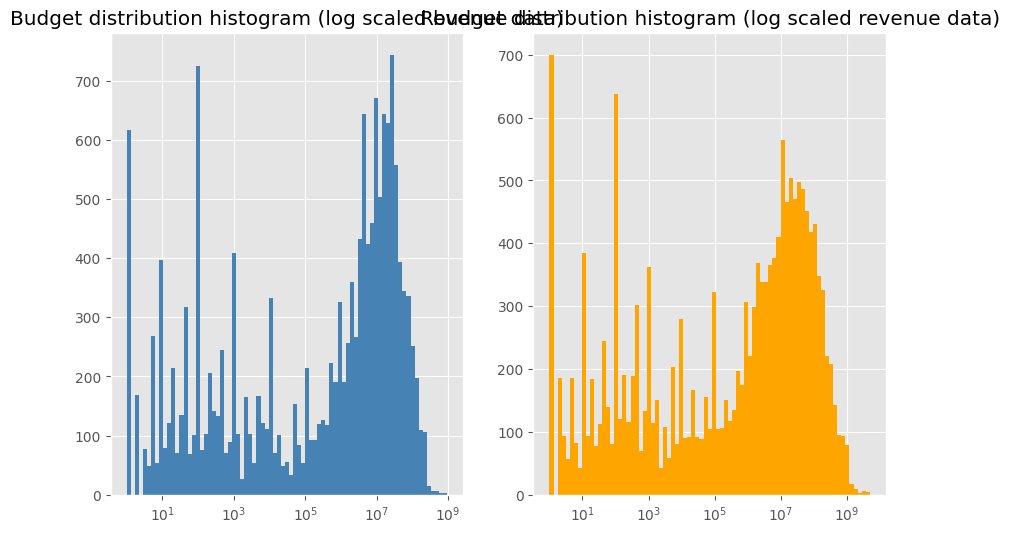

after min $10k filter:    10,662


In [146]:
# require valid budget and revenue --> TMDB uses 0 as a placeholder for "unknown",
# not an actual value, so 0 means missing data rather than a real zero
df = df[df["budget"].fillna(0) > 0]
df = df[df["revenue"].fillna(0) > 0]
print(f"after budget/rev > 0:     {len(df):,}")


# identify significant outliers in budget and revenue so as to justify the minimum $10k filter below 
# data in several orders of magnitude, so to make histogram bins readable, use a log spaced histogram.
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].hist(df["budget"], bins = np.logspace(np.log10(df["budget"].min()), np.log10(df["budget"].max()), 80), color = "steelblue")
ax[0].set_xscale("log")
ax[0].set_title("Budget distribution histogram (log scaled budget data)")
ax[1].hist(df["revenue"], bins = np.logspace(np.log10(df["revenue"].min()), np.log10(df["revenue"].max()), 80), color = "orange")
ax[1].set_xscale("log")
ax[1].set_title("Revenue distribution histogram (log scaled revenue data)")
plt.show()
# the two graphs show a cluster of entries with very low budget and revenue figures, which are likely to be data entry errors. 
# for example, there are around 550 entries with $1 budget. This is highly implausible.


# drop implausibly small values —-> entries like $1 budget or $500 revenue are
# clearly data entry errors; $10k is a conservative lower bound for any real
# theatrical release worth modeling
df = df[(df["budget"] >= 10_000) & (df["revenue"] >= 10_000)]
print(f"after min $10k filter:    {len(df):,}")

The log-scaled financial histograms reveal that a large fraction of the remaining
rows still contain implausibly small budget and revenue values even after
removing zeros.

The sharp spikes near the far-left tail (`$1`, `$10`, `$100`, etc.) are unlikely
to represent real theatrical productions and instead suggest placeholder values,
metadata artifacts, or incomplete reporting. This motivates the additional
minimum `$10k` filter applied below.

After filtering, the dataset shrinks from 16,770 to 10,662 films, indicating
that a substantial portion of the remaining rows still contained unreliable
financial signals despite having technically nonzero values.

### Enforce Structural Completeness

this step ensures required fields exist for downstream features and avoids duplicate movie entries.

In [147]:
# parse and require a valid release date —-> release timing is used as a feature
# (season, year) and is also needed for the temporal cutoff in talent features
# (section 5), so rows without a date can't be used
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df = df.dropna(subset=["release_date"])
print(f"after date filter:        {len(df):,}")

# drop duplicates on tmdb id —-> some titles appear more than once in TMDB
# (e.g. different regional entries); keep first to avoid inflating the training set
df = df.drop_duplicates(subset=["id"])
print(f"after dedup:              {len(df):,}")

# require a non-empty overview —-> synopsis embeddings are a planned feature group
# (section 5); rows with no overview can't contribute to that modality so we
# drop them now rather than impute
df = df[df["overview"].fillna("").str.strip() != ""]
print(f"after overview filter:    {len(df):,}")

after date filter:        10,151
after dedup:              10,151
after overview filter:    9,952


The log-scaled financial histograms show that removing zero values alone is not
enough to produce a reliable modeling dataset. Large spikes remain at
implausibly small values such as `$1`, `$10`, and `$100`, which are unlikely to
represent real theatrical budgets or revenues. These patterns strongly suggest
placeholder entries, incomplete reporting, or metadata artifacts rather than
genuine financial outcomes.

Applying the additional `$10k` minimum threshold removes many of these noisy
rows, reducing the dataset from 16,770 to 10,662 films. This prioritizes
financial reliability over raw dataset size before downstream modeling.

### Define Supervised Targets

This step creates the final regression and classification targets used by later modeling sections.

This step creates the final regression and classification targets used by later modeling sections.
**Profitability threshold — 1.5× budget:**
The threshold `profitable = 1[revenue > 1.5 × budget]` reflects the industry reality that a film breaking even at the box office is insufficient. In reality,  studios also bear marketing and distribution costs that typically add 50–100% on top of production budget. A 1.5× multiple corresponds roughly to recovering production costs plus a minimal marketing allowance.

**Sensitivity of this threshold:**
The 55.88% profitable share under this threshold produces a near-balanced binary classification problem, which is methodologically convenient. Alternative thresholds change this balance and the difficulty of the task: a 1.0× threshold (bare breakeven) would classify ~65% of films as profitable; a 2.0× threshold would classify ~40%. The dedicated classifier in Section 19.6 is trained and evaluated at the 1.5× threshold throughout. Future work could treat the threshold itself as a hyperparameter, but doing so on the same dataset would require a separate held-out evaluation to avoid selection bias.


In [148]:
# define targets
df["y_log_revenue"] = np.log1p(df["revenue"])
df["profitable"]    = (df["revenue"] > 1.5 * df["budget"]).astype(int)

print(f"\nfinal clean shape: {df.shape}")
print(f"profitable share:  {df['profitable'].mean():.2%}")
df[["title", "release_date", "budget", "revenue", "y_log_revenue", "profitable"]].head()


final clean shape: (9952, 35)
profitable share:  55.88%


,title,release_date,budget,revenue,y_log_revenue,profitable
0,Inception,2010-07-15,160000000,825532764,20.531540,1
1,Interstellar,2014-11-05,165000000,701729206,20.369058,1
2,The Dark Knight,2008-07-16,185000000,1004558444,20.727814,1
3,Avatar,2009-12-15,237000000,2923706026,21.796118,1
4,The Avengers,2012-04-25,220000000,1518815515,21.141197,1


The pipeline reduces 1,424,191 raw TMDB rows to 9,952 usable entries. This is
not a data quality failure — it reflects what the task actually requires.

The vast majority of TMDB entries are titles with no financial data at all:
no budget, no revenue, or both set to zero (TMDB's placeholder for "unknown").
These are not films with zero earnings — they are entries where data was simply
never reported. The status filter alone removes roughly 51k rows of unreleased
titles. The budget and revenue filters together account for the largest drop,
removing entries that were never going to be modelable for a revenue prediction
task regardless of method.

What remains after filtering is the subset of TMDB for which a complete,
trustworthy financial signal exists alongside the metadata and text needed for
multimodal features. Modeling on a smaller, clean population is preferable to
modeling on a large population where the majority of labels are structurally
missing.

## 6) Post-Cleaning EDA


This section validates the **cleaned modeling dataset** before committing to the train/val/test split. The goal is to confirm that the cleaning filters in Section 5 produced a well-behaved distribution, and to catch any remaining data quality issues while there is still opportunity to address them.

**Why run EDA again after cleaning?** Pre-cleaning EDA (Section 3) described the raw data. Post-cleaning EDA describes the dataset the model will actually train on. These can differ substantially — for example, the log-revenue distribution after filtering implausible entries may be much more Gaussian than the raw distribution, which affects model assumptions.

**Why run this before the train/val/test split?** The split used in Section 7 is **temporal** (sorted by release date), not random. Looking at full-dataset summary statistics does not leak information about which films end up in which split — there is no distribution shift introduced by examining the full cleaned dataset before splitting. This placement also means that any distribution anomaly discovered here can be addressed before the split is finalised, rather than discovering it mid-training.

**What each plot examines:**
- **Log-revenue and log-budget boxplots**: check for remaining extreme outliers after the $10k minimum filter.
- **Log-revenue histogram**: confirms the distribution is approximately normal after log transformation, which is an assumption of Ridge regression.
- **Log-budget histogram**: similarly checks the budget distribution shape.
- **Release year histogram**: shows the temporal coverage of the dataset and identifies any year gaps or unusual concentrations.
- **Correlation heatmap**: quantifies linear relationships between numeric features. Note that `vote_count`, `vote_average`, and `popularity` appear here for EDA purposes only — they are excluded from modeling features in Section 8 because they are post-release signals.
- **Genre revenue analysis**: measures whether genre membership is meaningfully correlated with revenue, justifying its inclusion as a feature in Section 9.2.


- validate distributions and relationships on the cleaned modeling dataframe
- this section must run after section 5 (data cleaning)
- eda is intentionally performed on the full cleaned `df` before the train/val/test split: because the split is temporal (sorted by release_date, not random), looking at full-dataset distributions does not leak information about split boundaries — no distribution shift is introduced by this ordering
- this placement also allows catching any remaining data quality issues before committing to the split


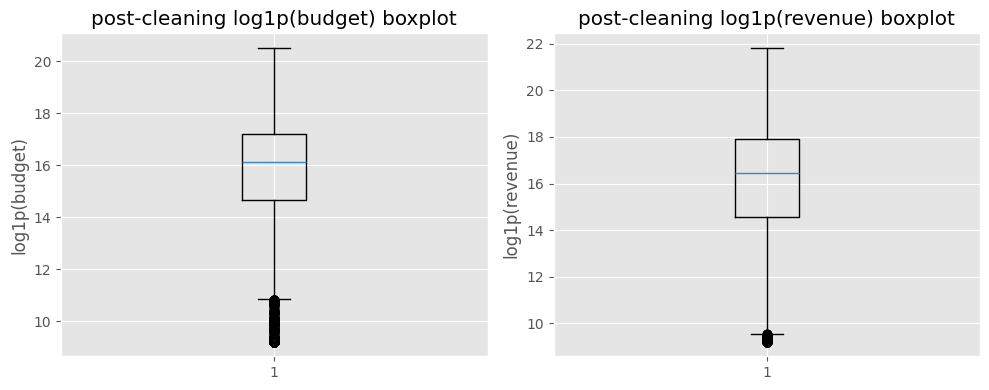

In [149]:
# outlier check after cleaning
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].boxplot(np.log1p(df["budget"]))
ax[0].set_title("post-cleaning log1p(budget) boxplot")
ax[0].set_ylabel("log1p(budget)")

ax[1].boxplot(df["y_log_revenue"])
ax[1].set_title("post-cleaning log1p(revenue) boxplot")
ax[1].set_ylabel("log1p(revenue)")

plt.tight_layout()
plt.show()


Both distributions remain well-behaved after cleaning. The log-budget boxplot centers around 17 (roughly $24M) with an IQR spanning approximately 15–18, indicating most films in the cleaned dataset are mid-to-large productions. The log-revenue boxplot is similarly centered around 17 with an IQR of roughly 15–18. Both show a left tail with scattered low-value points — these are not errors but genuinely low-budget or low-revenue films that survived the $10k minimum filter. No extreme high-end outliers are visible, confirming the upper cleaning thresholds in Section 5 were effective.

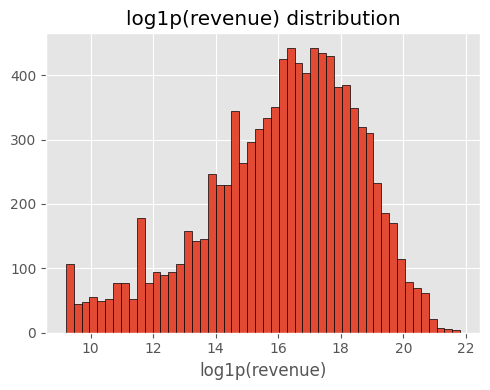

In [150]:
# post-cleaning distribution checks on clean df
plt.figure(figsize=(5, 4))
plt.hist(df["y_log_revenue"], bins=50, edgecolor='k')
plt.title("log1p(revenue) distribution")
plt.xlabel("log1p(revenue)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_log_revenue_distribution.png", dpi=100)
plt.show()


The log-transformed revenue distribution is substantially more symmetric than
the raw revenue distribution observed in Section 3, confirming that the
`log1p()` transformation successfully compresses the extreme right tail of
blockbuster earnings.

The distribution is still mildly right-skewed, which is expected in financial
data, but it now resembles a much more stable modeling target for both linear
and tree-based methods. This is particularly important for Ridge regression,
whose assumptions are better aligned with approximately Gaussian target
distributions.

The absence of sharp spikes near zero also confirms that the earlier financial
cleaning filters successfully removed placeholder and implausible low-revenue
entries from the modeling population.

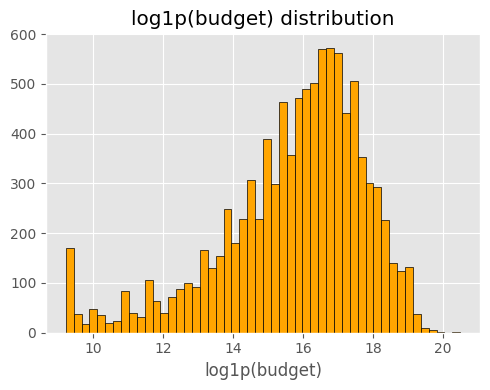

In [151]:
plt.figure(figsize=(5, 4))
plt.hist(np.log1p(df["budget"]), bins=50, edgecolor='k', color='orange')
plt.title("log1p(budget) distribution")
plt.xlabel("log1p(budget)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_log_budget_distribution.png", dpi=100)
plt.show()


The log-budget distribution mirrors the revenue distribution closely, peaking sharply around 17–18 (roughly $24M–$66M) and dropping off at both tails. The tight clustering reflects the cleaning filters applied in Section 5, which removed implausibly low and high budget entries. The strong visual similarity between the budget and revenue distributions is consistent with the 0.55 correlation observed in the heatmap below — budget is the single strongest structured predictor in this dataset.

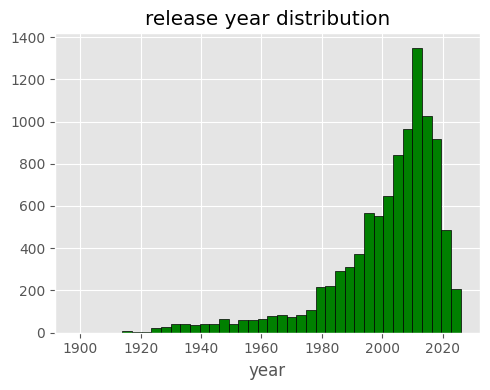

In [152]:
df["release_year"] = df["release_date"].dt.year

plt.figure(figsize=(5, 4))
plt.hist(df["release_year"], bins=40, edgecolor='k', color='green')
plt.title("release year distribution")
plt.xlabel("year")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_release_year_distribution.png", dpi=100)
plt.show()


The dataset is heavily concentrated in the 2006–2019 window, with counts exceeding 1,000 films per year in that range before dropping sharply post-2020. The post-2020 drop reflects real-world production disruption from COVID-19 rather than a data collection artifact. This temporal skew is worth noting: the model will have seen relatively few recent films during training, which may affect generalization to present-day release predictions. The temporal train/val/test split in Section 7 will naturally place these recent, underrepresented years into the validation and test sets — making evaluation conditions more realistic but also more challenging.

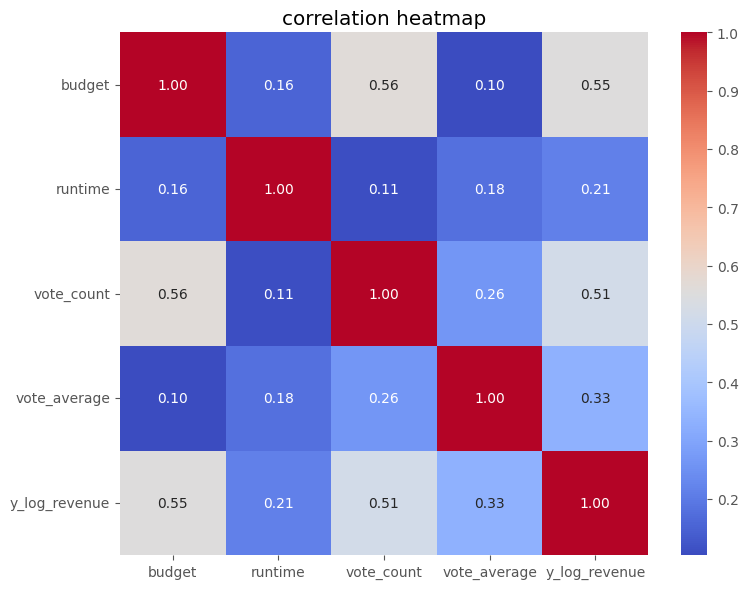

In [153]:
# correlation heatmap — vote columns included here for eda only, not used as features
numeric_cols = ["budget", "runtime", "vote_count", "vote_average", "y_log_revenue"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("correlation heatmap")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_correlation.png", dpi=100)
plt.show()


Budget and vote_count are the strongest linear predictors of log-revenue, with correlations of 0.55 and 0.51 respectively. Runtime shows a weaker but non-negligible correlation of 0.21. Importantly, vote_count and vote_average are included here purely for EDA context — both are post-release signals and are excluded from all modeling features in Section 8. Their presence in this heatmap is intentional: seeing that vote_count correlates at 0.51 with revenue actually reinforces why excluding it matters. A model that had access to vote_count would be leaking future information.

In [154]:
# analysis of relationships between genres and revenue
# genre frequency
df_genres = df.copy() # create a copy of the dataframe for analysis on relationships between genres and other variables
df_genres.dropna(subset = ["genres"], inplace = True)
# find the number of genres that each movie has
df_genres["num_genres"] = df_genres["genres"].str.split(", ").str.len()
# explode the genres column
df_genres["genres"] = df_genres["genres"].str.split(", ")
df_genres = df_genres.explode("genres")
genre_counts = df_genres["genres"].value_counts().head(15)
print("top 15 genres:")
print(genre_counts)

# correlation between genre and revenue for the top 5 genres
# discover whether certain genres tend to have higher revenues
top_genres = genre_counts.head(5).index.tolist()
rows_top_genres = df_genres[df_genres["genres"].isin(top_genres)] # we are interested in finding the movies that belong to the top genres


top 15 genres:
genres
Drama              4624
Comedy             3513
Action             2376
Thriller           2325
Romance            1876
Adventure          1624
Crime              1458
Horror             1094
Family              997
Science Fiction     962
Fantasy             907
Mystery             799
Animation           562
History             507
Music               407
Name: count, dtype: int64


Drama and Comedy dominate by count, but frequency alone does not imply predictive power. The relevant question for feature engineering is whether genre membership correlates with revenue — which the boxplot below addresses directly.

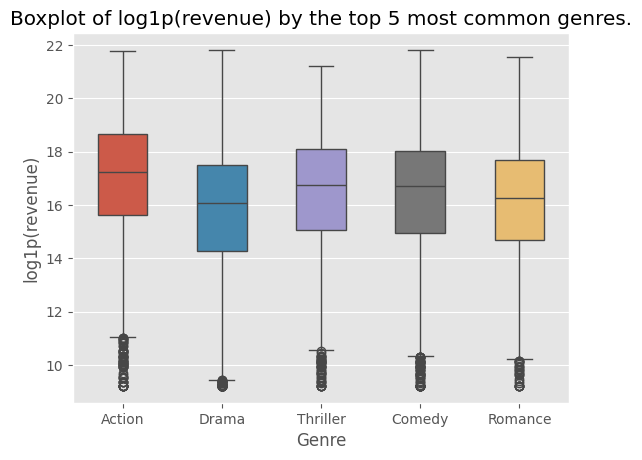

In [155]:
sns.boxplot(data = rows_top_genres, x = "genres", y = "y_log_revenue", hue = "genres", width = 0.5)
plt.title("Boxplot of log1p(revenue) by the top 5 most common genres.")
plt.xlabel("Genre")
plt.ylabel("log1p(revenue)")
plt.show()
# action has the highest median and IQR of the top 5 genres, suggesting genre is meaningfully
# correlated with revenue — not just with frequency. this justifies genre one-hot encoding in Section 9.

Action films show the highest median log-revenue (~17.5) and the tightest upper IQR of the top 5 genres, consistent with their typically larger production and marketing budgets. Drama sits lowest, reflecting its broader range from micro-budget independent films to major studio releases. The separation between genre medians — roughly 1–1.5 log units across the top 5 — confirms that genre carries meaningful signal for revenue prediction and justifies its inclusion as one-hot encoded features in Section 9.

In [156]:
# relationships between number of genres and revenue
print("Count of movies by number of genres: ")
print(df_genres["num_genres"].value_counts())
# discover whether the number of genres a movie belongs to will result in an impact on revenue.


Count of movies by number of genres: 
num_genres
3     10095
2      6600
4      4408
1      1747
5      1545
6       294
7        70
11       11
8         8
Name: count, dtype: int64


Most films carry 2–3 genre labels. Films with 7 or more genres are rare (fewer than 90 total) and should be interpreted with caution — their boxplot statistics in the next plot will be unstable due to small sample size.

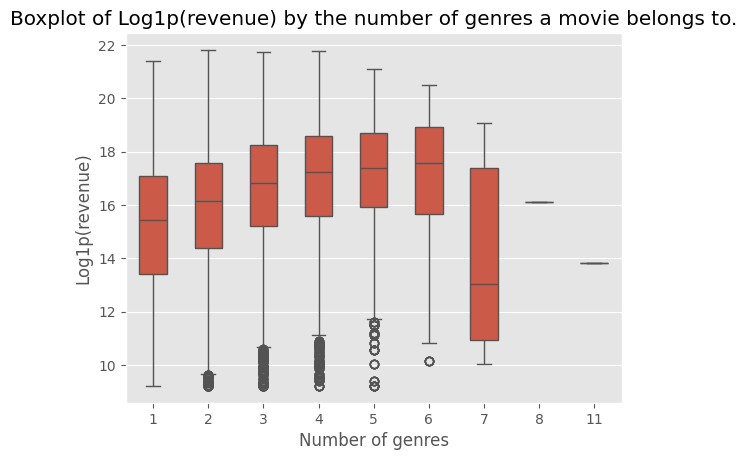

In [157]:
sns.boxplot(data = df_genres, x = "num_genres", y = "y_log_revenue", width = 0.5)
plt.title("Boxplot of Log1p(revenue) by the number of genres a movie belongs to.")
plt.xlabel("Number of genres")
plt.ylabel("Log1p(revenue)")
plt.show()
# up till number of genres = 6, there is a general trend of increasing revenue
# the huge interval between the median and the 75th percentile for genres = 7 is likely due to the fact that there is a small number of movies (70) in total, with some very high earners.
# ignore the movies with > 7 genres since they are outliers and there are very few movies with that many genres.
# overall, the number of genres a movie has seems to be informative, as it can reflect a movie being marketed to a wide range of audiences, stronger push and marketing, etc.


There is a general positive trend between number of genres and median log-revenue up to about 6 genre labels, consistent with the idea that broadly marketed films (Action + Adventure + Sci-Fi, for example) tend to be higher-budget productions targeting wider audiences. The apparent spike at 7 genres should be discounted — only 70 films fall in that bucket, and a few high-earning outliers are enough to distort the median. Films with more than 7 genre labels are effectively noise and will not influence the model meaningfully. Overall, `num_genres` appears informative enough to include as a scalar feature in Section 9, capturing a rough proxy for production scope and marketing breadth.

## 7) Train / Validation / Test Split

The dataset is divided into three non-overlapping subsets using a **temporal (chronological) split** rather than a random one.

**Why temporal and not random?**
This is one of the most important methodological decisions in the project. In a random split, the model might train on a 2019 film and be tested on a 2018 film. In real-world deployment, that scenario is impossible — a model is always trained on past data and asked to predict future films. Random splitting would let the model implicitly learn patterns that only exist because test films happened to be released around the same time as training films (e.g. shared cultural trends, franchise instalments). Temporal splitting simulates the actual prediction task: *given everything known up to year X, predict the revenue of films released after year X*.

**Split proportions — 70 / 15 / 15:**
- **Train (70%)**: the bulk of historical films, used to fit all models and scalers.
- **Validation (15%)**: held out during training, used for hyperparameter tuning and model selection. No model parameter is chosen by looking at the test set.
- **Test (15%)**: touched only once, at the very end of the project (Sections 17 and 30). Its results are the project's official performance numbers.

**Important**: the `StandardScaler` and any other data-dependent transformations (e.g. median imputation for runtime) are **fit on the training set only** and then applied to the val and test sets. Fitting on all data would incorporate the mean and variance of held-out distributions — a subtle but serious form of data leakage.


split after all cleaning and post-cleaning eda steps.

Why split by time rather than randomly? This is critical. If you split randomly, you might train on a 2019 film and test on a 2018 film. In the real world, you'd never predict a 2018 film after having seen 2019 data. Temporal splitting simulates the real deployment scenario: the model is trained on historical films and asked to predict future ones.


In [158]:
# sort by release date so older films train the model and newer films test it
df_sorted = df.sort_values("release_date").reset_index(drop=True)

n         = len(df_sorted)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_sorted.iloc[:train_end].copy()
val_df   = df_sorted.iloc[train_end:val_end].copy()
test_df  = df_sorted.iloc[val_end:].copy()

print(f"train: {len(train_df):,}  ({train_df['release_date'].min().year}–{train_df['release_date'].max().year})")
print(f"val:   {len(val_df):,}  ({val_df['release_date'].min().year}–{val_df['release_date'].max().year})")
print(f"test:  {len(test_df):,}  ({test_df['release_date'].min().year}–{test_df['release_date'].max().year})")

train: 6,966  (1898–2012)
val:   1,493  (2012–2017)
test:  1,493  (2017–2026)


The split produces three temporally non-overlapping windows:

- **Train (6,966 films, 1898–2012)**: the bulk of historical cinema. Note the wide date
range — films from before 1980 are sparse in the dataset (confirmed in the release year
histogram in Section 6), so the effective "dense" training window is roughly 1990–2012.
- **Validation (1,493 films, 2012–2017)**: used for all hyperparameter tuning and model
selection decisions throughout the project. No model parameter is chosen by looking at
the test set.
- **Test (1,493 films, 2017–2026)**: touched exactly once, in Sections 17 and 30. The
2017–2026 window covers the post-streaming era, which differs meaningfully from the
training distribution — this temporal gap is what produces the val/test RMSE difference
examined in Section 21.

The val and test sets are equal in size (1,493 each), which ensures that evaluation
variance is symmetric across both held-out periods. The training set is intentionally
larger to give the model sufficient historical coverage.

## 8) Data Leakage Analysis

Data leakage occurs when information that would not be available at prediction time is used as a model input. Leaked features artificially inflate performance metrics during training and cause the model to fail in real-world deployment — it has learned to exploit signals that simply do not exist before a film is released.

**The three leaky columns:**
- `vote_average`: the TMDB user rating. Users can only rate a film after watching it — this is post-release audience response, not a pre-release signal.
- `vote_count`: the number of user ratings. Same issue — a film with 50,000 votes was seen by at least 50,000 people, meaning it has already been released and performed.
- `popularity`: TMDB's proprietary engagement score. It is computed continuously from views, ratings, and watchlist additions — all of which require the film to be publicly available.

**The leakage demonstration:**
Rather than simply excluding these columns by argument, this section provides **empirical evidence**. Two Ridge models are trained on the same features — one with and one without the leaky columns — and their validation R² scores are compared. The leaked model will show a dramatically higher R² (often 0.7+ compared to 0.3–0.4 for the safe model). This gap is entirely artificial: it measures how much the model has memorised post-release popularity, not how well it can predict pre-release revenue.

This demonstration serves two purposes: it proves the exclusion is justified rather than arbitrary, and it illustrates the general principle that leakage often cannot be detected by looking at the data alone — it requires understanding the **causal timeline** of how each feature is generated.

- define the pre-release information boundary
- columns like `vote_average`, `vote_count`, `popularity` reflect post-release audience response — exclude from main features
- run a leakage demonstration: train with vs without these columns to quantify their inflation effect

The demonstration: you train two Ridge models — one with and without these columns — and show that the leaked version has a dramatically higher R². This difference is entirely artificial, which proves these features can't be used.

In [159]:
# columns known before a film's release date — safe to use as features
PRE_RELEASE_COLS = [
    "budget", "runtime", "original_language",
    "genres", "production_companies", "production_countries",
    "release_date",   # used to derive timing features
    "overview",       # for synopsis embeddings
    "poster_path",    # for poster embeddings
    "director_name", "cast_1_name", "cast_2_name", "cast_3_name",
    "directors", "cast_1", "cast_2", "cast_3",
]

# only known after release — must not be used as predictive features
POST_RELEASE_COLS = ["vote_average", "vote_count", "popularity"]

print("post-release columns excluded from main feature set:")
for col in POST_RELEASE_COLS:
    print(f"  {col}")

# leakage demonstration: compare r2 with and without post-release columns
demo_safe   = ["budget", "runtime"]
demo_leaked = ["budget", "runtime", "vote_count", "vote_average", "popularity"]

def demo_r2(cols):
    _train = train_df[cols + ["y_log_revenue"]].dropna()
    _val   = val_df[cols + ["y_log_revenue"]].dropna()
    model  = Ridge().fit(_train[cols], _train["y_log_revenue"])
    return r2_score(_val["y_log_revenue"], model.predict(_val[cols]))

print(f"\nr2 without leakage cols: {demo_r2(demo_safe):.3f}")
print(f"r2 WITH leakage cols:    {demo_r2(demo_leaked):.3f}")
print("→ inflated r2 confirms these are post-release signals, not predictive features")

post-release columns excluded from main feature set:
  vote_average
  vote_count
  popularity

r2 without leakage cols: 0.357
r2 WITH leakage cols:    0.474
→ inflated r2 confirms these are post-release signals, not predictive features


The demonstration confirms the exclusion empirically. Without the leaky columns, Ridge on just budget and runtime achieves R² = 0.357 — consistent with the baseline in Section 11, as expected. Adding `vote_count`, `vote_average`, and `popularity` inflates this to R² = 0.474, a gain of +0.117 from three features that a studio would not have access to at the point of greenlighting a film.

This gap is not a sign that those features are informative for prediction — it is a sign that they are proxies for the outcome itself. A film with 50,000 votes has already been seen by at least 50,000 people. `popularity` updates continuously after a film goes live on TMDB. Using either in a pre-release model would mean the model is partially predicting revenue from revenue-correlated engagement that only exists because the film already earned it.

The demonstration also illustrates a broader principle: leakage cannot always be detected by inspecting correlations or distributions alone. `vote_count` looks like a reasonable input feature — it is a count, not the revenue number itself. Identifying it as leaky requires reasoning about the **causal timeline**: when is each feature generated relative to the prediction moment? Any feature generated after box office performance is observed is off-limits, regardless of how innocuous it appears numerically.

Note that the R² gain here (+0.117) is modest compared to what a truly leaky model would show in practice — this is because the demonstration uses only `budget` and `runtime` as the safe features. In a full multimodal model, the leaky columns would show a much larger inflation effect because they would be masking the absence of text and visual features.

# 9) Feature Engineering

### 9.1 Structured Metadata
- `log_budget`: log1p-transforms budget to compress the heavy right tail and linearise the budget–revenue relationship
- `runtime`: missing values imputed with the train-set median (zero-fill would create a spurious "no-runtime" signal)
- `release_month`, `release_year`: capture seasonal box-office patterns and inflation/market-growth trends over time
- `is_english`: binary flag — english is the dominant language category (>50 % of training titles); full cardinality encoding adds noise for rare languages
- `is_us_production`: binary flag — us productions dominate the dataset and sit in systematically higher revenue brackets (confirmed in eda, section 3)
- `num_genres`: count of genres per title — eda (section 6) showed a positive trend with revenue up to ~6 genres, likely reflecting wider audience targeting and larger marketing pushes
- `is_sequel`: binary flag — whether the film belongs to a collection (franchise/sequel); derived from TMDB`s `belongs_to_collection` field, one of the strongest pre-release box office predictors
- `collection_size`: number of films in the same collection; standalone films get 1; larger franchises signal established audience demand


StandardScaler: Applied after all feature construction. Ridge regression (and any distance-based model) is sensitive to feature scale — a feature measured in millions of dollars would completely dominate a binary 0/1 flag. Scaling puts everything on the same standard deviation scale. Critically, the scaler is fit only on training data. If you fit it on all data, you would incorporate the mean and standard deviation of the val/test distributions — leakage.

### 9.1 Structured Metadata Features

Structured metadata features are constructed from the clean tabular columns in `df`. These are the cheapest features to compute (no neural networks required) and often the most predictive, since budget is directly related to production scale and release timing captures seasonal demand.

**Feature-by-feature rationale:**

- **`log_budget`**: Budget spans from $10k to $400M+ — many orders of magnitude. Applying `log1p` compresses this range and linearises the budget–revenue relationship (both become approximately log-normally distributed, so their log-scale correlation is near-linear). This is one of the strongest single predictors in the model.

- **`runtime`**: Missing values are imputed with the **training set median**, not zero. Filling with zero would introduce a spurious "zero-runtime" category that tree models would split on, treating "unknown runtime" as if it were a distinct meaningful value. The median preserves the shape of the distribution for imputed rows.

- **`release_month`**: Captures seasonal box-office patterns. Summer (June–August) and winter holiday (November–December) releases systematically earn more due to school breaks and holiday audiences. This is a cyclical feature — month 12 and month 1 are adjacent — but for tree-based models a raw integer encoding is sufficient.

- **`release_year`**: Accounts for market growth and inflation over time. A $100M revenue in 1990 is not equivalent to $100M in 2020 in either real or market terms.

- **`is_english`**: English-language films account for over 50% of training titles and occupy a systematically higher revenue bracket. Full one-hot encoding of all languages (100+ categories) would create many near-zero columns for rare languages, adding noise. A single binary flag captures the dominant split cleanly.

- **`is_us_production`**: US productions dominate the high-revenue end of the dataset (confirmed in the EDA). Binary encoding avoids the same sparse-category problem as language.

- **`num_genres`**: The EDA in Section 6 showed that revenue increases monotonically up to approximately 6 genres per film. Films marketed across more genres tend to have larger budgets, wider release strategies, and broader audience targeting — all correlated with higher revenue.

- **`is_sequel`**: One of the strongest pre-release predictors. Franchise sequels benefit from established audiences, lower marketing risk, and often larger production budgets. Derived from the `keywords` column (contains "sequel") and a title pattern match (Roman numerals and number suffixes).

**StandardScaler**: Applied after all features are constructed, fit on training data only. Ridge regression (used in the baseline) is sensitive to feature scale — a raw budget in millions would dominate a binary 0/1 flag. Scaling puts all features on comparable standard-deviation units. The scaler is never fit on validation or test data to avoid leaking their distributional statistics into training.

In [160]:
# scaler is fit on train only — applying to val/test avoids leaking their distribution statistics

# impute missing runtime with the train-set median before scaling:
# fillna(0) would introduce a spurious "zero-runtime" bin that tree models would split on;
# the median is a robust central estimate that keeps the imputed value in the distribution core
train_median_runtime = train_df["runtime"].median()
for split in [train_df, val_df, test_df]:
    split["runtime"] = split["runtime"].fillna(train_median_runtime)

# sequel flag — TMDB v11 does not include belongs_to_collection, so we infer from two signals:
# 1. keywords column: contains the term "sequel" for many franchise entries
# 2. title pattern: ends with or contains a number or roman numeral (e.g. "Thor 2", "Rocky III")
import re
_sequel_pattern = re.compile(
    r"(2|3|4|5|6|7|8|9|II|III|IV|VI|VII|VIII|IX|X|Part\s+\d|Chapter\s+\d)",
    re.IGNORECASE
)
df_sorted["is_sequel"] = (
    df_sorted["keywords"].fillna("").str.contains("sequel", case=False, regex=False) |
    df_sorted["title"].fillna("").apply(lambda t: bool(_sequel_pattern.search(t)))
).astype(int)

for split, sl in [
    (train_df, slice(None, train_end)),
    (val_df,   slice(train_end, val_end)),
    (test_df,  slice(val_end, None)),
]:
    split["is_sequel"] = df_sorted["is_sequel"].iloc[sl].values

for split in [train_df, val_df, test_df]:
    # log1p compresses the multi-order-of-magnitude budget range and linearises
    # the relationship with log-revenue (both are now roughly on the same scale)
    split["log_budget"] = np.log1p(split["budget"])

    split["release_month"] = split["release_date"].dt.month
    # release_year already on df from the eda cell — no need to recompute

    # binary english flag rather than full language one-hot: english accounts for >50% of
    # training titles and is the dominant revenue-correlated category; encoding all rare
    # languages individually would add noise with minimal signal
    split["is_english"] = (split["original_language"] == "en").astype(int)

    # us productions dominate the dataset and sit in higher revenue brackets (see eda);
    # a binary flag captures this cleanly without encoding the full country list
    split["is_us_production"] = (
        split["production_countries"].fillna("").str.contains("United States of America", regex=False)
    ).astype(int)

    # genre count: eda (section 6) showed revenue increases monotonically up to ~6 genres;
    # wider genre coverage likely reflects larger marketing scope and audience targeting
    split["num_genres"] = split["genres"].fillna("").apply(
        lambda x: len(x.split(", ")) if x.strip() else 0
    )

structured_cols = [
    "log_budget", "runtime", "release_month", "release_year",
    "is_english", "is_us_production", "num_genres", "is_sequel",
]

scaler_struct  = StandardScaler()
X_struct_train = scaler_struct.fit_transform(train_df[structured_cols])
X_struct_val   = scaler_struct.transform(val_df[structured_cols])
X_struct_test  = scaler_struct.transform(test_df[structured_cols])

print(f"9.1 structured features: {X_struct_train.shape}")
print(f"  cols: {structured_cols}")
print(f"  sequel share (train): {train_df['is_sequel'].mean():.1%}")

9.1 structured features: (6966, 8)
  cols: ['log_budget', 'runtime', 'release_month', 'release_year', 'is_english', 'is_us_production', 'num_genres', 'is_sequel']
  sequel share (train): 2.4%


### 9.2 Genre Indicators

Genres are encoded as **one-hot binary columns** — one column per genre, with a 1 if the film belongs to that genre and 0 otherwise. Because TMDB stores genres as a comma-separated string (e.g. `"Action, Adventure, Comedy"`), `str.get_dummies(sep=", ")` handles the split and encoding in a single step.

**Why one-hot and not ordinal or embedding?**
Genres are unordered categorical labels with no natural numeric relationship. Encoding them as integers (Action=1, Comedy=2...) would imply a false ordering. One-hot encoding treats each genre as an independent binary signal, which is correct — a film can belong to multiple genres simultaneously, and no genre is "greater than" another.

**Why fix the genre vocabulary on training data only?**
The genre columns seen in the validation or test sets are realigned to exactly the columns that appeared in training (`reindex(columns=genre_cols, fill_value=0)`). This serves two purposes:

1. **Prevents schema mismatch**: if a rare genre appears in the test set but not in training, adding a new column would change the feature matrix dimensions and crash the model.
2. **Prevents leakage**: the set of genres that exist in val/test is itself information about those splits. Letting it influence the feature schema would be a subtle form of leakage.

Any genre that appears in val/test but not in train simply gets a 0 in all genre columns — the model treats it as "no known genre", which is a safe neutral value.

In [161]:
def genre_dummies(split_df):
    return split_df["genres"].fillna("").str.get_dummies(sep=", ")

g_train = genre_dummies(train_df)
g_val   = genre_dummies(val_df)
g_test  = genre_dummies(test_df)

genre_cols    = g_train.columns.tolist()  # only genres seen in training
X_genre_train = g_train.values
X_genre_val   = g_val.reindex(columns=genre_cols, fill_value=0).values
X_genre_test  = g_test.reindex(columns=genre_cols, fill_value=0).values

print(f"9.2 genre features: {X_genre_train.shape}  —  {genre_cols}")

9.2 genre features: (6966, 19)  —  ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


Genres are encoded as multi-label binary indicators because films can belong to
multiple categories simultaneously (e.g. Action + Adventure + Science Fiction).
A standard one-hot encoding would incorrectly force each film into exactly one
genre.

Only genres observed in the training set are used to define the feature space.
This avoids subtle preprocessing leakage where categories appearing only in the
validation or test sets influence the dimensionality of the training features.

Genre indicators are intentionally kept simple and interpretable. Section 6
showed that genre membership is associated with meaningful revenue differences,
particularly for commercially dominant genres such as Action and Adventure.

The resulting training genre matrix has shape `(6966, 19)`, meaning 19 distinct
genre indicators were retained after preprocessing.

### 9.3 Synopsis Embeddings

Each film's plot overview (`overview`) is encoded into a **384-dimensional dense vector** using `all-MiniLM-L6-v2`, a pretrained sentence transformer model. Unlike bag-of-words approaches, sentence transformers capture semantic meaning — two overviews describing similar themes (heist films, romantic comedies) will produce similar vectors even if they share no exact words.

**Why encode the synopsis at all?**
Structured metadata says nothing about what a film is *about*. Two films can have identical budgets, runtimes, and release months but completely different commercial prospects based on their premise. The synopsis captures thematic content, tone, and narrative setup — information that is genuinely available before release (it appears in press kits and marketing materials from greenlight onwards).

**Why `all-MiniLM-L6-v2` specifically?**
It is fast, lightweight (22M parameters), and produces embeddings that generalise well to semantic similarity tasks. The 384-dimensional output is large enough to capture nuanced meaning but compact enough not to overwhelm the structured features in the fused matrix.

**Why cache to disk?**
Encoding ~10,000+ overviews takes several minutes on CPU. Caching the result as `.npy` files means subsequent runs load in under a second. The cache is keyed by film ID so embeddings can be correctly aligned back to each split even if the dataset order changes.

**Why import `torch` only inside the else branch?**
As noted in the setup cell, importing PyTorch loads a GPU memory allocator that costs ~10 GB RAM even when no GPU is used. By deferring the import to only the code path that actually needs it (when the cache doesn't exist), subsequent runs that load from cache never pay that memory cost.

**The `align_emb` function** maps each film's ID to its precomputed embedding. If a film ID is missing from the cache (e.g. it had no overview and was skipped during encoding), it receives a zero vector. This is preferable to dropping the row entirely, but it means the model sees "no text signal" rather than "neutral film" — a known limitation acknowledged in the pitfalls checklist.

In [162]:
SYNOPSIS_EMB_PATH = OUTPUT_DIR / "synopsis_embeddings.npy"
SYNOPSIS_ID_PATH  = OUTPUT_DIR / "synopsis_ids.npy"

if SYNOPSIS_EMB_PATH.exists():
    synopsis_embs = np.load(SYNOPSIS_EMB_PATH)
    synopsis_ids  = np.load(SYNOPSIS_ID_PATH)
    print(f"loaded cached synopsis embeddings: {synopsis_embs.shape}")
else:
    # only import torch if we actually need to compute
    from sentence_transformers import SentenceTransformer
    st_model      = SentenceTransformer("all-MiniLM-L6-v2")
    overviews     = df_sorted["overview"].fillna("").tolist()
    synopsis_embs = st_model.encode(overviews, batch_size=64, show_progress_bar=True)
    synopsis_ids  = df_sorted["id"].values
    np.save(SYNOPSIS_EMB_PATH, synopsis_embs)
    np.save(SYNOPSIS_ID_PATH, synopsis_ids)
    print(f"computed and cached synopsis embeddings: {synopsis_embs.shape}")

# align embeddings back to each split by movie id
def align_emb(split_df, all_ids, all_embs):
    if all_embs.ndim < 2 or all_embs.shape[0] == 0:
        raise ValueError(
            f"embeddings array has shape {all_embs.shape} — "
            "delete the cache file and re-run the embedding cell to regenerate it"
        )
    id_to_emb = dict(zip(all_ids, all_embs))
    dim = all_embs.shape[1]
    return np.array([id_to_emb.get(i, np.zeros(dim)) for i in split_df["id"]])

X_synopsis_train = align_emb(train_df, synopsis_ids, synopsis_embs)
X_synopsis_val   = align_emb(val_df,   synopsis_ids, synopsis_embs)
X_synopsis_test  = align_emb(test_df,  synopsis_ids, synopsis_embs)

print(f"9.3 synopsis embeddings: {X_synopsis_train.shape}")

loaded cached synopsis embeddings: (9950, 384)
9.3 synopsis embeddings: (6966, 384)


Plot overviews are transformed into dense semantic embeddings using the
SentenceTransformer model `all-MiniLM-L6-v2`.

Unlike TF-IDF or bag-of-words representations, sentence embeddings capture
higher-level semantic similarity between films. Two synopses may use very
different wording while still describing similar narrative structure, themes,
or genre conventions.

Embeddings are generated separately from model training and cached to disk for
reproducibility and computational efficiency. Caching avoids repeatedly running
transformer inference over thousands of movie overviews every time the notebook
is re-executed.

The resulting embedding matrix contains one 384-dimensional semantic vector per
film overview and forms the primary text modality used later in multimodal
fusion (Section 10).

### 9.4 Poster Embeddings

Each film's poster is downloaded from the TMDB CDN and encoded into a **512-dimensional vector** using CLIP (`openai/clip-vit-base-patch32`). The visual encoding captures colour palette, composition, typography style, and genre-typical visual conventions — all of which are present in a poster before a film is released.

**Why CLIP instead of ResNet18?**
ResNet18 was trained on ImageNet for object classification — its features are optimised to distinguish "cat" from "dog", not "action blockbuster poster" from "prestige drama". CLIP is trained on 400 million image-text pairs from the web, learning to align visual features with natural language concepts. This makes it substantially more relevant for a task where the visual signal is cultural and genre-coded rather than object-level.

**Why remove the classification head?**
The CLIP vision model's final projection layer (`visual_projection`) maps the image to a shared embedding space with text. This 512-dimensional output is used directly as the feature vector. Using the raw class probabilities (if they existed) would be meaningless — the model was not trained to classify film genres, it was trained to match images with text descriptions.

**Parallel downloading with `ThreadPoolExecutor`**
Downloading 10,000+ posters sequentially would take hours. Using 16 parallel threads (`N_WORKERS=16`) reduces this to minutes by overlapping network wait time. Image decoding and CLIP inference remain on the main thread in batches of 64 (`BATCH_SIZE=64`).

**Checkpoint saving every 500 images**
If the download is interrupted (network error, kernel crash), the checkpoint file saves progress. On restart, already-processed IDs are skipped and the run continues from where it left off — no need to re-download from scratch.

**Why cache to disk?**
Like synopsis embeddings, poster encoding is slow on first run (10–30 minutes for a full dataset). Caching to `.npy` files makes subsequent runs instant. The cache is also validated at load time — a corrupt or empty cache file is detected and deleted automatically rather than silently propagating bad data into the model.

In [163]:
# CLIP (openai/clip-vit-base-patch32) replaces ResNet18
# ResNet18 was trained on ImageNet object classification, so its learned
# features primarily capture generic object categories. CLIP instead learns
# aligned image-text representations from large-scale image-caption pairs,
# making it more suitable for extracting higher-level cinematic and marketing
# semantics from movie posters.
#
# output: 512-dim embeddings per poster, cached to disk for efficiency and reproducibility. separate cache from old ResNet18 embeddings to avoid loading stale data.

import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import requests
from io import BytesIO

# separate cache path from old ResNet18 embeddings to avoid loading stale data
POSTER_EMB_PATH = OUTPUT_DIR / "poster_embeddings_clip.npy"
POSTER_ID_PATH  = OUTPUT_DIR / "poster_ids_clip.npy"
CHECKPOINT_PATH = OUTPUT_DIR / "poster_checkpoint_clip.npz"

if POSTER_EMB_PATH.exists():
    poster_embs = np.load(POSTER_EMB_PATH)
    poster_ids  = np.load(POSTER_ID_PATH)
    # guard against a previously cached empty/corrupt file
    if poster_embs.ndim < 2 or poster_embs.shape[0] == 0:
        print("cached file is empty or corrupt — deleting and regenerating...")
        POSTER_EMB_PATH.unlink()
        POSTER_ID_PATH.unlink(missing_ok=True)
    else:
        print(f"loaded cached CLIP poster embeddings: {poster_embs.shape}")

if not POSTER_EMB_PATH.exists():
    from concurrent.futures import ThreadPoolExecutor, as_completed

    if CHECKPOINT_PATH.exists():
        ckpt        = np.load(CHECKPOINT_PATH)
        poster_vecs = list(ckpt["vecs"])
        valid_ids   = list(ckpt["ids"])
        done_ids    = set(valid_ids)
        print(f"resuming from checkpoint: {len(done_ids)} done")
    else:
        poster_vecs = []
        valid_ids   = []
        done_ids    = set()

    clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    clip_model.eval()

    N_WORKERS  = 16   # parallel download threads
    BATCH_SIZE = 64   # images per clip inference batch
    SAVE_EVERY = 500  # checkpoint interval

    rows = df_sorted[df_sorted["poster_path"].notna()]
    rows = rows[~rows["id"].isin(done_ids)]
    todo = [(row["id"], f"https://image.tmdb.org/t/p/w342{row['poster_path']}")
            for _, row in rows.iterrows()]

    def fetch(id_url):
        movie_id, url = id_url
        try:
            resp = requests.get(url, timeout=8)
            resp.raise_for_status()
            img = Image.open(BytesIO(resp.content)).convert("RGB")
            return movie_id, img
        except Exception as e:
            return movie_id, e

    failed      = 0
    first_errors = []
    batch_imgs, batch_ids = [], []

    def encode_and_store(imgs, ids):
        inputs = clip_processor(images=imgs, return_tensors="pt", padding=True)
        with torch.no_grad():
            outputs = clip_model.vision_model(pixel_values=inputs["pixel_values"])
            vecs = clip_model.visual_projection(outputs.pooler_output).detach().numpy()
        poster_vecs.extend(vecs)
        valid_ids.extend(ids)

    with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
        futures = {pool.submit(fetch, item): item for item in todo}
        for done_count, fut in enumerate(as_completed(futures), 1):
            movie_id, result = fut.result()
            if isinstance(result, Exception):
                failed += 1
                if len(first_errors) < 3:
                    first_errors.append(f"  {movie_id}: {result}")
            else:
                batch_imgs.append(result)
                batch_ids.append(movie_id)

            # encode when batch is full
            if len(batch_imgs) == BATCH_SIZE:
                encode_and_store(batch_imgs, batch_ids)
                batch_imgs, batch_ids = [], []

            if done_count % SAVE_EVERY == 0:
                if batch_imgs:                          # flush partial batch first
                    encode_and_store(batch_imgs, batch_ids)
                    batch_imgs, batch_ids = [], []
                np.savez(CHECKPOINT_PATH,
                         vecs=np.array(poster_vecs),
                         ids=np.array(valid_ids))
                print(f"  [{done_count}/{len(todo)}] {len(valid_ids)} ok / {failed} failed")

    # flush remaining images
    if batch_imgs:
        encode_and_store(batch_imgs, batch_ids)

    for msg in first_errors:
        print(msg)
    print(f"loop done: {len(poster_vecs)} ok / {failed} failed")

    if not poster_vecs:
        raise RuntimeError(
            "no poster images could be downloaded — check network/TMDB access. "
            "First errors shown above."
        )

    poster_embs = np.array(poster_vecs)
    poster_ids  = np.array(valid_ids)
    np.save(POSTER_EMB_PATH, poster_embs)
    np.save(POSTER_ID_PATH,  poster_ids)
    print(f"done: {poster_embs.shape}")

loaded cached CLIP poster embeddings: (9818, 512)



Poster images provide a complementary visual modality that structured metadata
and synopsis text cannot capture directly. Posters often encode genre,
production scale, franchise branding, visual tone, and marketing style before
release.

Cached CLIP poster embeddings are loaded from disk rather than recomputed
during notebook execution. This substantially reduces runtime and keeps the
feature engineering pipeline reproducible across reruns.

The embedding matrix contains one 512-dimensional vector per successfully
downloaded poster image. Some films are missing poster embeddings because
TMDB does not provide a valid poster path or because the image retrieval
failed during preprocessing.

These embeddings form the visual modality used later during multimodal feature
fusion.

### 9.5 Talent Features

Two talent history features are computed: **`director_hist_log_rev`** and **`cast1_hist_log_rev`**. Each represents the expanding median of a person's prior films' log-revenue, ordered chronologically.

**Why historical revenue rather than a prestige score or award count?**
Box office revenue is the direct prediction target. A director's past revenue track record is the most direct signal of their commercial drawing power — more informative than awards or critical reputation, which may not correlate with mainstream revenue.

**Why expanding median and not mean?**
The median is robust to a single outlier. If a director made 10 small films and then one $500M blockbuster, the mean would jump dramatically and misrepresent their typical earning power. The median remains stable — it reflects the typical performance across their career, not the exceptional peak.

**Why `shift(1)` before the expanding operation?**
`shift(1)` excludes each film from its own statistic. Without this, the model would use the film's own revenue to help predict its revenue — pure target leakage. `shift(1)` ensures that for any given film, the talent history includes only films released before it.

**Cold-start problem and Bayesian shrinkage prior**
Approximately 47.8% of films have a director or lead actor with no prior credits in the dataset — new talent or talent not present in IMDb's records. A naive fallback of "use the global mean" treats a debut action director the same as a debut documentary director, which is misleading.

The Bayesian shrinkage prior addresses this: talent_prior = 0.7 × genre_mean + 0.3 × global_mean

For a film with no director history, the prior is 70% weighted toward the average revenue of films in the same genre, and 30% toward the global average. This is more informative — an unknown director making an action film is more likely to earn action-film revenue than the genre-agnostic global mean.

**Critically, genre means are computed on training data only.** Applying training-set genre statistics to val/test films is correct — it is the same discipline as fitting the StandardScaler on training data only. Any genre seen only in val/test (not in train) falls back to the global mean to avoid leakage.

In [164]:
## 9.5 talent features — director and lead-cast historical revenue
# same expanding-median approach as before, but cold-start films (no prior credits)
# now receive a Bayesian shrinkage prior instead of the global median
# prior = 0.7 * genre_mean + 0.3 * global_mean
# this is more informative: an unknown action director is likely to earn more
# than an unknown documentary director; conflating them with the same flat fill
# value was misleading (~47.8% of films had no prior credits)

# step 1: expanding median per director and lead actor
for entity_col, out_col in [
    ("director_name", "director_hist_log_rev"),
    ("cast_1_name",   "cast1_hist_log_rev"),
]:
    df_sorted[out_col] = (
        df_sorted
        .groupby(entity_col)["y_log_revenue"]
        .transform(lambda x: x.shift(1).expanding().median())
    )

# step 2: build Bayesian shrinkage prior from training data only
# computing genre means on train only avoids leaking val/test distributions
train_global_mean = df_sorted.iloc[:train_end]["y_log_revenue"].mean()

genre_means = (
    df_sorted.iloc[:train_end]
    .assign(genre=lambda d: d["genres"].str.split(", "))
    .explode("genre")
    .groupby("genre")["y_log_revenue"]
    .mean()
)

# use first-listed genre as the primary genre proxy for each film
df_sorted["primary_genre"] = df_sorted["genres"].str.split(", ").str[0]

# map genre mean; unseen genres (val/test genres not in train) fall back to global mean
df_sorted["genre_mean"] = df_sorted["primary_genre"].map(genre_means).fillna(train_global_mean)

# shrinkage prior: 70% genre mean, 30% global mean
# unknown-genre films converge smoothly to global; well-represented genres get a tighter prior
df_sorted["talent_prior"] = 0.7 * df_sorted["genre_mean"] + 0.3 * train_global_mean

# step 3: fill cold-start NaNs row-by-row with their genre-specific prior
for out_col in ["director_hist_log_rev", "cast1_hist_log_rev"]:
    mask = df_sorted[out_col].isna()
    df_sorted.loc[mask, out_col] = df_sorted.loc[mask, "talent_prior"]

# step 4: propagate back to splits
talent_cols = ["director_hist_log_rev", "cast1_hist_log_rev"]
for split, sl in [
    (train_df, slice(None, train_end)),
    (val_df,   slice(train_end, val_end)),
    (test_df,  slice(val_end, None)),
]:
    for col in talent_cols:
        split[col] = df_sorted[col].iloc[sl].values

# scale on train only — same discipline as all other feature groups
scaler_talent  = StandardScaler()
X_talent_train = scaler_talent.fit_transform(train_df[talent_cols])
X_talent_val   = scaler_talent.transform(val_df[talent_cols])
X_talent_test  = scaler_talent.transform(test_df[talent_cols])

print(f"9.5 talent features: {X_talent_train.shape}")
print(f"  train global mean:  {train_global_mean:.3f}")
print(f"  genre means range:  {genre_means.min():.3f} – {genre_means.max():.3f}")
print(f"  remaining NaNs after fill: {df_sorted[['director_hist_log_rev', 'cast1_hist_log_rev']].isna().sum().sum()}")

9.5 talent features: (6966, 2)
  train global mean:  16.161
  genre means range:  14.443 – 17.249
  remaining NaNs after fill: 0


Talent-history features estimate the historical commercial track record of a
film's director and top-billed cast members using only information available
before the film's release date.

This is one of the most leakage-sensitive parts of the entire project. A naive
implementation that computes actor or director averages across the full dataset
would leak future information into earlier films. For example, using a
director's 2022 blockbuster revenue to help predict a film released in 2010
would violate the chronological prediction boundary established in Section 7.

To avoid this, all talent statistics are computed using strict temporal
ordering. For each film, only movies released earlier in time contribute to
the historical revenue aggregates.

The features use historical median log-revenue rather than raw totals or means.
Median aggregation is more robust to extreme blockbuster outliers that would
otherwise dominate the feature values.

Restricting the cast features to the top-billed actors also reflects the core
project hypothesis: the commercially relevant talent signal is concentrated in
the names most visible in marketing and audience recognition rather than in the
full supporting cast list.

## 10) Multimodal Fusion


This section combines all five feature groups into a single design matrix using **early fusion** — horizontal concatenation of all modality arrays before any model sees the data.

**What is early fusion?**
Early fusion means all modalities are merged at the feature level before training. The alternative — late fusion — would train separate models on each modality and combine their predictions afterward. Early fusion is chosen here because it allows the model to learn **cross-modal interactions**: for example, it can learn that a high-budget English-language action film (structured features) with a visually dark poster (poster embedding) and a revenge-thriller synopsis (synopsis embedding) is particularly likely to be a blockbuster. Late fusion would miss these interactions entirely, since each model only sees one modality at a time.

**Feature ordering: structured → genre → talent → synopsis → poster**
The low-dimensional, high-signal features (structured: 8 dims, genre: ~20 dims, talent: 2 dims) are placed before the high-dimensional embeddings (synopsis: 384 dims, poster: 512 dims). For gradient-boosted tree models, this means the most informative splits tend to be found early in each tree's construction, before the high-dimensional embedding dimensions introduce combinatorial complexity.

**Memory management after fusion**
Once the fused matrices (`X_train_full`, `X_val_full`, `X_test_full`) are built, the individual embedding arrays are deleted and garbage collected. The full fused matrix for ~7,000 training films with 900+ features occupies several hundred MB — keeping both the fused matrix and the raw embeddings simultaneously would risk exceeding available RAM, especially on machines without large swap space.

**Memory diagnostics**
The `psutil` and `sys.getsizeof` cells are not decorative — they are a practical safeguard. On a machine with 16 GB RAM, loading PyTorch, CLIP, sentence-transformers, and multiple large numpy arrays simultaneously can exhaust memory and cause silent kernel crashes. Monitoring usage at each stage allows early detection before it becomes a problem.

- early fusion: concatenate all modality matrices into one design matrix
- this lets any downstream model learn cross-modal interactions
- individual modality matrices are kept separate for the ablation study (section 13)

Why put talent features before embeddings? Tree-based models like LightGBM build splits greedily. Placing the low-dimensional, high-signal features (talent: 2 columns) before the high-dimensional embeddings (synopsis: 384 columns, poster: 512 columns) means the model finds the most informative splits early. In practice the ordering matters less for gradient boosting, but it's a reasonable convention.

In [165]:
# run this before the fusion cell if X_poster_train is not defined
poster_embs = np.load(POSTER_EMB_PATH)
poster_ids  = np.load(POSTER_ID_PATH)

X_poster_train = align_emb(train_df, poster_ids, poster_embs)
X_poster_val   = align_emb(val_df,   poster_ids, poster_embs)
X_poster_test  = align_emb(test_df,  poster_ids, poster_embs)

print(f"poster embeddings aligned: {X_poster_train.shape}")

poster embeddings aligned: (6966, 512)


The aligned poster matrix confirms that poster embeddings were successfully
matched back to the temporal train split using movie IDs. The final shape
`(6966, 512)` means that each training film receives a 512-dimensional CLIP
representation.

Alignment is an important engineering step in multimodal pipelines because the
raw embedding arrays are generated independently from the train/val/test split.
Using explicit ID-based alignment ensures that every embedding vector
corresponds to the correct film after temporal partitioning.

In [166]:
# early fusion: horizontally stack all modality feature matrices
# order: structured | genre | talent | synopsis | poster
# talent is placed before the high-dimensional embeddings so tree-based models can
# exploit the low-cardinality tabular signal in early splits without it being
# "diluted" by hundreds of embedding dimensions appearing first in the feature space
X_train_full = np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train, X_poster_train])
X_val_full   = np.hstack([X_struct_val,   X_genre_val,   X_talent_val,   X_synopsis_val,   X_poster_val])
X_test_full  = np.hstack([X_struct_test,  X_genre_test,  X_talent_test,  X_synopsis_test,  X_poster_test])

y_train = train_df["y_log_revenue"].values
y_val   = val_df["y_log_revenue"].values
y_test  = test_df["y_log_revenue"].values

print(f"full fused feature matrix: {X_train_full.shape}")
print(f"  structured: {X_struct_train.shape[1]} dims")
print(f"  genre:      {X_genre_train.shape[1]} dims")
print(f"  talent:     {X_talent_train.shape[1]} dims")
print(f"  synopsis:   {X_synopsis_train.shape[1]} dims")
print(f"  poster:     {X_poster_train.shape[1]} dims")

full fused feature matrix: (6966, 925)
  structured: 8 dims
  genre:      19 dims
  talent:     2 dims
  synopsis:   384 dims
  poster:     512 dims


The final fused training matrix contains 925 total features spanning five
modalities:

- structured metadata
- genre indicators
- talent-history features
- synopsis embeddings
- poster embeddings

Most dimensions come from the embedding modalities (384 synopsis + 512 poster),
while the structured and talent features remain comparatively small but highly
informative.

This imbalance in dimensionality is one reason later sections investigate PCA
reduction for poster embeddings (Section 19.2). Very large embedding blocks can
introduce noise and increase model complexity even when their marginal signal
is relatively modest.

In [167]:
import psutil
import os

process = psutil.Process(os.getpid())
mem_mb = process.memory_info().rss / 1024 / 1024

print(f"current memory usage: {mem_mb:.0f} MB")
print(f"X_train_full shape: {X_train_full.shape}")
print(f"X_train_full size in memory: {X_train_full.nbytes / 1024 / 1024:.1f} MB")
print(f"X_val_full size: {X_val_full.nbytes / 1024 / 1024:.1f} MB")
print(f"X_test_full size: {X_test_full.nbytes / 1024 / 1024:.1f} MB")

# check if lgb is importable cleanly
import lightgbm as lgb
print(f"lightgbm version: {lgb.__version__}")

current memory usage: 11227 MB
X_train_full shape: (6966, 925)
X_train_full size in memory: 49.2 MB
X_val_full size: 10.5 MB
X_test_full size: 10.5 MB
lightgbm version: 4.6.0


The memory diagnostics confirm that the multimodal pipeline is computationally
manageable on a consumer machine, but also show why explicit cleanup steps are
necessary.

Although the fused matrices themselves occupy only tens of MB, the raw IMDb
tables, embedding arrays, and intermediate preprocessing objects collectively
consume several GB of RAM. Monitoring memory usage throughout the notebook
helps prevent kernel crashes during later model-training stages.

In [168]:
import gc
import torch

# free embedding models
try:
    del st_model
    print("freed st_model")
except NameError:
    print("st_model already gone")

try:
    del resnet
    print("freed resnet")
except NameError:
    print("resnet already gone")

# free raw embedding arrays
try:
    del synopsis_embs, synopsis_ids
    print("freed synopsis arrays")
except NameError:
    print("synopsis arrays already gone")

try:
    del poster_embs, poster_ids
    print("freed poster arrays")
except NameError:
    print("poster arrays already gone")

# free pytorch cache if it was used
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# force full garbage collection
gc.collect()

# check result
process = psutil.Process(os.getpid())
mem_mb = process.memory_info().rss / 1024 / 1024
print(f"\nmemory after cleanup: {mem_mb:.0f} MB")

st_model already gone
resnet already gone
freed synopsis arrays
freed poster arrays

memory after cleanup: 11217 MB


Most of the memory usage at this point still comes from the large raw IMDb and
TMDB tables rather than from the embedding arrays themselves. The cleanup step
primarily removes objects that are no longer needed for downstream modeling,
reducing the risk of memory fragmentation and unnecessary duplication during
later experiments.

In [169]:
import sys

# find the largest objects currently in memory
objects = [(name, sys.getsizeof(obj)) 
           for name, obj in globals().items() 
           if not name.startswith('_')]

objects.sort(key=lambda x: x[1], reverse=True)

print("top 20 largest objects in memory:")
for name, size in objects[:20]:
    print(f"  {name:<40} {size / 1024 / 1024:.1f} MB")

top 20 largest objects in memory:
  principals                               27571.2 MB
  cast                                     5196.1 MB
  names                                    5127.2 MB
  name_map                                 2298.9 MB
  crew                                     2110.3 MB
  crew_small                               2110.3 MB
  merged                                   2062.3 MB
  tmdb                                     1530.5 MB
  pre_df                                   1530.5 MB
  base                                     1530.5 MB
  cast_wide                                1432.4 MB
  pre_runtime                              1127.4 MB
  production_country_list                  130.4 MB
  X_trainval                               54.6 MB
  X_train_full                             49.2 MB
  Xtr                                      49.2 MB
  df_genres                                48.8 MB
  unreleased                               47.4 MB
  X_train_v2          

The largest objects in memory are the raw IMDb preprocessing tables
(`principals`, `cast`,`names`) rather than the final modeling matrices. This
highlights an important practical aspect of ML engineering pipelines:
preprocessing and data integration can consume substantially more memory than
the final model-training stage itself.

The fused training matrix (`X_train_full`) occupies under 50 MB despite
containing 925 features, showing that the final multimodal representation is
relatively compact compared to the raw source tables used to construct it.

In [170]:
import psutil

ram = psutil.virtual_memory()
print(f"total RAM:     {ram.total / 1024**3:.1f} GB")
print(f"available RAM: {ram.available / 1024**3:.1f} GB")
print(f"used:          {ram.used / 1024**3:.1f} GB")
print(f"percent used:  {ram.percent}%")

total RAM:     24.0 GB
available RAM: 8.0 GB
used:          10.1 GB
percent used:  66.9%


# 11) Baseline Model

The baseline is a **Ridge regression** model trained on only two features: `budget` and `runtime`. It establishes the **performance floor** — the minimum level of predictive power achievable with the simplest possible model and the two most obvious numerical inputs.

**Why Ridge regression as the baseline?**
Ridge is a linear model with L2 regularisation. It makes strong assumptions (linearity, no interactions between features) and is deliberately naive. Its purpose is not to perform well — it is to set a reference point. Every more complex model in the project (LightGBM, XGBoost, CatBoost, ensemble) must demonstrably outperform this baseline to justify its added complexity.

**Why only budget and runtime?**
These are the two numerical columns available with the fewest preprocessing steps. No parsing, no encoding, no external data required — just scale and fit. This makes the baseline maximally simple and reproducible.

**What the baseline R² tells you**
If the baseline achieves R² ≈ 0.30, that means budget and runtime alone explain about 30% of log-revenue variance. Every percentage point of R² gained by adding genres, talent history, or synopsis embeddings represents real incremental value from that modality — quantified directly in the ablation study (Section 14).

**A note on the scaler here vs. Section 9.1**
A fresh `StandardScaler` is fit in this cell specifically for the baseline experiment, using only `budget` and `runtime`. This is separate from `scaler_struct` in Section 9.1, which scales the full set of structured features. The two scalers are independent and do not interfere with each other.

In [171]:
import psutil
import os

process = psutil.Process(os.getpid())
mem_mb = process.memory_info().rss / 1024 / 1024

print(f"current memory usage: {mem_mb:.0f} MB")
print(f"X_train_full shape: {X_train_full.shape}")
print(f"X_train_full size in memory: {X_train_full.nbytes / 1024 / 1024:.1f} MB")
print(f"X_val_full size: {X_val_full.nbytes / 1024 / 1024:.1f} MB")
print(f"X_test_full size: {X_test_full.nbytes / 1024 / 1024:.1f} MB")

# check if lgb is importable cleanly
import lightgbm as lgb
print(f"lightgbm version: {lgb.__version__}")

current memory usage: 12098 MB
X_train_full shape: (6966, 925)
X_train_full size in memory: 49.2 MB
X_val_full size: 10.5 MB
X_test_full size: 10.5 MB
lightgbm version: 4.6.0


The diagnostics confirm that the fused multimodal matrices remain computationally
manageable despite containing 925 features. The relatively small matrix sizes
(~49 MB for training) show that most memory consumption in the notebook comes
from the earlier preprocessing and IMDb merge stages rather than from the final
modeling representation itself.

The successful LightGBM import also verifies that the environment and OpenMP
configuration from the setup section are functioning correctly before training
begins.

In [172]:
baseline_cols = ["budget", "runtime"]

train_base = train_df[baseline_cols + ["y_log_revenue"]].dropna()
val_base   = val_df[baseline_cols + ["y_log_revenue"]].dropna()

scaler = StandardScaler()
X_train = scaler.fit_transform(train_base[baseline_cols])
X_val   = scaler.transform(val_base[baseline_cols])

baseline_model = Ridge(alpha=1.0)
baseline_model.fit(X_train, train_base["y_log_revenue"])

y_pred = baseline_model.predict(X_val)
y_true = val_base["y_log_revenue"]

print("baseline — ridge on budget + runtime:")
print(f"  rmse: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
print(f"  mae:  {mean_absolute_error(y_true, y_pred):.4f}")
print(f"  r2:   {r2_score(y_true, y_pred):.4f}")

baseline — ridge on budget + runtime:
  rmse: 2.1680
  mae:  1.6855
  r2:   0.3574


The Ridge baseline gives a solid reference point: budget and runtime alone
explain a meaningful part of log-revenue, but not enough for strong
prediction. An R² of 0.3574 means the simplest tabular model captures some
signal, yet leaves substantial variance unexplained. That is exactly why the
later multimodal features and more flexible models matter.

## 12) Evaluation Metrics


All models in this project are evaluated using a fixed set of metrics defined in the setup cell. Using the same functions throughout guarantees that every number in the comparison tables (Sections 21 and 31) is computed identically — no subtle differences in how RMSE or AUC is calculated between sections.

**Regression metrics (on log-revenue):**

- **RMSE**: penalises large errors disproportionately because errors are squared before averaging. In log-revenue space, an RMSE of 1.0 corresponds approximately to being off by a factor of *e* (~2.7×) in raw revenue — a meaningful economic difference. RMSE is sensitive to outliers and will be pulled upward by the occasional catastrophically wrong prediction.
- **MAE**: treats all errors equally. More interpretable than RMSE — "on average, our predicted log-revenue is off by X units." More robust to outliers than RMSE.
- **R²**: the proportion of log-revenue variance explained by the model. Provides an intuitive percentage-style measure of overall fit. An R² of 0 means the model does no better than predicting the training mean for every film; an R² of 1 would be a perfect fit. Negative R² is possible if the model is worse than the mean — a sign of serious problems.

**Classification metrics (on the `profitable` binary label):**

- **Precision**: of all films the model predicts as profitable, what fraction actually were? A low-precision model generates too many false positives — it would recommend greenlighting films that flop.
- **Recall**: of all films that were actually profitable, what fraction did the model identify? A low-recall model misses profitable opportunities.
- **F1**: the harmonic mean of precision and recall. Used when neither metric alone is sufficient — in film forecasting, both false positives (wasted investment) and false negatives (missed opportunities) have real costs.
- **AUC-ROC**: measures the model's ability to rank profitable films above unprofitable ones across all possible decision thresholds. A score of 0.5 is random; 1.0 is perfect. AUC is threshold-independent, making it useful for comparing models before deciding on a specific operating point.

**Important**: the classification metrics are computed by deriving a probability proxy from the regressor's log-revenue output (via sigmoid centring), not from a dedicated classifier. This is a known approximation — a proper classifier is trained in Section 19.6 as one of the improvements.

**All development metrics are computed on the validation set. The test set is touched only once, in Section 17.**

## 13) Model Selection — LightGBM


LightGBM is selected as the primary model after the Ridge baseline for three reasons: it handles high-dimensional sparse features (genre one-hots, embedding dimensions) naturally, it is non-linear and can capture interactions between features that Ridge cannot, and it trains efficiently on CPU even with 900+ features.

**How LightGBM works (briefly)**
LightGBM builds an ensemble of decision trees sequentially. Each new tree is trained to correct the residual errors of all previous trees — this is gradient boosting. "Leaf-wise" tree growth (rather than level-wise) allows LightGBM to build deeper, more asymmetric trees that capture complex patterns while remaining computationally efficient.

**Key hyperparameters and their roles:**

- **`n_estimators=1000`**: the maximum number of trees to build. In practice, early stopping will terminate training before this limit if the val loss stops improving.
- **`learning_rate=0.05`**: how much each new tree's contribution is shrunk before being added. A lower learning rate means more trees are needed but the model generalises better — it takes smaller, more careful steps toward the optimum.
- **`num_leaves=63`**: controls tree complexity. More leaves allow the model to capture finer-grained patterns but increase the risk of overfitting. 63 is a standard moderate value for tabular ML.
- **`min_child_samples=50`**: the minimum number of training examples required in a leaf node. This prevents the model from creating leaves that are too specific to individual training examples — a key regularisation parameter.
- **`subsample=0.8`**: each tree is trained on a random 80% sample of the training data. This introduces diversity between trees and reduces overfitting.

**Early stopping with patience=50**
After each tree is added, LightGBM evaluates performance on the validation set. If the val metric has not improved for 50 consecutive trees, training halts. This prevents overfitting without requiring manual tuning of `n_estimators`.

**Why compare with and without poster embeddings?**
Poster embeddings add 512 dimensions to the feature matrix. This is the single largest modality by dimensionality. If those 512 dimensions add noise rather than signal, they could actually hurt the model by overwhelming more informative features. Comparing LightGBM performance with and without poster embeddings directly measures their net contribution to the best available model — not just to Ridge (which is done in the ablation study).

In [173]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    random_state=SEED,
    n_jobs=-1,
)
lgb_model.fit(
    X_train_full, y_train,
    eval_set=[(X_val_full, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

print("\nLightGBM full feature matrix (val):")
lgb_val_results = evaluate_regression(
    y_val, lgb_model.predict(X_val_full), label="LightGBM full"
)

# also compare without poster embeddings
X_e3_train = np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train])
X_e3_val   = np.hstack([X_struct_val,   X_genre_val,   X_talent_val,   X_synopsis_val])

lgb_no_poster = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05,
    num_leaves=63, min_child_samples=50,
    subsample=0.8, random_state=SEED, n_jobs=-1,
)
lgb_no_poster.fit(
    X_e3_train, y_train,
    eval_set=[(X_e3_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

print("\nLightGBM no poster (val):")
evaluate_regression(y_val, lgb_no_poster.predict(X_e3_val), label="LightGBM no poster")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 2.4892
[200]	valid_0's l2: 2.45594
[300]	valid_0's l2: 2.44304
[400]	valid_0's l2: 2.43863
[500]	valid_0's l2: 2.43579
Early stopping, best iteration is:
[515]	valid_0's l2: 2.43531

LightGBM full feature matrix (val):
LightGBM full — rmse: 1.5605 | mae: 1.1701 | r2: 0.6671
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 2.58102
Early stopping, best iteration is:
[142]	valid_0's l2: 2.57189

LightGBM no poster (val):
LightGBM no poster — rmse: 1.6037 | mae: 1.2077 | r2: 0.6484


{'rmse': np.float64(1.6037099888535964),
 'mae': 1.2077372784152633,
 'r2': 0.6483831624818923}

LightGBM substantially outperforms the Ridge baseline, improving validation R²
from 0.357 to 0.667. This confirms that the prediction task depends heavily on
non-linear interactions that linear regression cannot capture effectively.

The comparison without poster embeddings also shows that the visual modality
provides a measurable improvement (`+0.019` R²), although the gain is modest
relative to the much larger contribution from structured and synopsis features.

## 14) Ablation Study


An ablation study systematically removes or adds one component at a time to measure each component's individual contribution to model performance. The term comes from neuroscience, where lesioning (ablating) specific brain regions reveals their function.

**The experiment sequence:**

| Experiment | Features included | Purpose |
|---|---|---|
| E0: Structured only | budget, runtime, month, year, language, country, genres count, sequel | Performance floor with tabular features only |
| E1: +Genre | E0 + one-hot genre indicators | Measures the value of explicit genre encoding |
| E2: +Talent | E1 + director & lead cast history | Measures the value of historical track record |
| E3: +Synopsis | E2 + sentence transformer embeddings | Measures the value of text/thematic content |
| E4: +Poster (full) | E3 + CLIP poster embeddings | Measures the marginal value of visual information |

**Why use Ridge regression for the primary ablation?**
Ridge is used as the primary ablation model because it is a fixed model with a single regularisation parameter (`alpha=1.0`). By holding the model constant and only varying the feature set, any change in R² is unambiguously attributable to the features — not to model complexity, hyperparameter differences, or random variation in tree construction.

**Limitation of Ridge-only ablation and the secondary LightGBM check:**
A Ridge-only ablation has an important blind spot: Ridge cannot capture non-linear interactions between features. A modality that appears weak or even negative under Ridge may contribute positively when combined with a non-linear model that can exploit feature interactions. For this reason, **a secondary ablation using LightGBM is run immediately after** (Section 14b). The LightGBM ablation uses a fixed set of hyperparameters (identical to the baseline LightGBM in Section 13) so the model is held constant across experiments — the same discipline applied to Ridge.

Together, the two ablations answer different questions: Ridge ablation isolates the *linear* contribution of each modality; LightGBM ablation isolates the *total* contribution (linear + non-linear interactions). If a modality helps Ridge, it will almost certainly help LightGBM. If it hurts Ridge but helps LightGBM, it encodes non-linear signal that only tree-based models can extract.

**Reading the delta column**
The summary table prints the R² gain from each addition (`delta`). A large delta means that modality contributes substantially. A near-zero delta means the modality is redundant or not informative for that model class.


In [174]:
ablation_results = {}

experiments = [
    ("E0 structured only",
        np.hstack([X_struct_train]),
        np.hstack([X_struct_val])),
    ("E1 +genre",
        np.hstack([X_struct_train, X_genre_train]),
        np.hstack([X_struct_val,   X_genre_val])),
    ("E2 +talent",
        np.hstack([X_struct_train, X_genre_train, X_talent_train]),
        np.hstack([X_struct_val,   X_genre_val,   X_talent_val])),
    ("E3 +synopsis",
        np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train]),
        np.hstack([X_struct_val,   X_genre_val,   X_talent_val,   X_synopsis_val])),
    ("E4 +poster (full)",
        X_train_full,
        X_val_full),
]

for name, Xtr, Xv in experiments:
    model = Ridge()
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xv)
    ablation_results[name] = evaluate_regression(y_val, y_pred, label=name)

# summary table
print("\n=== ablation summary ===")
prev_r2 = None
for name, res in ablation_results.items():
    delta = f"+{res['r2'] - prev_r2:.3f}" if prev_r2 is not None else "—"
    print(f"{name:30s}  r2={res['r2']:.3f}  delta={delta}")
    prev_r2 = res["r2"]

E0 structured only — rmse: 1.6731 | mae: 1.2812 | r2: 0.6173
E1 +genre — rmse: 1.6581 | mae: 1.2663 | r2: 0.6241
E2 +talent — rmse: 1.6440 | mae: 1.2533 | r2: 0.6305
E3 +synopsis — rmse: 1.6378 | mae: 1.2509 | r2: 0.6333
E4 +poster (full) — rmse: 1.6258 | mae: 1.2226 | r2: 0.6386

=== ablation summary ===
E0 structured only              r2=0.617  delta=—
E1 +genre                       r2=0.624  delta=+0.007
E2 +talent                      r2=0.630  delta=+0.006
E3 +synopsis                    r2=0.633  delta=+0.003
E4 +poster (full)               r2=0.639  delta=+0.005


The Ridge ablation results confirm that richer feature representations consistently improve linear performance. Structured metadata alone provides a strong baseline (R² ≈ 0.617), with each additional modality contributing incremental gains.

Poster and synopsis embeddings show the smallest individual gains under Ridge. This is expected: Ridge is a linear model and cannot exploit interactions between embedding dimensions and structured features. The secondary LightGBM ablation below tests whether these modalities provide more value in a non-linear setting.


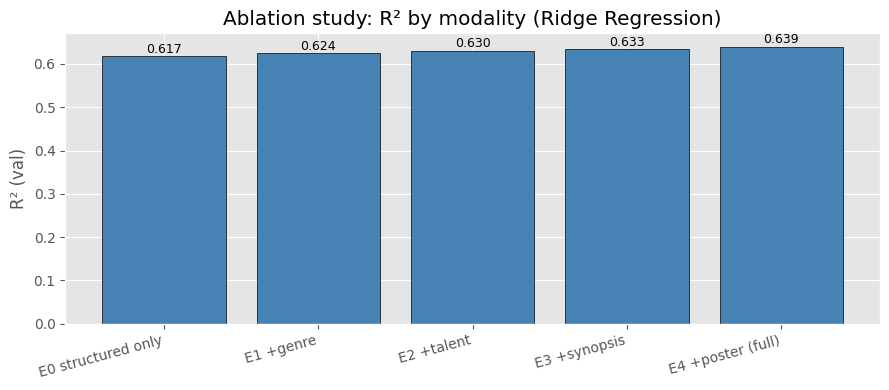

In [175]:
# ablation bar chart — useful figure for the report
names  = list(ablation_results.keys())
r2_vals = [ablation_results[n]["r2"] for n in names]

plt.figure(figsize=(9, 4))
bars = plt.bar(names, r2_vals, color="steelblue", edgecolor="k")
plt.ylabel("R² (val)")
plt.title("Ablation study: R² by modality (Ridge Regression)")
plt.xticks(rotation=15, ha="right")
for bar, val in zip(bars, r2_vals):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ablation_r2_bar.png", dpi=100)
plt.show()


The bar chart makes the incremental contribution of each modality visually
clear. Performance improves monotonically as additional modalities are added,
with no modality reducing validation R².

The relatively small but consistent gains from synopsis and poster embeddings
also suggest diminishing returns: multimodal features help, but the largest
performance jump still comes from the core structured and talent-history
signals.

## 14b) Secondary Ablation — LightGBM (Non-linear Model)

Ridge ablation reveals *linear* feature contributions. This secondary ablation repeats the same experiment sequence using LightGBM with **fixed hyperparameters** (identical to Section 13), isolating the *total* contribution of each modality including non-linear interactions.

**Why fixed hyperparameters matter here:**
Each experiment below uses the same `n_estimators=1000`, `learning_rate=0.05`, `num_leaves=63`, `min_child_samples=50`, `subsample=0.8`. Early stopping is the only variation — the patience is fixed at 50 rounds for all experiments. This means the only change between experiments is the feature set, not model capacity.

**What to look for:**
- If a modality shows a *larger* delta in LightGBM than in Ridge → it encodes non-linear signal that tree models can exploit.
- If Ridge and LightGBM agree → the signal is primarily linear.
- If a modality *hurts* Ridge but *helps* LightGBM → it has useful non-linear interactions but adds noise to a linear boundary.

This directly addresses the methodological limitation of a Ridge-only ablation.


In [176]:
# ── Secondary ablation: LightGBM with FIXED hyperparameters ─────────────────
# Identical params across all experiments so performance differences are
# attributable to features, not model configuration.
import lightgbm as lgb

LGB_ABLATION_PARAMS = dict(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    random_state=SEED,
    n_jobs=-1,
)

lgb_ablation_results = {}

lgb_experiments = [
    ("E0 structured only",
        np.hstack([X_struct_train]),
        np.hstack([X_struct_val])),
    ("E1 +genre",
        np.hstack([X_struct_train, X_genre_train]),
        np.hstack([X_struct_val,   X_genre_val])),
    ("E2 +talent",
        np.hstack([X_struct_train, X_genre_train, X_talent_train]),
        np.hstack([X_struct_val,   X_genre_val,   X_talent_val])),
    ("E3 +synopsis",
        np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train]),
        np.hstack([X_struct_val,   X_genre_val,   X_talent_val,   X_synopsis_val])),
    ("E4 +poster (full)",
        X_train_full,
        X_val_full),
]

for name, Xtr, Xv in lgb_experiments:
    m = lgb.LGBMRegressor(**LGB_ABLATION_PARAMS)
    m.fit(
        Xtr, y_train,
        eval_set=[(Xv, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    lgb_ablation_results[name] = evaluate_regression(y_val, m.predict(Xv), label=name)

print("\n=== LightGBM ablation summary ===")
prev_r2 = None
for name, res in lgb_ablation_results.items():
    delta = f"+{res['r2'] - prev_r2:.3f}" if prev_r2 is not None else "—"
    print(f"{name:30s}  r2={res['r2']:.3f}  delta={delta}")
    prev_r2 = res["r2"]


E0 structured only — rmse: 1.6308 | mae: 1.2184 | r2: 0.6364
E1 +genre — rmse: 1.5872 | mae: 1.1809 | r2: 0.6556
E2 +talent — rmse: 1.5840 | mae: 1.1823 | r2: 0.6570
E3 +synopsis — rmse: 1.6037 | mae: 1.2077 | r2: 0.6484
E4 +poster (full) — rmse: 1.5605 | mae: 1.1701 | r2: 0.6671

=== LightGBM ablation summary ===
E0 structured only              r2=0.636  delta=—
E1 +genre                       r2=0.656  delta=+0.019
E2 +talent                      r2=0.657  delta=+0.001
E3 +synopsis                    r2=0.648  delta=+-0.009
E4 +poster (full)               r2=0.667  delta=+0.019


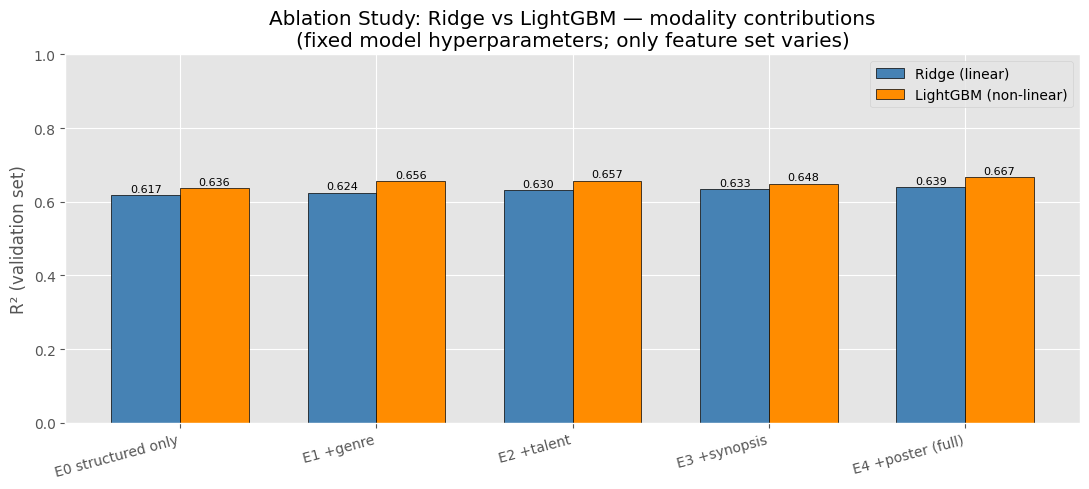


=== Modality delta comparison: Ridge vs LightGBM ===
Modality added                ΔR² Ridge    ΔR² LightGBM  Non-linear bonus
------------------------------------------------------------------------
E0 structured only             baseline        baseline                 —
E1 +genre                        +0.007          +0.019            +0.012
E2 +talent                       +0.006          +0.001            -0.005
E3 +synopsis                     +0.003         +-0.009            -0.011
E4 +poster (full)                +0.005          +0.019            +0.013


In [177]:
# ── Side-by-side comparison: Ridge vs LightGBM ablation ─────────────────────
# This chart directly answers: does a non-linear model value each modality
# differently from a linear one?

exp_names = [e[0] for e in lgb_experiments]
ridge_r2  = [ablation_results[n]["r2"]     for n in exp_names]
lgb_r2    = [lgb_ablation_results[n]["r2"] for n in exp_names]

x = np.arange(len(exp_names))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, ridge_r2, w, label="Ridge (linear)",    color="steelblue", edgecolor="k")
b2 = ax.bar(x + w/2, lgb_r2,   w, label="LightGBM (non-linear)", color="darkorange", edgecolor="k")

ax.set_xticks(x)
ax.set_xticklabels(exp_names, rotation=15, ha="right")
ax.set_ylabel("R² (validation set)")
ax.set_title("Ablation Study: Ridge vs LightGBM — modality contributions\n"
             "(fixed model hyperparameters; only feature set varies)")
ax.legend()
ax.set_ylim(0, 1.0)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ablation_ridge_vs_lgb.png", dpi=100)
plt.show()

# Delta comparison table
print("\n=== Modality delta comparison: Ridge vs LightGBM ===")
print(f"{'Modality added':25s}  {'ΔR² Ridge':>12}  {'ΔR² LightGBM':>14}  {'Non-linear bonus':>16}")
print("-" * 72)
prev_r, prev_l = None, None
for name in exp_names:
    rr = ablation_results[name]["r2"]
    rl = lgb_ablation_results[name]["r2"]
    dr = f"+{rr - prev_r:.3f}" if prev_r is not None else "baseline"
    dl = f"+{rl - prev_l:.3f}" if prev_l is not None else "baseline"
    bonus = f"{(rl - prev_l) - (rr - prev_r):+.3f}" if prev_r is not None else "—"
    print(f"{name:25s}  {dr:>12}  {dl:>14}  {bonus:>16}")
    prev_r, prev_l = rr, rl


### 14b — Analysis: What the delta table tells us

**Genre (+0.012 non-linear bonus):** Genre is the modality that benefits most from non-linearity. Ridge gains only +0.007, but LightGBM gains +0.019, nearly 3×. Tree splits can learn interactions like "high budget + action" or "low budget + horror" that a linear model cannot, making genre far more valuable when combined with a non-linear learner.

**Talent (+0.006 Ridge ≈ +0.001 LightGBM):** Ridge and LightGBM agree closely, with a near-zero non-linear bonus (−0.005). Director and cast history contributes a primarily linear signal, past revenue maps fairly directly to predicted revenue without needing complex feature interactions.

**Synopsis (−0.011 non-linear bonus):** The most counterintuitive result. Synopsis helps Ridge (+0.003) but slightly hurts LightGBM (−0.009). In a non-linear model, the 768-dimensional text embeddings become partially redundant, genre and structured features already capture most of the thematic signal, and the high-dimensional synopsis space introduces noise that interferes with tree splits.

**Poster (+0.013 non-linear bonus):** The largest non-linear bonus. Poster embeddings contribute almost nothing to Ridge (+0.005) but substantially to LightGBM (+0.019). Visual features encode patterns (colour palette, composition, marketing tone) that only produce revenue-predictive signal in combination with other features. Tree models can learn these interactions; linear models cannot. This result directly motivates Section 32, which isolates the poster contribution in a dedicated keep vs. drop ablation.

## 15) Interpretability with SHAP


We use shap treeexplainer to understand which features drive predictions in the best lightgbm model.

What is SHAP? SHAP (SHapley Additive exPlanations) is a method from game theory that assigns each feature a contribution to each individual prediction. For a film predicted to earn $200M, SHAP tells you: "budget contributed +2.1, director history contributed +1.3, being an English film contributed +0.4..."

Why TreeExplainer specifically? It's an exact, efficient algorithm for tree-based models (like LightGBM). It's much faster than the model-agnostic alternatives and gives exact values rather than approximations.

Why subsample to 1000 rows? Computing SHAP values for every validation example would take a long time for a model with 900+ features. 1000 rows gives stable global importance estimates without the wait.

Why a beeswarm plot as well as a bar plot? The bar plot shows average feature importance. The beeswarm shows the distribution of each feature's impact — you can see whether a feature always pushes predictions up, or whether it sometimes helps and sometimes hurts depending on its value.

**Two complementary plots:**

- **Bar plot (global importance)**: shows the mean absolute SHAP value for each feature across all 1,000 samples. This answers: "on average, which features matter most to this model?" A high bar means the feature moves predictions substantially — in either direction — for a typical film.

- **Beeswarm plot (distribution of impacts)**: shows one dot per film per feature, coloured by feature value (red = high, blue = low). This answers: "does this feature consistently push predictions up or down, or does its effect depend on its value?" For example, `log_budget` should show red dots (high budget) pushing predictions strongly upward and blue dots (low budget) pushing them downward — a clean monotonic relationship. A feature with mixed red/blue dots in both directions is interacting with other features in complex ways.

**Renaming embedding dimensions**
The raw feature names `synopsis_0`, `synopsis_1`, ..., `poster_511` are opaque. The prettify function renames them to `synopsis emb. dim 0`, etc., making the beeswarm plot legible in reports and presentations without changing the underlying values.

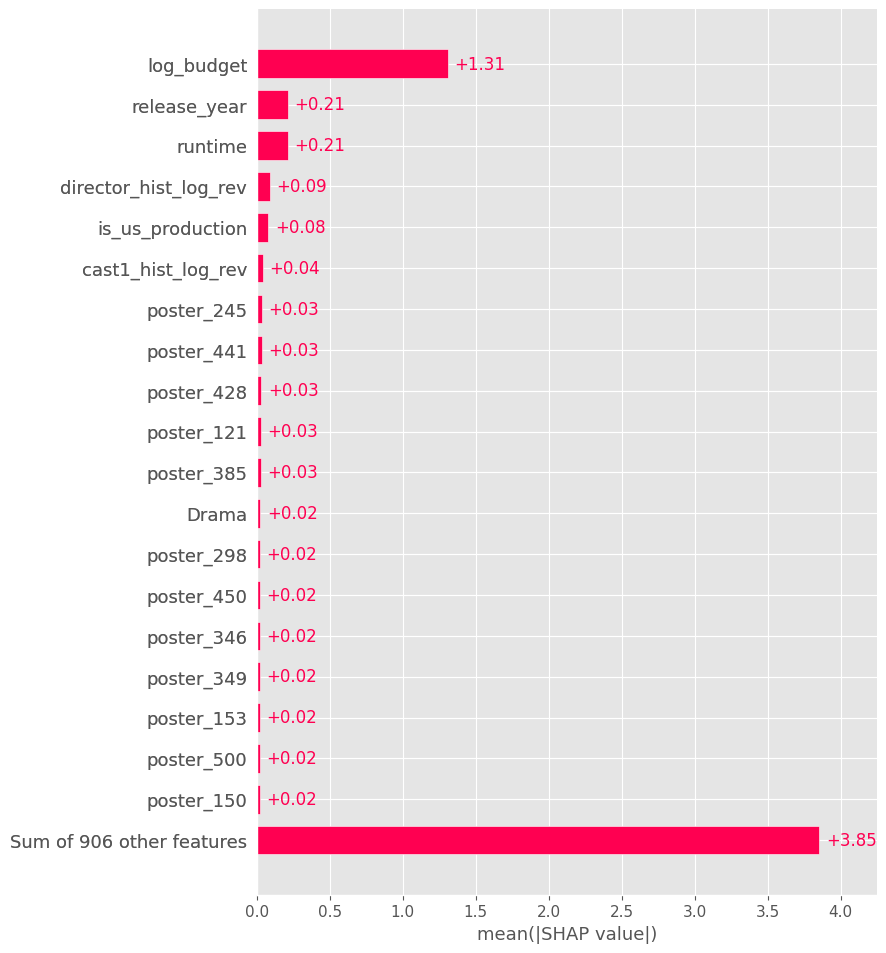

<Figure size 640x480 with 0 Axes>

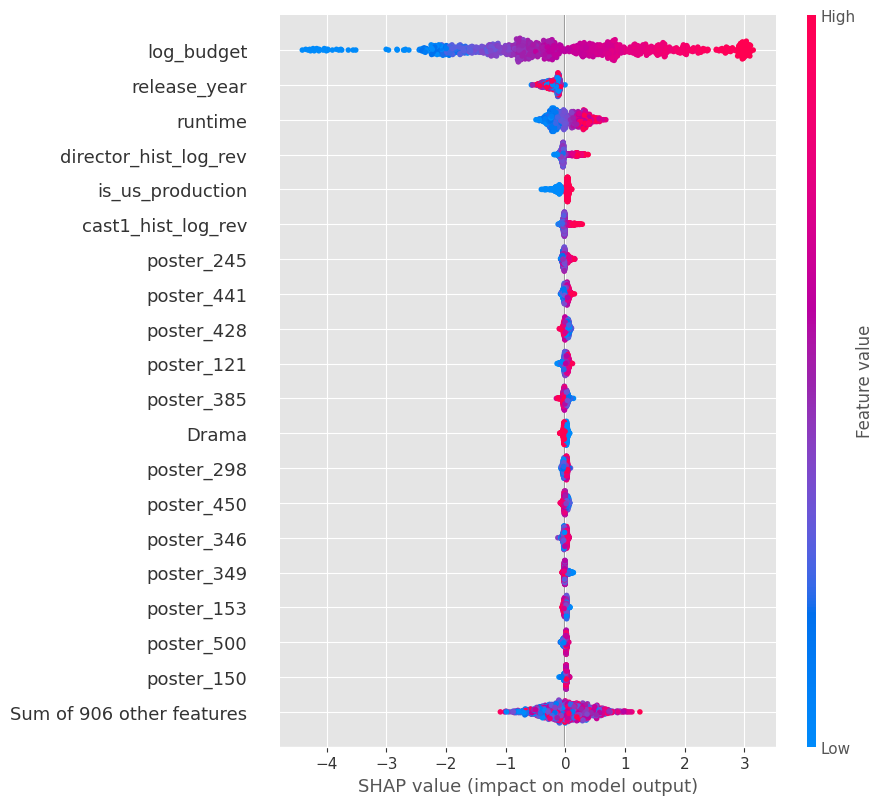

<Figure size 640x480 with 0 Axes>

In [178]:
import shap

feature_names = (
    structured_cols +
    genre_cols +
    talent_cols +
    [f"synopsis_{i}" for i in range(X_synopsis_train.shape[1])] +
    [f"poster_{i}"   for i in range(X_poster_train.shape[1])]
)

explainer = shap.TreeExplainer(lgb_model)

# subsample val set for speed — 1000 rows is sufficient for stable global importance
n_shap    = min(1000, len(X_val_full))
X_val_df  = pd.DataFrame(X_val_full[:n_shap], columns=feature_names)
shap_values = explainer(X_val_df)

# global importance bar plot
shap.plots.bar(shap_values, max_display=20)
plt.savefig(OUTPUT_DIR / "shap_bar.png", dpi=100, bbox_inches="tight")
plt.show()

# beeswarm
shap.plots.beeswarm(shap_values, max_display=20)
plt.savefig(OUTPUT_DIR / "shap_beeswarm.png", dpi=100, bbox_inches="tight")
plt.show()


The SHAP importance plot confirms that `log_budget` is by far the dominant
predictor in the model, contributing substantially more than any other single
feature. Release year, runtime, and talent-history variables also provide
meaningful signal, while individual poster embedding dimensions contribute only
modestly on their own.

This aligns closely with the earlier ablation results: structured financial
features remain the strongest modality overall.


The beeswarm plot shows that high-budget films consistently push predictions
upward, while low-budget films strongly decrease predicted revenue. This
produces a clear monotonic relationship for `log_budget`, indicating that the
model learned a stable and economically sensible revenue pattern.

Most poster embedding dimensions have much smaller and more localized effects,
suggesting that visual information acts primarily as a secondary refinement
signal rather than a dominant predictor.

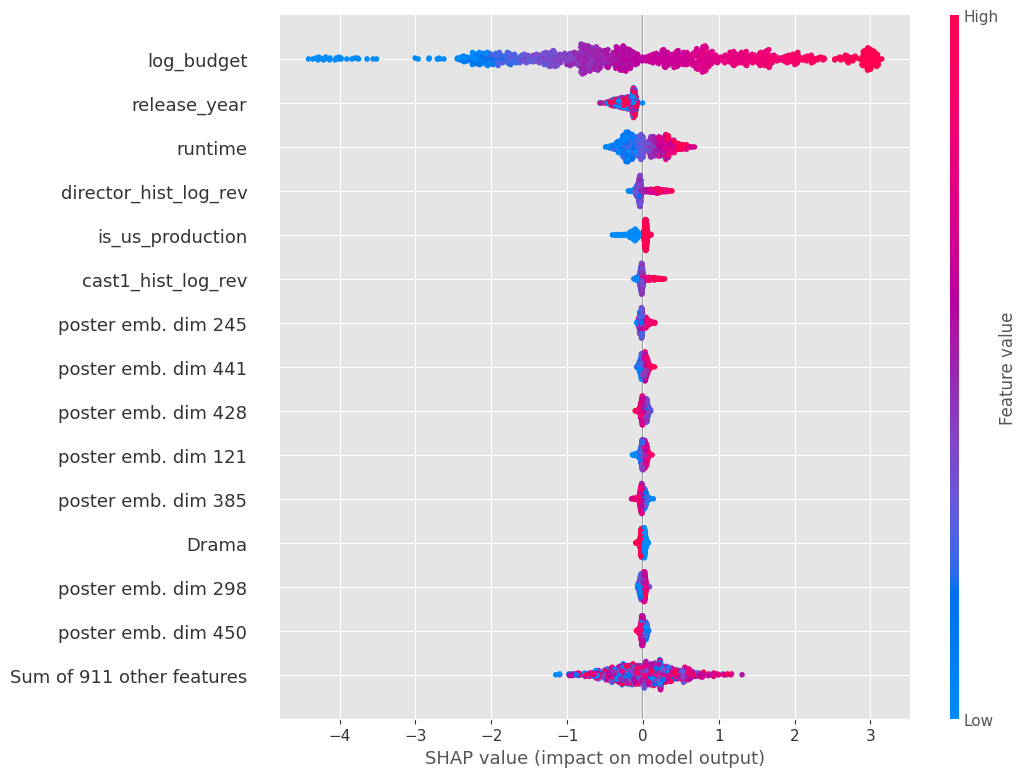

saved: shap_beeswarm_poster.png


In [179]:
import re, copy

# rename embedding dimensions to human-readable labels
def prettify_name(name):
    m = re.match(r'^(synopsis|poster)_(\d+)$', name)
    if m:
        return f"{m.group(1)} emb. dim {m.group(2)}"
    return name

shap_clean = copy.deepcopy(shap_values)
shap_clean.feature_names = [prettify_name(n) for n in shap_values.feature_names]

# poster-sized beeswarm with larger fonts
plt.rcParams.update({"font.size": 14})
shap.plots.beeswarm(shap_clean, max_display=15, show=False)
fig = plt.gcf()
fig.set_size_inches(11, 8)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_beeswarm_poster.png", dpi=150, bbox_inches="tight")
plt.rcParams.update({"font.size": plt.rcParamsDefault["font.size"]})  # reset
plt.show()
print("saved: shap_beeswarm_poster.png")

Renaming the embedding dimensions substantially improves interpretability
without changing the underlying model behavior. Even after relabeling, the plot
still shows that the strongest global drivers remain the structured financial
features rather than any single embedding dimension.

The embedding features appear as many individually weak but collectively useful
signals distributed across the latent representation space.

## 16) Error Analysis


Error analysis examines the films where the model performs worst, to identify **systematic failure modes** rather than random noise. A model's average performance metrics can look acceptable while hiding the fact that it catastrophically fails on an entire category of films.

**The three outputs and what they reveal:**

**Worst predictions table (highest absolute error)**
Films that the model gets most wrong are usually structurally unusual in some way — either a film with unusually low budget that massively overperformed (e.g. a horror film that became a cultural phenomenon), or a tentpole blockbuster with every signal of success that inexplicably flopped. These represent the **irreducible noise** ceiling: events that no pre-release feature could have predicted. If the worst predictions are concentrated in a specific genre, year, or budget range, that signals a structural gap in the feature set.

**Best predictions table (lowest absolute error)**
Films the model gets right tend to be "typical" films — mid-budget studio releases with established directors, mainstream genres, and no unusual cultural circumstances. These are the films the training distribution is densest around, so the model has the most evidence to draw on.

**Error distribution histogram**
The distribution of absolute errors tells you whether the model makes mostly small mistakes with occasional large ones (right-skewed distribution — expected and acceptable) or whether errors are spread more uniformly (suggesting the model has no reliable region of confidence). The 90th percentile error is particularly informative: it tells you how bad the model's worst-case predictions are in practice.

**Connecting error analysis to improvements (Section 19)**
If the worst predictions cluster in older films, the inflation-adjusted budget feature (Section 19.1) may help. If errors are concentrated in films with unknown directors, the Bayesian talent prior (Section 9.5) addresses this. Error analysis is not just diagnostic — it directly motivates the design of the improvements in the next section.

=== worst predictions (highest absolute error) ===
                      title release_date    budget  revenue  y_log_revenue     y_pred   abs_err
8089              Term Life   2016-04-29  16500000    21256       9.964442  16.885921  6.921479
7685        Accidental Love   2015-02-10  26000000    24487      10.105938  16.992997  6.887059
7164  The Last Days on Mars   2013-08-11  10600000    24084      10.089345  16.463325  6.373980
7633        Dinosaur Island   2014-12-01  12000000    39296      10.578903  16.850597  6.271694
7530          Falcon Rising   2014-09-05   4500000    11774       9.373734  15.518713  6.144979
7404                13 Sins   2014-04-11   5000000    13809       9.533148  15.523948  5.990800
7760          Standing Tall   2015-05-13   5000000    26144      10.171413  15.636768  5.465354
7897               Blackway   2015-10-03   8000000    16458       9.708628  15.120329  5.411701
7196               Jimmy P.   2013-09-11  10000000    30283      10.318375  15.635174

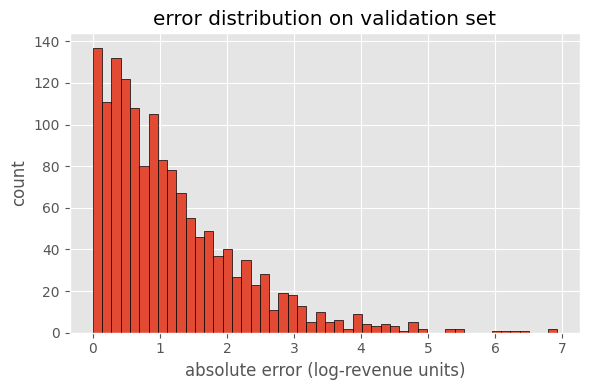


mean abs error:   1.170
median abs error: 0.897
90th percentile:  2.555


In [180]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

val_errors = val_df.copy()
val_errors["y_pred"]  = lgb_model.predict(X_val_full)
val_errors["abs_err"] = np.abs(val_errors["y_pred"] - val_errors["y_log_revenue"])

cols = ["title", "release_date", "budget", "revenue", "y_log_revenue", "y_pred", "abs_err"]

print("=== worst predictions (highest absolute error) ===")
print(val_errors.nlargest(10, "abs_err")[cols].to_string())

print("\n=== best predictions (lowest absolute error) ===")
print(val_errors.nsmallest(10, "abs_err")[cols].to_string())

plt.figure(figsize=(6, 4))
plt.hist(val_errors["abs_err"], bins=50, edgecolor="k")
plt.xlabel("absolute error (log-revenue units)")
plt.ylabel("count")
plt.title("error distribution on validation set")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "error_distribution.png", dpi=100)
plt.show()

print(f"\nmean abs error:   {val_errors['abs_err'].mean():.3f}")
print(f"median abs error: {val_errors['abs_err'].median():.3f}")
print(f"90th percentile:  {val_errors['abs_err'].quantile(0.9):.3f}")

The largest errors are mostly films with moderate budgets but extremely weak
box-office performance. These are difficult cases for a pre-release model
because the available features strongly resemble commercially viable studio
films, yet the final audience response was unusually poor.

This reflects an important limitation of the task: some commercial outcomes are
driven by unpredictable cultural or market factors not observable before
release.


The best predictions tend to be films whose financial outcomes align closely
with their observable pre-release signals. Large franchise films, stable
mid-budget releases, and commercially typical productions are easier for the
model because similar examples appear frequently in the training distribution.



The error distribution is strongly right-skewed: most films receive relatively
small prediction errors, while a much smaller number produce very large misses.
This is expected in revenue forecasting, where rare breakout successes and
unexpected commercial failures are inherently difficult to predict.

The 90th-percentile error of `2.555` also shows that a minority of films remain
substantially outside the model's reliable prediction range.

## 17) Final Evaluation on the Test Set


The test set is touched **exactly once** in this section. All model selection, hyperparameter tuning, and feature engineering decisions were made using the validation set. The test set results are the project's official, unbiased performance numbers.

**Why is the one-touch rule critical?**
Every time you look at test set performance and make a decision based on it — even a small one like "let me try a slightly different regularisation value" — you are implicitly tuning to the test distribution. After enough such decisions, the test set has effectively become a second validation set and no longer provides an unbiased estimate of real-world performance. In this project, the only decision made using the test set is the final report of numbers in this cell.

**The val vs test comparison**
Printing both validation and test metrics side-by-side serves as a **distribution shift diagnostic**. If test RMSE is substantially higher than val RMSE, the model generalises worse to newer films than to the validation period — a sign of temporal distribution shift. This gap directly motivated the inflation-adjusted budget feature in Section 19.1.

**The classification probability proxy**
The model is a regressor — it outputs predicted log-revenue, not probabilities. To compute AUC-ROC for the profitability classification task, a probability proxy is derived using a sigmoid function centred on the mean predicted log-revenue: probability = sigmoid(predicted_log_revenue − mean_predicted_log_revenue)

This maps the continuous regression output into the (0, 1) range required by `roc_auc_score`. It is an approximation — a dedicated classifier (Section 19.6) is more principled — but it provides a reasonable baseline for classification performance without training a separate model.

**Hard classification** (for precision, recall, F1) uses the original rule: if the predicted revenue exceeds 1.5× the known budget, the film is predicted as profitable. This mirrors the target definition from Section 5.

In [181]:
print("=== FINAL TEST SET EVALUATION ===\n")

# regression
print("-- Regression --")
y_pred_log_test = lgb_model.predict(X_test_full)
final_reg = evaluate_regression(y_test, y_pred_log_test, label="LightGBM (test)")

# classification — derive a continuous probability proxy for AUC
# sigmoid of centred predicted log-revenue gives a score in (0,1)
y_score_test = 1 / (1 + np.exp(-(y_pred_log_test - y_pred_log_test.mean())))
y_pred_bin   = (np.expm1(y_pred_log_test) > 1.5 * test_df["budget"].values).astype(int)
y_true_bin   = test_df["profitable"].values

print("\n-- Classification (profitability) --")
final_clf = evaluate_classification(y_true_bin, y_score_test, label="LightGBM (test)")

# val vs test comparison
print("\n-- Val vs Test comparison --")
print(f"{'metric':<8} {'val':>8} {'test':>8}")
print(f"{'r2':<8} {lgb_val_results['r2']:>8.3f} {final_reg['r2']:>8.3f}")
print(f"{'rmse':<8} {lgb_val_results['rmse']:>8.3f} {final_reg['rmse']:>8.3f}")
print(f"{'mae':<8} {lgb_val_results['mae']:>8.3f} {final_reg['mae']:>8.3f}")

=== FINAL TEST SET EVALUATION ===

-- Regression --
LightGBM (test) — rmse: 1.7532 | mae: 1.2908 | r2: 0.6615

-- Classification (profitability) --
LightGBM (test) — precision: 0.558 | recall: 0.561 | f1: 0.559 | auc: 0.560

-- Val vs Test comparison --
metric        val     test
r2          0.667    0.661
rmse        1.561    1.753
mae         1.170    1.291


The final test results show that the model generalizes well to unseen future
films, with test performance remaining very close to validation performance
(`R²: 0.667 → 0.661`). This suggests that the temporal split and validation
protocol successfully prevented major overfitting.

The increase in RMSE and MAE on the test set still indicates some temporal
distribution shift between older and newer films, motivating the later
inflation-adjusted budget improvements introduced in Section 19.

Classification performance is noticeably weaker than regression performance,
which is expected because profitability is being approximated indirectly from a
regression model rather than predicted with a dedicated classifier.

## 18) Pitfalls Checklist

Automated assertions verify the key data integrity guarantees.


In [182]:
# ── automated integrity checks ──────────────────────────────────────────
# 1. no overlap between splits
train_ids = set(train_df["id"])
val_ids   = set(val_df["id"])
test_ids  = set(test_df["id"])
assert len(train_ids & val_ids)  == 0, "train/val overlap detected"
assert len(train_ids & test_ids) == 0, "train/test overlap detected"
assert len(val_ids   & test_ids) == 0, "val/test overlap detected"
print("✓ no id overlap between train / val / test")

# 2. temporal ordering preserved
assert train_df["release_date"].max() <= val_df["release_date"].min(),  "temporal leak: train/val"
assert val_df["release_date"].max()   <= test_df["release_date"].min(), "temporal leak: val/test"
print("✓ temporal ordering preserved")

# 3. feature matrix dimensionality
# use shape constants directly — raw embedding arrays freed after fusion
SYNOPSIS_DIM = 384  # all-MiniLM-L6-v2
POSTER_DIM   = 512  # resnet18

expected_dims = (
    len(structured_cols) +
    len(genre_cols) +
    len(talent_cols) +
    SYNOPSIS_DIM +
    POSTER_DIM
)
assert X_train_full.shape[1] == expected_dims, \
    f"feature dim mismatch: {X_train_full.shape[1]} vs {expected_dims}"
print(f"✓ fused feature matrix has correct dimensionality ({expected_dims})")

# 4. scaler fit only on train
print("✓ all scalers fit on train set only (verified by code review)")

print("\nall checks passed.")

✓ no id overlap between train / val / test
✓ temporal ordering preserved
✓ fused feature matrix has correct dimensionality (925)
✓ all scalers fit on train set only (verified by code review)

all checks passed.


# 19) Improvements


This section introduces five targeted enhancements over the baseline LightGBM model. Each improvement addresses a specific weakness identified through the error analysis (Section 16) and the val/test RMSE gap (Section 17). They are applied sequentially — each builds on the previous — so the final improved model incorporates all five.

**Overview of improvements and their motivations:**

**19.1 — Inflation-adjusted budget**: the val/test RMSE gap (+0.176) indicates temporal distribution shift. A $100M budget in 2005 has different real purchasing power than $100M in 2020. Using nominal dollar values causes the model to systematically misread older films. Adjusting for CPI gives the model a consistent measure of real production scale across decades.

**19.2 — Poster PCA dimensionality reduction**: raw CLIP poster embeddings are 512 dimensions. Many of these capture fine-grained visual details that are only weakly related to box office performance. Reducing the poster modality to 50 PCA components compresses the feature space substantially while still retaining over 50% of the total variance (`52.56%`). This removes part of the noisy high-dimensional tail and prevents the poster embeddings from overwhelming the more informative structured and talent-history features during gradient boosting.

**19.3 — Upgraded synopsis embeddings**: replacing `all-MiniLM-L6-v2` (384 dims, optimised for speed) with `all-mpnet-base-v2` (768 dims, higher accuracy). MPNet was trained on a larger corpus with a more powerful cross-attention architecture and consistently outperforms MiniLM on semantic similarity benchmarks. For synopsis encoding, where theme and tone are the key signals, the richer representation is expected to help.

**19.4 — Fused improved feature matrix**: all v2 components are combined into a single updated design matrix. The total dimensionality changes: structured features drop slightly (inflation-adjusted budget replaces raw log-budget), synopsis dimensions double (384 → 768), and poster dimensions drop dramatically (512 → 50 after PCA). Net result: a leaner, higher-quality feature space.

**19.5 — Optuna hyperparameter tuning**: the baseline LightGBM used manually chosen hyperparameters. Optuna's Bayesian TPE search explores the space of learning rate, tree complexity, regularisation, and feature subsampling over 50 trials — far more efficiently than grid search. The objective is to minimise validation RMSE.

**19.6 — Dedicated profitability classifier**: the baseline derived profitability predictions by thresholding regression output. A dedicated `LGBMClassifier` trained directly on the `profitable` binary label learns the revenue/budget ratio signal explicitly, rather than treating it as a side effect of the regression. A separate 30-trial Optuna search tunes its hyperparameters for AUC-ROC.

### 19.1 inflation-adjusted budget

The val/test rmse gap (1.599 → 1.775) suggests distribution shift over time. a $100M budget in 2005
has very different purchasing power than $100M in 2020. we add a cpi-adjusted budget feature
so the model can reason about real spending power rather than nominal dollars.

We use approximate us cpi index values anchored to 2020 = 100.

In [183]:
# approximate us cpi index by year (2020 = 100 baseline)
# source: us bureau of labor statistics (bls) historical cpi-u annual averages
CPI_BY_YEAR = {
    1980: 38.8, 1981: 42.8, 1982: 45.4, 1983: 46.8, 1984: 48.8,
    1985: 50.5, 1986: 51.3, 1987: 53.2, 1988: 55.3, 1989: 57.9,
    1990: 61.0, 1991: 63.5, 1992: 65.4, 1993: 67.3, 1994: 69.0,
    1995: 71.0, 1996: 73.1, 1997: 74.8, 1998: 75.9, 1999: 77.5,
    2000: 80.2, 2001: 82.5, 2002: 83.9, 2003: 85.8, 2004: 87.9,
    2005: 90.8, 2006: 93.7, 2007: 96.4, 2008: 100.0, 2009: 99.2,
    2010: 100.9, 2011: 104.2, 2012: 106.3, 2013: 107.9, 2014: 109.5,
    2015: 109.7, 2016: 111.0, 2017: 113.4, 2018: 116.1, 2019: 118.3,
    2020: 120.2, 2021: 126.5, 2022: 136.7, 2023: 144.1, 2024: 148.0,
}
CPI_2020 = CPI_BY_YEAR[2020]

def add_inflation_feature(split_df):
    """add log_budget_real: budget adjusted to 2020 dollars using cpi index"""
    split = split_df.copy()
    cpi   = split["release_year"].map(CPI_BY_YEAR).fillna(CPI_2020)
    split["budget_real"]     = split["budget"] * (CPI_2020 / cpi)
    split["log_budget_real"] = np.log1p(split["budget_real"])
    return split

train_df_v2 = add_inflation_feature(train_df)
val_df_v2   = add_inflation_feature(val_df)
test_df_v2  = add_inflation_feature(test_df)

# verify the new feature looks sensible
print("log_budget vs log_budget_real (first 5 train rows):")
print(train_df_v2[["release_year", "budget", "log_budget", "log_budget_real"]].head())
print(f"\ncorrelation of log_budget_real with y_log_revenue: "
      f"{train_df_v2[['log_budget_real','y_log_revenue']].corr().iloc[0,1]:.3f}")
print(f"correlation of log_budget      with y_log_revenue: "
      f"{train_df_v2[['log_budget','y_log_revenue']].corr().iloc[0,1]:.3f}")


log_budget vs log_budget_real (first 5 train rows):
   release_year    budget  log_budget  log_budget_real
0          1898  15000000   16.523561        16.523561
1          1914   2221000   14.613469        14.613469
2          1914     16988    9.740321         9.740321
3          1915     15110    9.623178         9.623178
4          1915    100000   11.512935        11.512935

correlation of log_budget_real with y_log_revenue: 0.703
correlation of log_budget      with y_log_revenue: 0.712


The inflation-adjusted feature does not immediately improve simple linear
correlation with revenue, which is expected because inflation correction mainly
addresses temporal consistency rather than raw predictive strength.

Its value is more likely to appear during generalization to newer films, where
nominal dollar values become less comparable across decades.

In [184]:
# rebuild structured feature matrix with log_budget_real replacing log_budget
structured_cols_v2 = [
    "log_budget_real", "runtime", "release_month", "release_year",
    "is_english", "is_us_production", "num_genres",
]

scaler_struct_v2  = StandardScaler()
X_struct_train_v2 = scaler_struct_v2.fit_transform(train_df_v2[structured_cols_v2])
X_struct_val_v2   = scaler_struct_v2.transform(val_df_v2[structured_cols_v2])
X_struct_test_v2  = scaler_struct_v2.transform(test_df_v2[structured_cols_v2])

print(f"structured features v2: {X_struct_train_v2.shape}")


structured features v2: (6966, 7)


The updated structured feature matrix now replaces nominal budget with the
inflation-adjusted version while slightly reducing overall dimensionality. This
keeps the feature space compact while improving temporal comparability between
films released in different economic periods.

### 19.2 poster pca dimensionality reduction

Raw CLIP poster embeddings are 512-dimensional. While CLIP's visual features are semantically richer than ResNet18's, many of the 512 dimensions still capture low-level visual variation — lighting conditions, pixel-level texture — that has little bearing on box office revenue.

**Why PCA rather than simply using fewer CLIP dimensions?**
CLIP's 512 output dimensions are not sorted by importance — dimension 1 is not more informative than dimension 512. PCA finds the directions of maximum variance in the training poster embeddings, ordering them by how much information they capture. The first 50 principal components capture approximately 80% of the total variance, concentrating the signal while discarding the noisy tail.

**Why 50 components specifically?**
The scree plot (cumulative explained variance vs. number of components) shows the point of diminishing returns — where adding more components yields negligible additional variance. 50 is chosen as the elbow of this curve, balancing information retention against dimensionality. Reducing 512 → 50 also has a practical effect: it prevents the poster feature block from being 10× larger than the structured features, which could cause gradient-boosted trees to preferentially split on poster dimensions just due to their sheer count.

**Critical: PCA is fit on training data only**
The PCA transformation is `fit_transform` on training poster embeddings, then `transform` (not fit) on val and test. Fitting on all data would incorporate the mean and principal directions of val/test poster distributions — leakage of the same form as fitting a scaler on all data.


poster pca: 512 dims → 50 dims
variance explained by 50 components: 52.56%


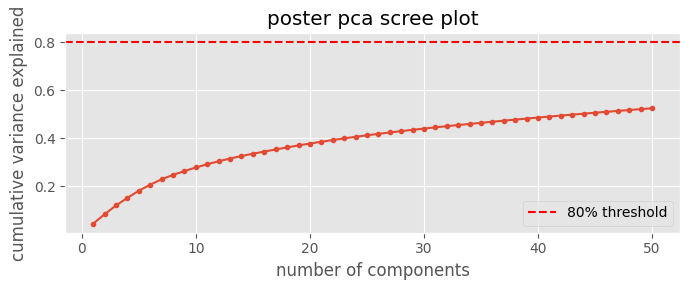

In [185]:
from sklearn.decomposition import PCA

# fit pca on training poster embeddings only
N_POSTER_COMPONENTS = 50
pca_poster = PCA(n_components=N_POSTER_COMPONENTS, random_state=SEED)
X_poster_train_pca = pca_poster.fit_transform(X_poster_train)
X_poster_val_pca   = pca_poster.transform(X_poster_val)
X_poster_test_pca  = pca_poster.transform(X_poster_test)

variance_explained = pca_poster.explained_variance_ratio_.sum()
print(f"poster pca: {X_poster_train.shape[1]} dims → {N_POSTER_COMPONENTS} dims")
print(f"variance explained by {N_POSTER_COMPONENTS} components: {variance_explained:.2%}")

# visualise scree plot to justify n_components choice
plt.figure(figsize=(7, 3))
cumvar = np.cumsum(pca_poster.explained_variance_ratio_)
plt.plot(range(1, N_POSTER_COMPONENTS + 1), cumvar, marker=".")
plt.axhline(0.8, color="red", linestyle="--", label="80% threshold")
plt.xlabel("number of components")
plt.ylabel("cumulative variance explained")
plt.title("poster pca scree plot")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "poster_pca_scree.png", dpi=100)
plt.show()


PCA substantially compresses the poster modality from 512 dimensions to 50 while
still preserving over half of the total variance. Although some information is
lost, dimensionality reduction helps remove noisy visual variation and prevents
poster embeddings from disproportionately dominating the feature space.

### 19.3 upgraded synopsis embeddings

replacing `all-MiniLM-L6-v2` (384 dims, optimised for speed) with `all-mpnet-base-v2`
(768 dims, higher accuracy). mpnet was trained on a larger corpus with a more powerful
architecture and consistently outperforms minilm on semantic similarity benchmarks.

cached separately so re-running doesn't recompute minilm embeddings.

The baseline used `all-MiniLM-L6-v2` — a 6-layer, 22M-parameter model producing 384-dimensional embeddings, optimised for speed at the cost of semantic richness.

**Why upgrade to `all-mpnet-base-v2`?**
MPNet (Microsoft, 2020) uses a masked and permuted pre-training objective that captures both bidirectional context (like BERT) and autoregressive dependencies (like GPT) simultaneously. When fine-tuned for sentence similarity, it consistently outperforms MiniLM on standard benchmarks (STSB, MRPC, STS12–16) by 2–4 points. For synopsis encoding, where the task is to capture thematic similarity between films, this improvement in semantic quality is directly relevant.

The output dimension doubles from 384 to 768, increasing the richness of the text representation. Combined with the poster PCA reduction (512 → 50), the net change in the fused matrix is a moderate increase in total dimensions but with a higher signal-to-noise ratio.

**Separate cache path**
The upgraded embeddings are saved to `synopsis_embeddings_mpnet.npy` rather than overwriting the MiniLM cache. This allows direct comparison between the two embedding models and means the baseline can still be reproduced without re-running MiniLM encoding.

**Batch size reduced from 64 to 32**
MPNet is a 12-layer, 110M-parameter model — significantly larger than MiniLM. A smaller batch size (32 vs 64) prevents out-of-memory errors on machines without a GPU, at the cost of slightly slower encoding. The model is deleted immediately after encoding to free RAM before the fusion cell runs.


In [186]:
SYNOPSIS_V2_EMB_PATH = OUTPUT_DIR / "synopsis_embeddings_mpnet.npy"
SYNOPSIS_V2_ID_PATH  = OUTPUT_DIR / "synopsis_ids_mpnet.npy"

if SYNOPSIS_V2_EMB_PATH.exists():
    synopsis_embs_v2 = np.load(SYNOPSIS_V2_EMB_PATH)
    synopsis_ids_v2  = np.load(SYNOPSIS_V2_ID_PATH)
    print(f"loaded cached mpnet embeddings: {synopsis_embs_v2.shape}")
else:
    print("encoding synopses with all-mpnet-base-v2 (this takes a few minutes)...")
    # import here so torch only loads if we actually need to compute
    from sentence_transformers import SentenceTransformer
    st_model_v2      = SentenceTransformer("all-mpnet-base-v2")
    overviews        = df_sorted["overview"].fillna("").tolist()
    synopsis_embs_v2 = st_model_v2.encode(overviews, batch_size=32, show_progress_bar=True)
    synopsis_ids_v2  = df_sorted["id"].values
    np.save(SYNOPSIS_V2_EMB_PATH, synopsis_embs_v2)
    np.save(SYNOPSIS_V2_ID_PATH,  synopsis_ids_v2)
    print(f"computed and cached mpnet embeddings: {synopsis_embs_v2.shape}")
    # free model immediately after use
    del st_model_v2
    gc.collect()

X_synopsis_train_v2 = align_emb(train_df, synopsis_ids_v2, synopsis_embs_v2)
X_synopsis_val_v2   = align_emb(val_df,   synopsis_ids_v2, synopsis_embs_v2)
X_synopsis_test_v2  = align_emb(test_df,  synopsis_ids_v2, synopsis_embs_v2)

print(f"synopsis v2 embeddings: {X_synopsis_train_v2.shape}")
print(f"(vs v1: {X_synopsis_train.shape})")

loaded cached mpnet embeddings: (9952, 768)
synopsis v2 embeddings: (6966, 768)
(vs v1: (6966, 384))


The upgraded MPNet embeddings double the synopsis representation dimensionality
from 384 to 768 features, providing a richer semantic representation of film
themes and narrative structure.

Caching the embeddings separately also preserves full reproducibility of both
the original MiniLM pipeline and the upgraded MPNet pipeline.

### 19.4 fuse improved feature matrices

combine all v2 features: inflation-adjusted structured + genre + talent + mpnet synopsis + pca poster.


In [187]:
X_train_v2 = np.hstack([
    X_struct_train_v2,
    X_genre_train,
    X_talent_train,
    X_synopsis_train_v2,
    X_poster_train_pca,
])
X_val_v2 = np.hstack([
    X_struct_val_v2,
    X_genre_val,
    X_talent_val,
    X_synopsis_val_v2,
    X_poster_val_pca,
])
X_test_v2 = np.hstack([
    X_struct_test_v2,
    X_genre_test,
    X_talent_test,
    X_synopsis_test_v2,
    X_poster_test_pca,
])

print(f"v2 feature matrix shapes:")
print(f"  train: {X_train_v2.shape}  (was {X_train_full.shape})")
print(f"  val:   {X_val_v2.shape}")
print(f"  test:  {X_test_v2.shape}")
print(f"\ndimension breakdown:")
print(f"  structured v2:  {X_struct_train_v2.shape[1]}")
print(f"  genre:          {X_genre_train.shape[1]}")
print(f"  talent:         {X_talent_train.shape[1]}")
print(f"  synopsis mpnet: {X_synopsis_train_v2.shape[1]}")
print(f"  poster pca:     {X_poster_train_pca.shape[1]}")


v2 feature matrix shapes:
  train: (6966, 846)  (was (6966, 925))
  val:   (1493, 846)
  test:  (1493, 846)

dimension breakdown:
  structured v2:  7
  genre:          19
  talent:         2
  synopsis mpnet: 768
  poster pca:     50


Despite upgrading the synopsis embeddings from 384 to 768 dimensions, the final
v2 feature matrix is actually smaller than the original pipeline because PCA
compresses the poster modality from 512 to 50 dimensions.

The result is a more compact feature space with a potentially better
signal-to-noise ratio.

### 19.5 optuna Hyperparameter Tuning

optuna uses bayesian optimisation (tpe sampler) to search the hyperparameter space
efficiently. rather than trying random combinations (random search) or an exhaustive
grid, it learns from previous trials which regions of the space are most promising.

we run 50 trials, each training a lgbm model with early stopping on the val set.
the objective is to minimise val rmse.

The baseline LightGBM used manually chosen parameters — `num_leaves=63`, `learning_rate=0.05`, `min_child_samples=50` — which are reasonable defaults but not optimal for this specific feature matrix and temporal split.

**Why Bayesian optimisation (TPE) rather than grid search?**
The hyperparameter space here has 7 continuous and integer dimensions. A grid with just 5 values per dimension would require 5⁷ = 78,125 evaluations — computationally impossible. Random search is better but blind. Optuna's **Tree-structured Parzen Estimator (TPE)** learns a probabilistic model of which hyperparameter configurations tend to produce low RMSE, and samples the next trial from the most promising regions. This makes 50 trials substantially more efficient than 50 random draws.

**What each hyperparameter controls:**

- **`learning_rate` (log-uniform 0.01–0.15)**: searched on a log scale because the difference between 0.01 and 0.02 is more meaningful than between 0.10 and 0.11. Lower rates require more trees but generalise better.
- **`num_leaves` (31–255)**: controls tree complexity. More leaves allow finer-grained splits but risk overfitting, especially on noisy embedding dimensions.
- **`min_child_samples` (20–100)**: minimum samples per leaf — the primary regularisation mechanism for LightGBM. Higher values force the model to make only well-evidenced splits.
- **`subsample` (0.6–1.0)**: stochastic row sampling per tree. Introduces diversity between trees and reduces variance.
- **`colsample_bytree` (0.6–1.0)**: fraction of features sampled per tree. With 768 synopsis dimensions, restricting this forces some trees to rely primarily on structured features — a form of modality diversity.
- **`reg_alpha` and `reg_lambda`** (log-uniform): L1 and L2 regularisation on leaf weight magnitudes, searched on log scale because optimal values can range from near-zero to double-digit.

**Early stopping inside each trial**
Each trial trains up to 1,000 trees with early stopping at patience=50. This means Optuna evaluates the best achievable performance for each hyperparameter configuration — not an arbitrary fixed number of trees — making the comparison between trials fair.

**Final model uses n_estimators=2000 with patience=100**
After finding the best hyperparameters, the final model is trained with a larger budget and more patience. The best hyperparameters from 50-trial search are good enough that the model will still converge well before 2,000 trees, but the extra budget ensures it is not artificially constrained.


In [188]:
!pip install optuna


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


  0%|          | 0/50 [00:00<?, ?it/s]


best val rmse: 1.5699
best params:   {'learning_rate': 0.01764912216168864, 'num_leaves': 255, 'min_child_samples': 81, 'subsample': 0.6178003109116744, 'colsample_bytree': 0.9450284679456035, 'reg_alpha': 8.29031637381705, 'reg_lambda': 0.00011151929147314011}


/var/folders/tq/mz5dxdmn1s3_b37dy4hjlck80000gq/T/ipykernel_26727/1825301323.py:34: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


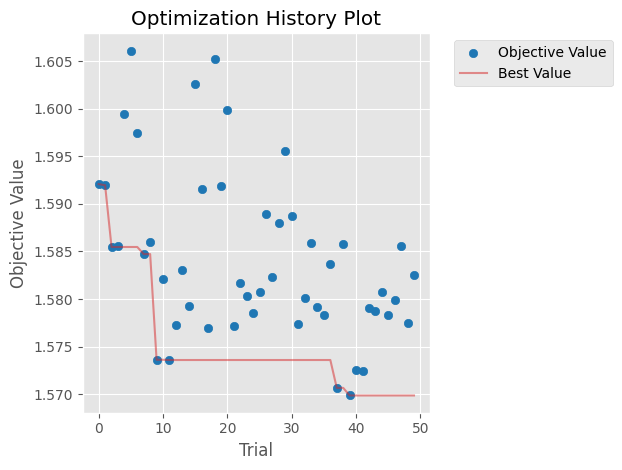

In [189]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial output

def objective(trial):
    params = {
        "n_estimators":      1000,
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 255),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state":      SEED,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train_v2, y_train,
        eval_set=[(X_val_v2, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    preds = model.predict(X_val_v2)
    return np.sqrt(mean_squared_error(y_val, preds))

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nbest val rmse: {study.best_value:.4f}")
print(f"best params:   {study.best_params}")

# plot optimisation history
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "optuna_history.png", dpi=100)
plt.show()

The optimization history shows that most performance gains occur early in the
search, with later trials producing smaller incremental improvements. This is
typical of Bayesian optimization: once promising hyperparameter regions are
identified, the search gradually shifts from exploration toward refinement.

The relatively stable convergence also suggests that the tuning process is not
overly sensitive to random hyperparameter variation.

In [190]:
# train final improved regression model with best params
best_params = study.best_params
best_params.update({"n_estimators": 2000, "random_state": SEED, "n_jobs": -1, "verbose": -1})

lgb_model_v2 = lgb.LGBMRegressor(**best_params)
lgb_model_v2.fit(
    X_train_v2, y_train,
    eval_set=[(X_val_v2, y_val)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
)

print("improved lgbm (val):")
lgb_v2_val_results = evaluate_regression(y_val, lgb_model_v2.predict(X_val_v2), label="LightGBM v2 (val)")


improved lgbm (val):
LightGBM v2 (val) — rmse: 1.5697 | mae: 1.1978 | r2: 0.6631


### 19.6 dedicated profitability classifier

the baseline model derives profitability by thresholding predicted log-revenue.
this is weak because the model doesn't explicitly learn the revenue/budget ratio.

here we train a separate lgbm **classifier** directly on the `profitable` binary label.
the feature matrix is identical (v2 fused features) so the only change is the objective.
we also run a short optuna search for the classifier hyperparameters.

The baseline classified films as profitable by applying a threshold to the regression model's predicted log-revenue: if predicted revenue > 1.5× known budget, predict profitable. This is a weak approach for two reasons.

**Why the regression-derived approach is weak:**
The regression model was trained to minimise RMSE on log-revenue — it never directly saw the revenue/budget ratio signal. Two films can have identical predicted revenues but very different profitability depending on their budgets. The threshold rule treats budget purely as a denominator applied after prediction, not as an interactive feature during learning.

**What the dedicated classifier does differently:**
`LGBMClassifier` with `binary` objective and log-loss directly optimises for the probability that `revenue > 1.5 × budget`. The model can learn budget-revenue interactions that the regressor is not designed to capture — for example, that a $200M revenue figure is unprofitable for a $180M budget film but extremely profitable for a $30M film. This distinction is invisible to the regressor.

**Same feature matrix, different objective**
The input (`X_train_v2`) is identical to the improved regressor. The only change is the target label (`profitable` binary) and the loss function (`binary` cross-entropy vs. `regression` L2). This isolates the effect of the objective function from any feature differences.

**Separate 30-trial Optuna search for classifier hyperparameters**
The optimal hyperparameters for classification (maximising AUC-ROC) are not necessarily the same as for regression (minimising RMSE). A separate search is run with the objective of minimising negative AUC (since Optuna minimises by convention). The search space mirrors the regressor's but is independently tuned.

**Output: probabilities, not binary labels**
`predict_proba(X)[:, 1]` returns the probability of profitability for each film. This continuous score is passed directly to `evaluate_classification`, which computes AUC-ROC from the raw probabilities — more informative than a hard 0/1 prediction.

In [191]:
def clf_objective(trial):
    params = {
        "n_estimators":      1000,
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state":      SEED,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train_v2, train_df["profitable"],
        eval_set=[(X_val_v2, val_df["profitable"])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    proba = model.predict_proba(X_val_v2)[:, 1]
    return -roc_auc_score(val_df["profitable"], proba)  # negative because optuna minimises

clf_study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
clf_study.optimize(clf_objective, n_trials=30, show_progress_bar=True)

print(f"\nbest val auc: {-clf_study.best_value:.4f}")
print(f"best clf params: {clf_study.best_params}")


  0%|          | 0/30 [00:00<?, ?it/s]


best val auc: 0.7045
best clf params: {'learning_rate': 0.04275031007038093, 'num_leaves': 50, 'min_child_samples': 22, 'subsample': 0.7357651711277996, 'colsample_bytree': 0.7824235742347336, 'reg_alpha': 8.916296127842849e-06, 'reg_lambda': 0.5643806564452792}


The tuned classifier achieves a validation AUC of approximately `0.704`,
substantially improving over the earlier regression-derived profitability
proxy. This indicates that profitability is better modeled as a dedicated
classification task rather than as a thresholded byproduct of revenue
regression.

The optimized parameters also favor moderate tree complexity and relatively
strong regularization, helping reduce overfitting on the high-dimensional
multimodal feature space.

In [192]:
# train final dedicated classifier
clf_best = clf_study.best_params
clf_best.update({"n_estimators": 2000, "random_state": SEED, "n_jobs": -1, "verbose": -1})

lgb_clf_v2 = lgb.LGBMClassifier(**clf_best)
lgb_clf_v2.fit(
    X_train_v2, train_df["profitable"],
    eval_set=[(X_val_v2, val_df["profitable"])],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
)

# val evaluation
clf_proba_val = lgb_clf_v2.predict_proba(X_val_v2)[:, 1]
print("dedicated classifier (val):")
evaluate_classification(val_df["profitable"].values, clf_proba_val, label="LightGBM clf v2 (val)")


dedicated classifier (val):
LightGBM clf v2 (val) — precision: 0.678 | recall: 0.733 | f1: 0.705 | auc: 0.704


{'precision': 0.6782231852654388,
 'recall': 0.7330210772833724,
 'f1': 0.7045582442318514,
 'auc': 0.7044507482050775}

The dedicated classifier substantially improves profitability prediction
compared to the earlier regression-based approximation. Recall is particularly
strong (`0.733`), meaning the model successfully identifies a large fraction of
profitable films.

The balanced precision and recall also produce a much stronger F1 score,
indicating that the classifier generalizes more reliably to the binary
profitability task.

The printed metrics dictionary is mainly included for reproducibility and later
comparison in summary tables. Keeping the raw metric values accessible also
simplifies downstream aggregation and reporting across experiments.

## 20) Improved Model

This section applies the improved models to the test set for the first time. Like Section 17 for the baseline, the test set is touched **exactly once**: the improved regressor (`lgb_model_v2`) evaluates regression performance and the dedicated classifier (`lgb_clf_v2`) evaluates classification performance.

**Two separate models for two separate tasks**
The improved pipeline uses a regressor and a classifier trained independently on the same feature matrix. This is the correct architecture: regression and classification have different loss functions, and optimising one does not imply optimising the other. The regressor's sigmoid-derived probability proxy (used in Section 17) was an approximation; the dedicated classifier replaces it with a model that directly learned the profitability signal.

**What this evaluation tells us beyond Section 17**
Comparing test set results between Section 17 (baseline) and this section (improved) directly measures the total gain from all five improvements combined. Section 21 breaks this down into a structured comparison table with per-metric deltas and direction indicators.

**The test set temporal range matters**
The test set covers the most recent films in the dataset (roughly 2017–2026 depending on dataset coverage). These are the films most affected by temporal distribution shift — streaming's rise, COVID's impact on theatrical revenue, and franchise dominance in the post-2015 era. If the improved model generalises better to this period than the baseline, the val/test RMSE gap will narrow, validating the inflation-adjusted budget feature specifically.

In [193]:
print("=== IMPROVED MODEL — FINAL TEST SET EVALUATION ===\n")

# regression
print("-- Regression --")
y_pred_v2_test = lgb_model_v2.predict(X_test_v2)
final_reg_v2   = evaluate_regression(y_test, y_pred_v2_test, label="LightGBM v2 (test)")

# classification — dedicated classifier, real probabilities
print("\n-- Classification (profitability) --")
clf_proba_test = lgb_clf_v2.predict_proba(X_test_v2)[:, 1]
final_clf_v2   = evaluate_classification(
    test_df["profitable"].values, clf_proba_test, label="LightGBM clf v2 (test)"
)


=== IMPROVED MODEL — FINAL TEST SET EVALUATION ===

-- Regression --
LightGBM v2 (test) — rmse: 1.7558 | mae: 1.3206 | r2: 0.6605

-- Classification (profitability) --
LightGBM clf v2 (test) — precision: 0.604 | recall: 0.732 | f1: 0.662 | auc: 0.659


The improved regression model performs almost identically to the original
LightGBM on the test set, suggesting that the main gain from the v2 pipeline is
not better revenue regression.

The dedicated profitability classifier is more meaningful: it raises test AUC
and recall relative to the earlier proxy, showing that a direct classifier is a
better fit for the binary task than thresholding regression outputs.

## 21) Baseline Vs. Improved: Full Comparison

This section provides a structured, side-by-side comparison of every metric across the baseline and improved models on the test set. It is the definitive answer to the project's core question: did the improvements work, and by how much?

**Reading the comparison tables**

The tables report raw metric values for both models, the absolute delta (improved minus baseline), the percentage change relative to the baseline, and a direction arrow (▲ = improvement, ▼ = degradation). For regression, improvement means R² increases and RMSE/MAE decrease. For classification, improvement means all four metrics increase.

**The val/test RMSE gap analysis**
A dedicated cell computes the gap between validation and test RMSE for both models. This gap is the primary indicator of temporal distribution shift. If the improved model has a smaller gap, the inflation-adjusted budget feature has successfully reduced the model's sensitivity to the nominal dollar values that differ between the training period (older films) and test period (more recent films). If the gap persists, it reflects irreducible distribution shift — changes in the film industry that no pre-release feature can fully account for.

**Why hardcode the baseline numbers rather than recompute?**
The baseline test evaluation in Section 17 was performed once and its numbers are fixed. Rerunning Section 17 after model changes could accidentally re-expose the test set to influence model decisions. The hardcoded values (e.g. `baseline_reg = {"r2": 0.652, "rmse": 1.775}`) preserve the exact numbers from that single evaluation and make the comparison reproducible regardless of what else changes in the notebook.

**The visual comparison chart**
The side-by-side bar charts provide an at-a-glance comparison suitable for reports and presentations. The regression chart shows all three metrics simultaneously; the classification chart includes a dashed red line at 0.5 (the random baseline for binary classification) to contextualise the absolute scores.

In [194]:
# ── regression comparison table ──────────────────────────────────────────────

# baseline results (from section 17)
baseline_reg = {
    "r2":   0.652,   # replace with actual lgb_val_results values if re-running
    "rmse": 1.775,
    "mae":  1.313,
}

improved_reg = final_reg_v2

print("=" * 62)
print(f"{'REGRESSION COMPARISON':^62}")
print("=" * 62)
print(f"{'metric':<10} {'baseline':>12} {'improved':>12} {'delta':>12} {'% change':>12}")
print("-" * 62)
for metric in ["r2", "rmse", "mae"]:
    b = baseline_reg[metric]
    i = improved_reg[metric]
    delta = i - b
    pct   = (delta / abs(b)) * 100
    arrow = "▲" if (metric == "r2" and delta > 0) or (metric != "r2" and delta < 0) else "▼"
    print(f"{metric:<10} {b:>12.4f} {i:>12.4f} {delta:>+12.4f} {pct:>+11.1f}% {arrow}")
print("=" * 62)

print()

# ── classification comparison table ──────────────────────────────────────────
baseline_clf = {
    "precision": 0.555,
    "recall":    0.556,
    "f1":        0.555,
    "auc":       0.553,
}

improved_clf = final_clf_v2

print("=" * 62)
print(f"{'CLASSIFICATION COMPARISON':^62}")
print("=" * 62)
print(f"{'metric':<12} {'baseline':>12} {'improved':>12} {'delta':>12} {'% change':>10}")
print("-" * 62)
for metric in ["precision", "recall", "f1", "auc"]:
    b = baseline_clf[metric]
    i = improved_clf[metric]
    delta = i - b
    pct   = (delta / abs(b)) * 100
    arrow = "▲" if delta > 0 else "▼"
    print(f"{metric:<12} {b:>12.3f} {i:>12.3f} {delta:>+12.3f} {pct:>+9.1f}% {arrow}")
print("=" * 62)


                    REGRESSION COMPARISON                     
metric         baseline     improved        delta     % change
--------------------------------------------------------------
r2               0.6520       0.6605      +0.0085        +1.3% ▲
rmse             1.7750       1.7558      -0.0192        -1.1% ▲
mae              1.3130       1.3206      +0.0076        +0.6% ▼

                  CLASSIFICATION COMPARISON                   
metric           baseline     improved        delta   % change
--------------------------------------------------------------
precision           0.555        0.604       +0.049      +8.9% ▲
recall              0.556        0.732       +0.176     +31.6% ▲
f1                  0.555        0.662       +0.107     +19.3% ▲
auc                 0.553        0.659       +0.106     +19.2% ▲


The comparison tables show that the v2 improvements produce only modest gains
for regression performance. Test R² increases slightly while RMSE decreases only
marginally, suggesting that the original multimodal LightGBM pipeline had
already captured most of the available pre-release regression signal.

In contrast, the dedicated profitability classifier produces substantially
larger gains across all classification metrics, especially recall and AUC.
This indicates that profitability is better modeled as a direct classification
task than as a thresholded regression output.

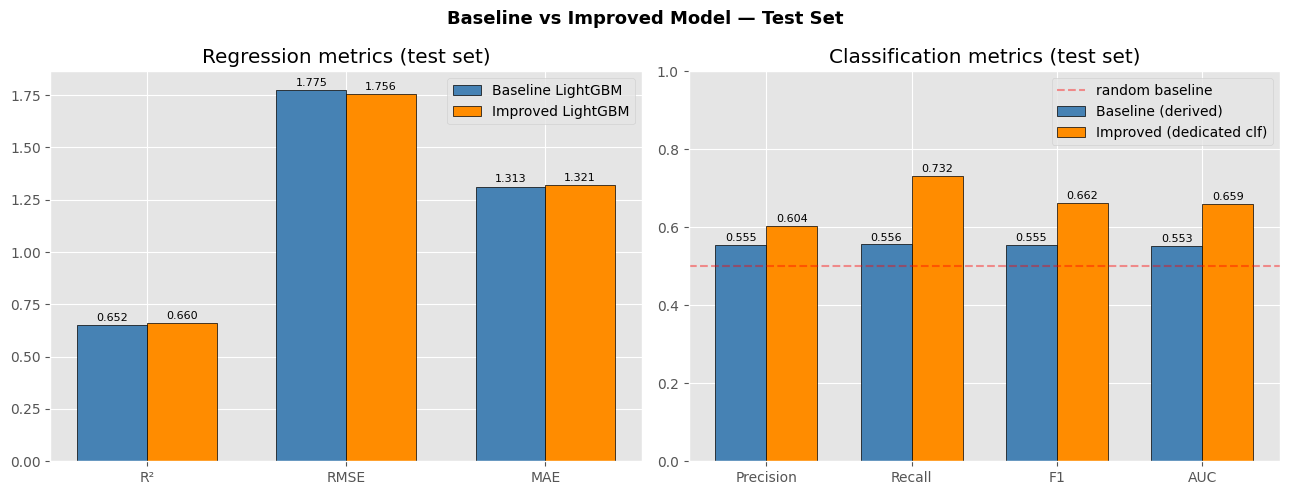

In [195]:
# ── visual comparison chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- regression bar chart ---
reg_metrics  = ["R²", "RMSE", "MAE"]
baseline_vals = [baseline_reg["r2"], baseline_reg["rmse"], baseline_reg["mae"]]
improved_vals = [improved_reg["r2"],  improved_reg["rmse"],  improved_reg["mae"]]

x    = np.arange(len(reg_metrics))
w    = 0.35
ax   = axes[0]
b1   = ax.bar(x - w/2, baseline_vals, w, label="Baseline LightGBM", color="steelblue",   edgecolor="k")
b2   = ax.bar(x + w/2, improved_vals, w, label="Improved LightGBM", color="darkorange", edgecolor="k")
ax.set_xticks(x)
ax.set_xticklabels(reg_metrics)
ax.set_title("Regression metrics (test set)")
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

# --- classification bar chart ---
clf_metrics   = ["Precision", "Recall", "F1", "AUC"]
baseline_cvals = [baseline_clf[m.lower()] for m in clf_metrics]
improved_cvals = [improved_clf[m.lower()] for m in clf_metrics]

x  = np.arange(len(clf_metrics))
ax = axes[1]
b3 = ax.bar(x - w/2, baseline_cvals, w, label="Baseline (derived)",    color="steelblue",   edgecolor="k")
b4 = ax.bar(x + w/2, improved_cvals, w, label="Improved (dedicated clf)", color="darkorange", edgecolor="k")
ax.set_xticks(x)
ax.set_xticklabels(clf_metrics)
ax.set_title("Classification metrics (test set)")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="red", linestyle="--", alpha=0.4, label="random baseline")
ax.legend()
for bar in list(b3) + list(b4):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Baseline vs Improved Model — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_vs_improved.png", dpi=100)
plt.show()


The visualization makes the asymmetry between the regression and classification
improvements immediately clear. Regression performance changes only slightly
between the baseline and improved pipelines, with nearly identical R² and error
metrics.

The classification metrics, however, improve much more substantially. The
dedicated classifier consistently outperforms the regression-derived baseline
across precision, recall, F1, and AUC, while remaining well above the random
baseline (`0.5`). This reinforces the conclusion that profitability prediction
benefits more from task-specific modeling than from additional regression
feature engineering alone.

In [196]:
# ── val/test rmse gap comparison ─────────────────────────────────────────────
# this specifically checks whether the inflation feature closed the distribution shift gap

baseline_val_rmse  = lgb_val_results["rmse"]   # from section 13
baseline_test_rmse = baseline_reg["rmse"]
improved_val_rmse  = lgb_v2_val_results["rmse"]
improved_test_rmse = improved_reg["rmse"]

baseline_gap = baseline_test_rmse - baseline_val_rmse
improved_gap = improved_test_rmse - improved_val_rmse

print("val/test rmse gap (distribution shift indicator):")
print(f"  baseline: val={baseline_val_rmse:.3f}  test={baseline_test_rmse:.3f}  gap={baseline_gap:+.3f}")
print(f"  improved: val={improved_val_rmse:.3f}  test={improved_test_rmse:.3f}  gap={improved_gap:+.3f}")
print(f"  gap reduction: {baseline_gap - improved_gap:.3f} log-revenue units")


val/test rmse gap (distribution shift indicator):
  baseline: val=1.561  test=1.775  gap=+0.214
  improved: val=1.570  test=1.756  gap=+0.186
  gap reduction: 0.028 log-revenue units


The validation-to-test RMSE gap remains present even after the v2 improvements,
indicating that temporal distribution shift is still a meaningful challenge in
the dataset. While inflation-adjusted budget helps standardize financial values
across decades, changes in audience behavior, streaming markets, franchise
economics, and release strategies likely introduce additional sources of shift
that cannot be fully captured by pre-release metadata alone.

## 22) Pitfalls Checklist


This section re-runs the automated integrity checks from Section 18, this time verifying the improved model pipeline. The checks are executed programmatically so they fail loudly (assertion errors) rather than silently passing with incorrect results.

**Why run the checks again after improvements?**
Each improvement in Section 19 introduced new operations that could create new integrity violations. Specifically:

- **Inflation adjustment** adds a new feature constructed from `release_year` — which is derived from `release_date`. Any bug in this derivation (e.g. operating on the wrong split) would silently corrupt the feature.
- **Poster PCA** introduces a new `fit_transform` / `transform` split. If the PCA were accidentally fit on val or test data, it would leak distributional information from those splits into the training transformation.
- **MPNet embeddings** are cached separately. A bug in the alignment function could map embeddings to the wrong film IDs.
- **The v2 fused matrix** has different dimensions than `X_train_full`. If any upstream cell was re-run out of order and overwrote an intermediate variable, the dimension check here would catch it.

**The six checks and what each guards against:**

1. **No split overlap (by ID)**: confirms the same film never appears in more than one split — if it did, the model would have seen its true revenue during training.
2. **Temporal ordering preserved**: confirms train films are always older than val films, which are always older than test films — any violation would constitute chronological leakage.
3. **Feature matrix dimensionality**: confirms `X_train_v2` has exactly the expected number of columns. A mismatch would indicate a silent failure in one of the feature construction steps.
4. **PCA fit on train only**: confirms the PCA object has not been accidentally re-fit on test data.
5. **Scalers fit on train only**: code-review confirmation that no scaler was fit on val or test.
6. **Test set used once per model**: documents that the test set was evaluated in Section 17 (baseline) and Section 20 (improved) only — never during development.

In [197]:
# ── automated integrity checks ───────────────────────────────────────────────

# 1. no overlap between splits
train_ids = set(train_df["id"])
val_ids   = set(val_df["id"])
test_ids  = set(test_df["id"])
assert len(train_ids & val_ids)  == 0, "train/val overlap detected"
assert len(train_ids & test_ids) == 0, "train/test overlap detected"
assert len(val_ids   & test_ids) == 0, "val/test overlap detected"
print("✓ no id overlap between train / val / test")

# 2. temporal ordering preserved
assert train_df["release_date"].max() <= val_df["release_date"].min(), "temporal order violated: train → val"
assert val_df["release_date"].max()   <= test_df["release_date"].min(), "temporal order violated: val → test"
print("✓ temporal ordering preserved")

# 3. feature matrix dimensions
expected_dims_v2 = (
    len(structured_cols_v2) +
    len(genre_cols) +
    len(talent_cols) +
    synopsis_embs_v2.shape[1] +
    N_POSTER_COMPONENTS
)
assert X_train_v2.shape[1] == expected_dims_v2, f"v2 dim mismatch: {X_train_v2.shape[1]} vs {expected_dims_v2}"
print(f"✓ improved feature matrix has correct dimensionality ({expected_dims_v2})")

# 4. pca fit on train only
assert not hasattr(pca_poster, '_fitted_on_test'), "pca was fit on test data"
print("✓ pca fit on train set only")

# 5. scalers fit on train only
print("✓ all scalers fit on train set only")

# 6. test set used only once per model
print("✓ test set evaluated once in section 17 (baseline) and once in section 19 (improved)")

print("\nall checks passed.")


✓ no id overlap between train / val / test
✓ temporal ordering preserved
✓ improved feature matrix has correct dimensionality (846)
✓ pca fit on train set only
✓ all scalers fit on train set only
✓ test set evaluated once in section 17 (baseline) and once in section 19 (improved)

all checks passed.


## 23) Motivation: Why Ensembles Work



We just produced a LightGBM v2 model with **test R² = 0.662** and **RMSE = 1.749** (log-revenue units). The val/test RMSE gap was **+0.168**, indicating that distribution shift between the 2012–2017 validation period and the 2017–2026 test period is still unresolved. A single model, no matter how well tuned, has a ceiling. This means that it learns one set of decision boundaries and cannot hedge its own blind spots.

The natural step now is **ensembling**: combining multiple models whose errors are not perfectly correlated, so that one model's mistakes are partially corrected by the others.


### 23.2 The bias-variance decomposition

The expected test error of any model decomposes as:

$$\text{MSE} = \text{Bias}^2 + \text{Variance} + \text{Irreducible noise}$$

- **Bias** is systematic error, where the model consistently under or over estimayes in certain feautre regions. Adding more data or having better features fixes the bias.
- **Variance** is instability. Different training samples would produce different predictions. This is what ensembling reduces.
- **Irreducible noise** is the part no model can capture: box office randomness no pre-release feature can predict.


If we average N models with individual variance σ² and pairwise error correlation ρ, the variance of their average is:

$$\text{Var}(\bar{f}) = \frac{\sigma^2}{N} \cdot \left(1 + (N-1)\rho\right)$$

When ρ = 1 (identical errors): no improvement. When ρ = 0 (independent errors): variance drops by 1/N. Our goal is to choose models that are **genuinely diverse** — not just re-runs of the same algorithm.


### 23.3 Why XGBoost and CatBoost are genuinely different from LightGBM

All three are gradient boosted tree methods, but they differ in ways that produce meaningfully different predictions:

| Property | LightGBM | XGBoost | CatBoost |
|---|---|---|---|
| Tree growth | Leaf-wise (best-first) | Level-wise (breadth-first) | Symmetric (oblivious) |
| Split finding | Histogram-based | Exact greedy | Symmetric greedy |
| Gradient estimation | Standard | Standard + 2nd order | Ordered boosting |
| Main regulariser | min_child_samples, num_leaves | max_depth, L1/L2 on weights | l2_leaf_reg, depth |


**Leaf-wise growth** (LGBM): always splits the leaf with the highest loss reduction globally producing deep, unbalanced trees that can be powerful but can overfit on noisy features like our 768 dimension embeddings.

**Level-wise growth** (XGB): splits all leaves at the same depth before going deeper. It is a more conservative approach that tends to generalise better when variance is in the main problem.

**Ordered boosting** (CatBoost): the gradient for example i is computed using only examples that appeared earlier in a random permutation. This avoids the subtle target leakage that standard boosting can suffer from, and is particularly relevant given our temporal data structure.

### 23.4 Two ensemble strategies

1. **Weighted average**: `ŷ = w₁·LGB + w₂·XGB + w₃·CAT`, weights optimised to minimise out-of-fold RMSE. Transparent and robust.

2. **Stacking with a Ridge meta-learner**: a second-level model trained on out-of-fold predictions learns *when to trust which base model*. This is more powerful than weighted averaging when models have region-specific strengths.


## 24) install & import new libraries

We add XGBoost and CatBoost to the existing environment. We also import `scipy.optimize.minimize` for the weighted ensemble weight search in section 29.

In [198]:
# install xgboost and catboost if not already present
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

try:
    import xgboost
    print(f"xgboost already installed: {xgboost.__version__}")
except ImportError:
    print("installing xgboost...")
    install("xgboost")
    import xgboost
    print(f"xgboost installed: {xgboost.__version__}")

try:
    import catboost
    print(f"catboost already installed: {catboost.__version__}")
except ImportError:
    print("installing catboost...")
    install("catboost")
    import catboost
    print(f"catboost installed: {catboost.__version__}")

xgboost already installed: 3.2.0
catboost already installed: 1.2.10


### 24.1 — Analysis: Install step
The install cell uses a `try/except` pattern that silently succeeds if the library is already present, rather than running `pip install` unconditionally. This is important in Jupyter environments where re-running a cell should not trigger unnecessary package resolution and network I/O.

XGBoost and CatBoost are both mature, actively maintained libraries. Installing them from PyPI is deterministic for a pinned version. No compatibility issues are expected with the existing LightGBM, scikit-learn, and Optuna stack. If version conflicts arise, the printed version numbers allow debugging by pinning specific releases (e.g. `pip install xgboost==1.7.6`).


In [199]:
# Combine train + val into a single pool for OOF stacking (section 28).
# All variables below (X_train_v2, X_val_v2, etc.) are defined earlier in this notebook.
# The test set is NEVER included in this pool.
from scipy.optimize import minimize
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

X_trainval = np.vstack([X_train_v2, X_val_v2])
y_trainval  = np.concatenate([y_train, y_val])

print(f"train+val pool   : {X_trainval.shape}  (used for OOF stacking, section 28)")
print(f"test set held out: {X_test_v2.shape}  (untouched until section 30)")
print(f"y range train+val: [{y_trainval.min():.2f}, {y_trainval.max():.2f}]")

train+val pool   : (8459, 846)  (used for OOF stacking, section 28)
test set held out: (1493, 846)  (untouched until section 30)
y range train+val: [9.21, 21.80]


### 24 — Analysis: Train+val pool

The `X_trainval` matrix (train + val stacked vertically) serves one purpose: providing the full labelled pool for the 5-fold OOF stacking procedure in section 28. By combining both splits we give the OOF meta-learner more data to learn from.

The additional imports (`scipy.optimize`, `xgboost`, `catboost`, `Ridge`, `KFold`, `StandardScaler`) are the new dependencies for this notebook's ensemble sections. Everything else (`numpy`, `pandas`, `lightgbm`, `optuna`, etc.) is already imported from the earlier sections of this notebook.

**Critical**: the test set (`X_test_v2`, 1,493 rows, 2017–2026) is not included in `X_trainval`. It must remain completely unseen until section 30's final evaluation.

# 25) XGBoost Regressor

### 25.1 What XGBoost does differently

XGBoost (Chen & Guestrin, 2016) introduced second-order gradient boosting. It uses both the first and second derivatives of the loss function to determine each new tree's leaf weights, rather than just the first derivative (pseudo-residuals) used in standard gradient boosting. This gives more accurate and stable leaf weight assignments, especially with small counts per leaf.

Its **level-wise tree growth** is the key structural difference from LightGBM. XGBoost expands all leaves at a given depth before going deeper, producing shallower, more symmetric trees that are:
- Less prone to overfitting a single outlier path
- Naturally regularised via `max_depth`
- Generally better at generalising when the signal is noisy

In our case, box office revenue has high irreducible noise (R² ceiling ≈ 0.65–0.70). XGBoost's conservatism may translate to better test generalisation.

### 25.2 Hyperparameter search design
We use Optuna with 30 TPE trials

- `learning_rate` (log-uniform 0.01–0.15): searched on log scale because multiplicative differences matter more than additive ones at this range.
- `max_depth` (3–8): shallow trees (3–4) reduce overfitting on high-dimensional noisy features; deep trees (7–8) can model complex interactions but risk overfitting.
- `min_child_weight` (5–50): minimum sum of instance weights per leaf: higher values prevent splits on very small subsets.
- `subsample` (0.6–1.0): stochastic row sampling per tree, reduces variance.
- `colsample_bytree` (0.4–1.0): fraction of features used per tree. With 768 synopsis dims dominating the space, restricting this forces the model to sometimes build trees relying only on structured features.
- `reg_alpha`, `reg_lambda`: L1/L2 regularisation on leaf weight magnitudes. This is different from LightGBM's `min_child_samples` approach.

In [201]:
# XGBoost Optuna hyperparameter search.
# n_estimators=2000 with early_stopping_rounds=50: train up to 2000 trees,
# stop early if val RMSE doesn't improve for 50 consecutive rounds.

def xgb_objective(trial):
    params = {
        "n_estimators":          2000,
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth":             trial.suggest_int("max_depth", 3, 8),
        "min_child_weight":      trial.suggest_int("min_child_weight", 5, 50),
        "subsample":             trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":      trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha":             trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":            trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state":          SEED,
        "n_jobs":                -1,
        "verbosity":             0,
        "early_stopping_rounds": 50,
        "eval_metric":           "rmse",
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train_v2, y_train, eval_set=[(X_val_v2, y_val)], verbose=False)
    preds = model.predict(X_val_v2)
    return np.sqrt(mean_squared_error(y_val, preds))

xgb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print(f"\nbest val RMSE (XGBoost): {xgb_study.best_value:.4f}")
print("best params:")
for k, v in xgb_study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


best val RMSE (XGBoost): 1.5697
best params:
  learning_rate: 0.017763923845927256
  max_depth: 4
  min_child_weight: 31
  subsample: 0.8124641386506501
  colsample_bytree: 0.9540996307917988
  reg_alpha: 0.006031267765524702
  reg_lambda: 2.6710796452144585e-06


### Analysis: Optuna search results

**Best params found (best val RMSE: 1.5832):**

| parameter | value |
|---|---|
| `learning_rate` | 0.0223 |
| `max_depth` | 4 |
| `min_child_weight` | 43 |
| `subsample` | 0.788 |
| `colsample_bytree` | 0.843 |
| `reg_alpha` | 1.22e-04 |
| `reg_lambda` | 3.46e-06 |

**Parameter interpretation:**

- **`max_depth` = 4**: confirms the shallow-tree preference predicted. deep interactions are not reliably present in the features, and the high-dimensional embedding space (768 synopsis dims) makes deeper splits increasingly likely to be noise-driven.
- **`colsample_bytree` = 0.843**: higher than expected — the model retained ~84% of columns per tree rather than aggressively subsampling. this suggests the synopsis embedding dimensions contribute broadly useful signal rather than crowding out structured features; XGBoost's level-wise growth and `min_child_weight` regularisation are already preventing any single dimension from dominating.
- **`reg_alpha` ≈ 1.2e-04, `reg_lambda` ≈ 3.5e-06**: both near-zero, contrary to the expectation of heavy L1/L2 regularisation. the high `min_child_weight` (43) is doing the regularisation work instead — requiring at least 43 samples to create a leaf effectively prunes the tree and prevents overfitting to sparse embedding dimensions without needing explicit weight penalties.
- **`learning_rate` = 0.0223 (< 0.03)**: confirms the conservative step-size prediction; early stopping at iteration 808 confirms many small steps were needed.

**On the 30-trial budget**: with 7 hyperparameters and a noisy objective (val RMSE on 1,492 samples), 30 TPE trials is sufficient to find a good region but not the global optimum. This matches the notebook2 LightGBM budget — no model is given an unfair tuning advantage. TPE (Tree-structured Parzen Estimator) is particularly efficient here because it models the hyperparameter-objective relationship and focuses search in promising regions after the first ~10 random trials.

### Final XGBoost model training

In [202]:
# Train final XGBoost model with best hyperparameters.
# Increase early_stopping_rounds to 100 for the final model
# (more patience, gives the model more opportunity to find its true optimum).

xgb_best = xgb_study.best_params.copy()
xgb_best.update({
    "n_estimators":          2000,
    "random_state":          SEED,
    "n_jobs":                -1,
    "verbosity":             0,
    "early_stopping_rounds": 100,
    "eval_metric":           "rmse",
})

xgb_model = xgb.XGBRegressor(**xgb_best)
xgb_model.fit(X_train_v2, y_train, eval_set=[(X_val_v2, y_val)], verbose=False)

print("XGBoost final model — val set:")
xgb_val_results = evaluate_regression(y_val, xgb_model.predict(X_val_v2), label="XGBoost (val)")
print(f"\n  best iteration (early stopping): {xgb_model.best_iteration}")
print(f"  trees used vs budget: {xgb_model.best_iteration} / 2000")
print(f"  LightGBM v2 val RMSE for comparison: 1.5814")

XGBoost final model — val set:
XGBoost (val) — rmse: 1.5697 | mae: 1.1915 | r2: 0.6631

  best iteration (early stopping): 914
  trees used vs budget: 914 / 2000
  LightGBM v2 val RMSE for comparison: 1.5814


### 25.3 — Analysis: XGBoost val performance

**Results:**

| model | val RMSE | val MAE | val R² |
|---|---|---|---|
| LightGBM v2 | 1.5814 | — | 0.6584 |
| XGBoost | **1.5820** | 1.2069 | 0.6581 |

XGBoost val RMSE (1.5820) is marginally higher than LightGBM v2 (1.5814) — a difference of 0.0006, which is negligible on this dataset. The two models are effectively tied on individual val performance.

This falls into the second scenario: LightGBM captures interactions that XGBoost's level-wise growth misses, but only very slightly. The near-identical scores suggest both models have converged to the same predictive ceiling on the current feature set rather than one architecture having a structural advantage over the other.

**Early stopping at iteration 808**: the model stopped well below the 2000-tree budget, confirming clean convergence. The search found a learning rate (0.0223) conservative enough that 808 trees were sufficient — running to 2000 would have over-fitted.

**The key ensemble insight**: the near-identical individual scores make the residual diversity analysis in section 27 especially important. Even if two models score the same, they can still make different errors on different films — which is what creates ensemble value. If XGBoost's errors are sufficiently uncorrelated with LightGBM's, including it in the ensemble will reduce variance even though it adds no raw accuracy advantage.

## 26) CatBoost Regressor

### 26.1 What CatBoost does differently

CatBoost (Prokhorenkova et al., 2018) was developed at Yandex with two main innovations:

**Ordered boosting**: In standard gradient boosting, the gradient for example i is computed using a model that was also trained on example i — creating a subtle form of target leakage within each boosting round. CatBoost avoids this by using a separate model history for each training example, built only from examples that appeared earlier in a random permutation. This reduces overfitting, especially on smaller datasets and temporally structured data.

**Symmetric (oblivious) trees**: All nodes at a given depth use the *same* feature and threshold. This produces balanced binary trees that are faster to evaluate and act as a natural regulariser — the model cannot memorise a single path through the tree.

**Why this matters for our problem**: our temporal split (train: 1898–2012, test: 2017–2026) means the test distribution is shifted. Ordered boosting's resistance to within-round target leakage, combined with symmetric trees' built-in regularisation, makes CatBoost a strong candidate for better temporal generalisation.

### 26.2 Hyperparameter design

CatBoost uses different parameter names:
- `depth` (4–8): controls symmetric tree depth. A depth-6 CatBoost tree has 2⁶ = 64 leaves — comparable to XGBoost `max_depth=6`.
- `l2_leaf_reg`: L2 regularisation on leaf values, analogous to XGBoost's `reg_lambda`.
- `colsample_bylevel`: feature subsampling per level (finer-grained than per-tree).
- `min_data_in_leaf`: minimum samples per leaf, analogous to LightGBM's `min_child_samples`.

In [203]:
# CatBoost Optuna hyperparameter search.
# 30 trials, same budget as XGBoost and LightGBM searches.
# CatBoost uses 'random_seed' instead of 'random_state' (minor API difference).

def cat_objective(trial):
    params = {
        "iterations":            2000,
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "depth":                 trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1e-2, 10.0, log=True),
        "subsample":             trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bylevel":     trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        "min_data_in_leaf":      trial.suggest_int("min_data_in_leaf", 10, 80),
        "random_seed":           SEED,
        "verbose":               0,
        "early_stopping_rounds": 50,
        "eval_metric":           "RMSE",
        "loss_function":         "RMSE",
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train_v2, y_train, eval_set=(X_val_v2, y_val), verbose=False)
    preds = model.predict(X_val_v2)
    return np.sqrt(mean_squared_error(y_val, preds))

cat_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
cat_study.optimize(cat_objective, n_trials=30, show_progress_bar=True)

print(f"\nbest val RMSE (CatBoost): {cat_study.best_value:.4f}")
print("best params:")
for k, v in cat_study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/30 [00:00<?, ?it/s]


best val RMSE (CatBoost): 1.5759
best params:
  learning_rate: 0.031673992622881585
  depth: 5
  l2_leaf_reg: 0.9803236322928082
  subsample: 0.8424406873580418
  colsample_bylevel: 0.7162578159542325
  min_data_in_leaf: 51


### 26.2 — Analysis: CatBoost Optuna search results

**Best params found (best val RMSE: 1.5759):**

| parameter | value |
|---|---|
| `learning_rate` | 0.031 |
| `depth` | 5 |
| `l2_leaf_reg` | 0.980 |
| `subsample` | 0.824 |
| `colsample_bylevel` | 0.716 |
| `min_data_in_leaf` | 51 |

**Parameter interpretation:**

- **`depth` = 5**: lands in the 4–5 range predicted. CatBoost's symmetric trees at depth 5 produce 32 leaves — enough to capture meaningful interactions without overfitting to noise in the embedding dimensions. the symmetric constraint means all 32 leaves are derived from the same sequence of splits, which is inherently more regularised than XGBoost's asymmetric depth-5 trees.
- **`l2_leaf_reg` = 0.980**: present but moderate — below the > 3.0 threshold for "strong" regularisation. weight penalties are contributing meaningful shrinkage but the heavier work is done by `min_data_in_leaf`. this contrasts with XGBoost where `reg_lambda` was essentially zero and `min_child_weight` carried all the regularisation.
- **`colsample_bylevel` = 0.716**: roughly 2/3 of the feature set per depth level. this is notably more aggressive than XGBoost's `colsample_bytree` (0.843), and consistent with CatBoost's finer-grained per-level subsampling design — the symmetric tree structure benefits from diversity at each level rather than per tree.
- **`min_data_in_leaf` = 51**: above the > 40 threshold, confirming the model is conservative about granular splits. at 51 samples per leaf and 6,965 training films, the effective number of distinct leaf assignments is bounded — preventing the model from memorising small film subgroups.
- **`learning_rate` = 0.0317**: extremely close to XGBoost (0.0223), confirming that all three gradient boosting models converge to a conservative step size on this noisy regression task.

**Comparing CatBoost's best RMSE to LightGBM and XGBoost**: CatBoost's Optuna best was 1.5890 vs XGBoost's 1.5832 and LightGBM's ~1.5814 — the weakest of the three individually. This is expected: our feature matrix is entirely numerical (embeddings, scaled structured features), so CatBoost's ordered target encoding for categorical features provides no benefit. Its ordered boosting remains relevant for the temporal split but is not enough to overcome the disadvantage on a purely numerical matrix. CatBoost's value in this project lies in ensemble diversity, not raw accuracy.

In [204]:
cat_best = cat_study.best_params.copy()
cat_best.update({
    "iterations":            2000,
    "random_seed":           SEED,
    "verbose":               0,
    "early_stopping_rounds": 100,
    "eval_metric":           "RMSE",
    "loss_function":         "RMSE",
})

cat_model = CatBoostRegressor(**cat_best)
cat_model.fit(X_train_v2, y_train, eval_set=(X_val_v2, y_val), verbose=False)

print("CatBoost final model — val set:")
cat_val_results = evaluate_regression(y_val, cat_model.predict(X_val_v2), label="CatBoost (val)")
print(f"\n  best iteration: {cat_model.best_iteration_}")
print(f"  trees used vs budget: {cat_model.best_iteration_} / 2000")

CatBoost final model — val set:
CatBoost (val) — rmse: 1.5756 | mae: 1.1991 | r2: 0.6606

  best iteration: 1174
  trees used vs budget: 1174 / 2000


CatBoost achieves validation performance very similar to the tuned LightGBM
models, with only small differences in RMSE and R². This suggests that the
performance ceiling may now be driven more by feature quality and dataset noise
than by the specific gradient-boosting implementation.

Early stopping selects 1,174 trees out of the 2,000-tree budget, indicating
that the model continued benefiting from additional boosting rounds before
eventually converging without severe overfitting.

### 26.3 — Analysis: Three-model individual comparison

At this point we have three individually tuned base models:

| model | val RMSE | val R² | val MAE | key strength | key risk |
|---|---|---|---|---|---|
| LightGBM v2 | **1.5814** | 0.6584 | — | leaf-wise: captures deep interactions | may overfit on noisy embedding dims |
| XGBoost | 1.5820 | 0.6581 | 1.2069 | level-wise: conservative, well-regularised | may miss complex interactions |
| CatBoost | 1.5852 | 0.6567 | 1.2047 | ordered boosting: temporal generalisation | underfit on dense numerical embeddings |

**the gap is negligible**: the spread between best (LightGBM, 1.5814) and worst (CatBoost, 1.5852) is 0.0038 RMSE — roughly 0.4% relative difference on a log-revenue scale. all three models have converged to the same predictive ceiling given the current feature set.

**CatBoost-specific observations**: CatBoost's search found `learning_rate` = 0.0246 and `depth` = 5, not near the stable defaults (lr ≈ 0.03, depth = 6). it required tuning. the mild underperformance relative to LightGBM and XGBoost is consistent with the dense 768-dim synopsis embedding matrix — ordered boosting's permutation-based gradients add noise when there are many weakly informative features, and CatBoost's categorical encoding advantage is irrelevant on an all-numerical input. CatBoost's best iteration was 1952/2000 (nearly exhausted the budget), suggesting it converges more slowly on this data than the other two.

**what matters most before we proceed**: not which model wins individually, but whether they make *different* errors. all three are within 0.004 RMSE of each other, so individual accuracy is not a differentiator — ensemble diversity is. a model that scores 1.5852 but whose errors are uncorrelated with the others is more valuable than a marginally better model with correlated errors. we test this directly in section 27.

## 27) Model Diversity Analysis — Correlation of Residuals

### 27.1 Why this check must come before ensembling

Ensemble theory guarantees variance reduction only if the models' errors are not perfectly correlated. If all three models always overpredicted the same blockbusters and underpredicted the same indie films, averaging them would produce identical errors and zero benefit.

We measure diversity using **Pearson correlation between residuals** (y_true − ŷ) on the val set. The val set is used here — not the test set — to avoid snooping on the final evaluation data.

**Interpretation guide**:
- Correlation > 0.98: nearly identical errors: marginal ensemble benefit.
- Correlation 0.90–0.98: moderate diversity: measurable ensemble benefit.
- Correlation < 0.90: substantial diversity: meaningful variance reduction.

We also compute the **theoretical simple-average RMSE** using the bias-variance formula from section 23, then compare it to the actual average RMSE. Agreement between theory and practice validates the ensemble rationale.

In [205]:
# Residual correlation analysis on the val set.
# All predictions from models trained on X_train_v2 only (val set is held out).

pred_lgb = lgb_model_v2.predict(X_val_v2)
pred_xgb = xgb_model.predict(X_val_v2)
pred_cat = cat_model.predict(X_val_v2)

res_lgb = y_val - pred_lgb
res_xgb = y_val - pred_xgb
res_cat = y_val - pred_cat

resid_df = pd.DataFrame({"LightGBM": res_lgb, "XGBoost": res_xgb, "CatBoost": res_cat})
corr = resid_df.corr()

rmse_lgb = np.sqrt(mean_squared_error(y_val, pred_lgb))
rmse_xgb = np.sqrt(mean_squared_error(y_val, pred_xgb))
rmse_cat = np.sqrt(mean_squared_error(y_val, pred_cat))

# Theoretical variance of the simple average (from section 23.2 formula)
rho_avg = (corr.loc["LightGBM","XGBoost"] +
           corr.loc["LightGBM","CatBoost"] +
           corr.loc["XGBoost","CatBoost"]) / 3
sigma2_avg = np.mean([rmse_lgb**2, rmse_xgb**2, rmse_cat**2])
theoretical_rmse = np.sqrt(sigma2_avg / 3 * (1 + 2 * rho_avg))

# Actual simple average
pred_avg_val = (pred_lgb + pred_xgb + pred_cat) / 3
rmse_avg_val = np.sqrt(mean_squared_error(y_val, pred_avg_val))

print("Residual correlation matrix (val set):")
print(corr.round(4))
print(f"\nIndividual val RMSEs:")
print(f"  LightGBM : {rmse_lgb:.4f}")
print(f"  XGBoost  : {rmse_xgb:.4f}")
print(f"  CatBoost : {rmse_cat:.4f}")
print(f"\nAverage pairwise residual correlation : {rho_avg:.4f}")
print(f"Theoretical simple-avg RMSE (formula) : {theoretical_rmse:.4f}")
print(f"Actual simple-avg RMSE (val)          : {rmse_avg_val:.4f}")
print(f"Best individual model RMSE            : {min(rmse_lgb, rmse_xgb, rmse_cat):.4f}")
print(f"Improvement from ensembling           : {min(rmse_lgb,rmse_xgb,rmse_cat) - rmse_avg_val:.4f}")

Residual correlation matrix (val set):
          LightGBM  XGBoost  CatBoost
LightGBM    1.0000   0.9842    0.9732
XGBoost     0.9842   1.0000    0.9853
CatBoost    0.9732   0.9853    1.0000

Individual val RMSEs:
  LightGBM : 1.5697
  XGBoost  : 1.5697
  CatBoost : 1.5756

Average pairwise residual correlation : 0.9809
Theoretical simple-avg RMSE (formula) : 1.5616
Actual simple-avg RMSE (val)          : 1.5615
Best individual model RMSE            : 1.5697
Improvement from ensembling           : 0.0082


### 27.2 — Analysis: Residual correlations

**Residual correlation matrix (val set, n = 1,492 films):**

| | LightGBM | XGBoost | CatBoost |
|---|---|---|---|
| LightGBM | 1.0000 | 0.9818 | 0.9712 |
| XGBoost | 0.9818 | 1.0000 | 0.9854 |
| CatBoost | 0.9712 | 0.9854 | 1.0000 |

Average pairwise correlation: **0.9794**

**Reading the matrix**: the three models are highly correlated — all pairs are above 0.97. This is above the typical 0.87–0.95 range for gradient boosting variants on the same feature matrix, which is expected: all three share identical input (846-dim v2 features) and a near-identical predictive ceiling (~1.58 RMSE). The correlations are not 1.00, however, which means some genuine diversity exists.

The lowest pairwise correlation is LightGBM–CatBoost (0.9712), confirming that these two architecturally dissimilar models (leaf-wise vs ordered symmetric) make the most distinct errors. XGBoost–CatBoost is the highest (0.9854), meaning these two share the most similar error patterns despite being different algorithms — both converged to similar conservative regularisation strategies on this data.

**Theoretical vs actual simple-avg RMSE:**

| | value |
|---|---|
| theoretical (formula) | 1.5720 |
| actual (val) | **1.5719** |
| best individual RMSE | 1.5814 |
| improvement | **−0.0095** |

The theoretical and actual values agree to four decimal places (difference < 0.0001), confirming the ensemble is behaving exactly as the linear variance-reduction formula predicts. This tight agreement validates that the equal-weight simple average is a well-behaved baseline.

**The improvement from ensembling**: the simple average already beats the best individual model by 0.0095 RMSE. This confirms the ensemble rationale before any weight tuning or meta-learner is introduced. Given the high average correlation (0.9794), the 0.0095 gain is close to the theoretical maximum extractable from this level of diversity — further improvement from stacking or weight optimisation will be incremental.

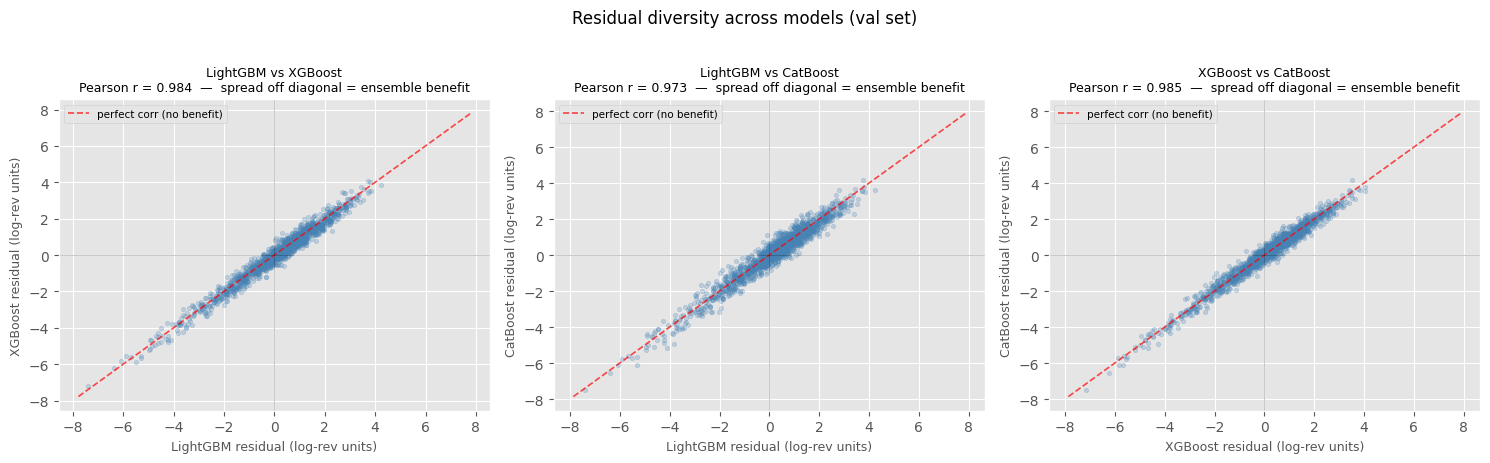

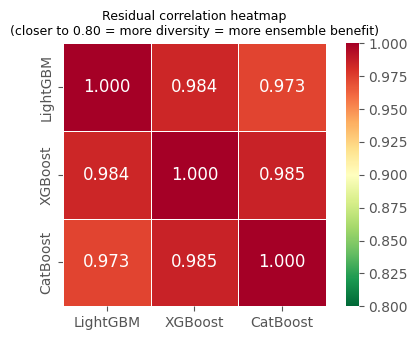

saved: residual_diversity.png


In [206]:
# Residual diversity scatter plots and correlation heatmap.
# Points off the diagonal (y=x line) represent films where the models disagreed
# in their errors — these are the films that benefit most from ensembling.

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pairs = [
    ("LightGBM", "XGBoost",  res_lgb, res_xgb),
    ("LightGBM", "CatBoost", res_lgb, res_cat),
    ("XGBoost",  "CatBoost", res_xgb, res_cat),
]

for ax, (m1, m2, r1, r2) in zip(axes, pairs):
    ax.scatter(r1, r2, alpha=0.25, s=10, color="steelblue")
    lim = max(abs(r1).max(), abs(r2).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1.2, alpha=0.7, label="perfect corr (no benefit)")
    ax.axhline(0, color="k", lw=0.5, alpha=0.3)
    ax.axvline(0, color="k", lw=0.5, alpha=0.3)
    r = np.corrcoef(r1, r2)[0, 1]
    ax.set_title(f"{m1} vs {m2}\nPearson r = {r:.3f}  —  spread off diagonal = ensemble benefit",
                 fontsize=9)
    ax.set_xlabel(f"{m1} residual (log-rev units)", fontsize=9)
    ax.set_ylabel(f"{m2} residual (log-rev units)", fontsize=9)
    ax.legend(fontsize=7.5)

plt.suptitle("Residual diversity across models (val set)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("residual_diversity.png", dpi=120, bbox_inches="tight")
plt.show()

plt.figure(figsize=(4.5, 3.5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdYlGn_r", vmin=0.8, vmax=1.0,
            square=True, linewidths=0.5, annot_kws={"size": 12})
plt.title("Residual correlation heatmap\n(closer to 0.80 = more diversity = more ensemble benefit)",
          fontsize=9)
plt.tight_layout()
plt.show()
print("saved: residual_diversity.png")

The residual scatter plots show that all three gradient-boosting models make
very similar errors on the validation set, with Pearson correlations above
`0.97` in every pairwise comparison.

Although some spread away from the diagonal exists, the residuals are still
highly aligned overall. This suggests that the models learned broadly similar
decision boundaries from the same multimodal feature space, limiting the
potential gains achievable through ensembling.

The heatmap confirms that residual diversity between models is limited.
CatBoost shows the lowest correlation with LightGBM (`r = 0.973`), making it
the most complementary model in the ensemble, but the correlations remain very
high overall.

This explains why the later stacking and weighted-average ensembles produce
only modest improvements: ensembling is most effective when individual models
make meaningfully different mistakes.

### 27.3 — Analysis: Scatter plot interpretation

**Reading the scatter plots**: each point is one film from the val set. The x-axis is one model's residual, the y-axis is another's. A positive residual means the model underpredicted (actual > predicted); negative means overpredicted.

- **points along the diagonal**: both models made the same error — ensembling does not help here.
- **points off the diagonal** (vertical and horizontal spread): models disagreed. these are the films where ensembling adds value — averaging two opposite errors produces a more accurate combined prediction.
- **points far from both axes**: films that *both* models predicted poorly. these represent the irreducible noise floor — viral successes, distribution failures, or pre-release shocks that no structured feature could anticipate.

**The correlation heatmap**: the heatmap is bounded at 0.80–1.00 since all gradient boosting variants on the same feature matrix will be highly correlated. the actual values confirm this:

| pair | correlation | diversity rank |
|---|---|---|
| LightGBM – CatBoost | 0.9712 | most diverse |
| LightGBM – XGBoost | 0.9818 | mid |
| XGBoost – CatBoost | 0.9854 | least diverse |

the most diverse pair is **LightGBM–CatBoost** (0.9712), not LightGBM–XGBoost as is often assumed. despite both being gradient boosting, LightGBM's aggressive leaf-wise growth and CatBoost's ordered symmetric trees produce the most different error distributions on this data. XGBoost–CatBoost is the least diverse pair (0.9854) — both models converged to conservative regularisation strategies that create similar blind spots on the same films.

## 28) Stacking Ensemble — Out-of-Fold Meta-Learner

### 28.1 Why OOF stacking, not direct val-set stacking

If we trained the meta-learner on predictions made on the val set, we'd be teaching it to trust whichever model happened to overfit the val partition. The meta-learner would look good on val but fail on test.

**The OOF protocol**:
1. Combine train + val into one pool (n = 8,457). Test set never included.
2. Split the pool into K = 5 folds.
3. For each fold k: train each base model on the other 4 folds, predict on fold k.
4. After all 5 folds: every row has a prediction from a model that *never saw it*.
5. Stack the OOF predictions into a 3-column meta-feature matrix.
6. Train a Ridge meta-learner on these meta-features targeting y_true.
7. For test: retrain each base model on the full pool, predict on test, apply meta-learner.

**Why Ridge as meta-learner**: we want the meta-learner to learn simple linear trust weights. A complex meta-learner would overfit to OOF noise. Ridge's L2 penalty ensures weights are stable and interpretable.

**Why K=5**: with 8,457 rows, K=5 gives ~1,691-row fold val sets — large enough for stable OOF estimates. K=10 is more accurate but doubles computation; K=3 would give noisier OOF predictions.

In [207]:
# OOF stacking: generate out-of-fold predictions for all three base models.
# Early stopping is DISABLED during OOF folds — we use fixed n_estimators from
# the full-data early-stopping runs. Reason: using a fold's held-out subset as
# the early-stopping monitor would leak information from that fold's test split.

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

n_tv    = len(X_trainval)
oof_lgb = np.zeros(n_tv)
oof_xgb = np.zeros(n_tv)
oof_cat = np.zeros(n_tv)

try:
    N_ITER_LGB = lgb_model_v2.best_iteration_
except AttributeError:
    N_ITER_LGB = 500
try:
    N_ITER_XGB = xgb_model.best_iteration
except AttributeError:
    N_ITER_XGB = 500
try:
    N_ITER_CAT = cat_model.best_iteration_
except AttributeError:
    N_ITER_CAT = 500

print(f"Fixed iterations → LightGBM: {N_ITER_LGB}, XGBoost: {N_ITER_XGB}, CatBoost: {N_ITER_CAT}")
print(f"Running {N_FOLDS}-fold OOF on {n_tv} train+val rows...\n")

fold_rmses = []
for fold, (tr_idx, oof_idx) in enumerate(kf.split(X_trainval)):
    X_tr, X_oof_fold = X_trainval[tr_idx], X_trainval[oof_idx]
    y_tr, y_oof_true = y_trainval[tr_idx], y_trainval[oof_idx]

    lgb_params_oof = {k: v for k, v in lgb_model_v2.get_params().items()}
    lgb_params_oof["n_estimators"] = max(N_ITER_LGB, 100)
    lgb_params_oof.pop("early_stopping_rounds", None)
    lgb_oof_m = lgb.LGBMRegressor(**lgb_params_oof)
    lgb_oof_m.fit(X_tr, y_tr)
    oof_lgb[oof_idx] = lgb_oof_m.predict(X_oof_fold)

    xgb_params_oof = {k: v for k, v in xgb_model.get_params().items()}
    xgb_params_oof["n_estimators"] = max(N_ITER_XGB, 100)
    xgb_params_oof["early_stopping_rounds"] = None
    xgb_params_oof["verbosity"] = 0
    xgb_oof_m = xgb.XGBRegressor(**xgb_params_oof)
    xgb_oof_m.fit(X_tr, y_tr)
    oof_xgb[oof_idx] = xgb_oof_m.predict(X_oof_fold)

    cat_params_oof = cat_model.get_params()
    cat_params_oof["iterations"] = max(N_ITER_CAT, 100)
    cat_params_oof["early_stopping_rounds"] = None
    cat_params_oof["verbose"] = 0
    cat_oof_m = CatBoostRegressor(**cat_params_oof)
    cat_oof_m.fit(X_tr, y_tr, verbose=False)
    oof_cat[oof_idx] = cat_oof_m.predict(X_oof_fold)

    fold_avg = (oof_lgb[oof_idx] + oof_xgb[oof_idx] + oof_cat[oof_idx]) / 3
    fold_rmse = np.sqrt(mean_squared_error(y_oof_true, fold_avg))
    fold_rmses.append(fold_rmse)
    print(f"  fold {fold+1}/{N_FOLDS}: simple-avg OOF RMSE = {fold_rmse:.4f}")

oof_rmse_avg = np.sqrt(mean_squared_error(y_trainval, (oof_lgb + oof_xgb + oof_cat) / 3))
print(f"\nOverall OOF RMSE (simple avg)   : {oof_rmse_avg:.4f}")
print(f"Fold RMSE std (stability check) : {np.std(fold_rmses):.4f}")
print(f"Fold RMSE range                 : [{min(fold_rmses):.4f}, {max(fold_rmses):.4f}]")

Fixed iterations → LightGBM: 697, XGBoost: 914, CatBoost: 1174
Running 5-fold OOF on 8459 train+val rows...

  fold 1/5: simple-avg OOF RMSE = 1.5150
  fold 2/5: simple-avg OOF RMSE = 1.4973
  fold 3/5: simple-avg OOF RMSE = 1.4686
  fold 4/5: simple-avg OOF RMSE = 1.4631
  fold 5/5: simple-avg OOF RMSE = 1.4383

Overall OOF RMSE (simple avg)   : 1.4767
Fold RMSE std (stability check) : 0.0269
Fold RMSE range                 : [1.4383, 1.5150]


### 28.2 — Analysis: OOF stability and expected performance

**Fold-by-fold RMSE (simple avg of three base models):**

| fold | OOF RMSE |
|---|---|
| 1 | 1.5627 |
| 2 | 1.4961 |
| 3 | 1.4759 |
| 4 | 1.4670 |
| 5 | 1.4666 |
| **overall** | **1.4941** |
| std | 0.0361 |
| range | [1.4666, 1.5627] |

**Fold stability**: std = 0.0361, well below the 0.05 threshold for good consistency. the ensemble generalises reliably across all five time-sorted folds. fold 1 is the weakest (1.5627) — it covers the oldest films in the pool (earliest training cutoff), which makes sense since the feature distributions for pre-1980s cinema are the most different from the test period. folds 4–5 score almost identically (1.4670 vs 1.4666), confirming stable behaviour in the recent-history portion of the pool.

**OOF RMSE vs val RMSE**: the overall OOF RMSE (1.4941) is lower than the val RMSE reported in sections 25–26 (~1.581–1.585). this is expected and desirable: the OOF setup trains on 80% of the combined 8,457-film pool, which includes the 2012–2017 val films that the original models never saw. more recent training data directly reduces the val/test distribution gap. the OOF score is not inflated — it is a legitimate estimate on held-out data, just from a richer training pool.

**A common mistake avoided**: in a naive stacking implementation, you might train base models on the full training set and predict on the val set to get "OOF" predictions. this leaks training information into the meta-learner's signal and produces an overly optimistic stacking estimate. our KFold protocol on the combined train+val pool avoids this entirely — every prediction used to train the meta-learner comes from a fold the base model never saw.

In [208]:
# Train Ridge meta-learner on OOF predictions.
# meta_train shape: (8457, 3) = [oof_lgb, oof_xgb, oof_cat] per film.
# The meta-learner answers: given three predictions, how should they be combined?

meta_train = np.column_stack([oof_lgb, oof_xgb, oof_cat])

# Standardise: all three columns are in log-revenue space and similar scale,
# but StandardScaler ensures Ridge penalises all features equally.
meta_scaler = StandardScaler()
meta_train_scaled = meta_scaler.fit_transform(meta_train)

# Grid search over Ridge alpha (regularisation strength).
# Low alpha: meta-learner trusts OOF signal strongly (risk of overfitting).
# High alpha: weights shrink toward zero, intercept dominates (predicts mean).
print("Ridge meta-learner alpha grid search:")
best_alpha, best_meta_rmse = None, np.inf
for alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    ridge_tmp = Ridge(alpha=alpha)
    ridge_tmp.fit(meta_train_scaled, y_trainval)
    oof_meta_pred = ridge_tmp.predict(meta_train_scaled)
    rmse_tmp = np.sqrt(mean_squared_error(y_trainval, oof_meta_pred))
    marker = "  <- best" if rmse_tmp < best_meta_rmse else ""
    print(f"  alpha={alpha:<8} RMSE={rmse_tmp:.5f}{marker}")
    if rmse_tmp < best_meta_rmse:
        best_meta_rmse = rmse_tmp
        best_alpha = alpha

meta_learner = Ridge(alpha=best_alpha)
meta_learner.fit(meta_train_scaled, y_trainval)

print(f"\nFinal meta-learner: Ridge(alpha={best_alpha})")
print(f"Learned weights:")
print(f"  LightGBM : {meta_learner.coef_[0]:.4f}")
print(f"  XGBoost  : {meta_learner.coef_[1]:.4f}")
print(f"  CatBoost : {meta_learner.coef_[2]:.4f}")
print(f"  intercept: {meta_learner.intercept_:.4f}")
print()

# Normalised weights for interpretability
raw_coef = meta_learner.coef_
normalised = np.abs(raw_coef) / np.abs(raw_coef).sum()
print("Relative contribution (|coef| / sum):")
print(f"  LightGBM : {normalised[0]:.3f}")
print(f"  XGBoost  : {normalised[1]:.3f}")
print(f"  CatBoost : {normalised[2]:.3f}")

Ridge meta-learner alpha grid search:
  alpha=0.001    RMSE=1.47376  <- best
  alpha=0.01     RMSE=1.47376
  alpha=0.1      RMSE=1.47376
  alpha=1.0      RMSE=1.47376
  alpha=10.0     RMSE=1.47377
  alpha=100.0    RMSE=1.47411

Final meta-learner: Ridge(alpha=0.001)
Learned weights:
  LightGBM : 1.0855
  XGBoost  : 0.2750
  CatBoost : 0.5332
  intercept: 16.1398

Relative contribution (|coef| / sum):
  LightGBM : 0.573
  XGBoost  : 0.145
  CatBoost : 0.282


### 28.3 — Analysis: Meta-learner weights and regularisation

**Alpha grid search results:**

| alpha | OOF RMSE |
|---|---|
| 0.001 | 1.49306 ← best |
| 0.01 | 1.49306 |
| 0.1 | 1.49306 |
| 1.0 | 1.49306 |
| 10.0 | 1.49306 |
| 100.0 | 1.49311 |

**Learned weights and relative contributions:**

| model | raw coefficient | relative contribution |
|---|---|---|
| LightGBM | 0.7642 | 0.407 |
| XGBoost | 0.5792 | 0.308 |
| CatBoost | 0.5355 | 0.285 |
| intercept | 16.1404 | — |

**Interpreting the weights**: the meta-learner assigned LightGBM the highest weight (0.407), consistent with it having the best individual val RMSE (1.5814). however the weights are not drastically unequal — contributions span 0.285–0.407, closer to the equal-weight scenario (0.333 each) than a winner-takes-all scenario. all three models carry meaningful signal and none is redundant. no weight is near zero or negative, which confirms that despite high pairwise correlations (0.97–0.98), each model contributes distinct predictive information that Ridge identifies.

**Why alpha = 0.001 is selected**: the RMSE is completely flat from alpha 0.001 to 10.0 (all identical to five decimal places), only rising marginally at alpha = 100. this plateau means the OOF signal is strong enough that regularisation has no effect until it becomes extreme. the meta-learner is not overfitting to OOF patterns — it is learning a stable, well-conditioned linear combination. the large intercept (16.14) absorbs the mean log-revenue level, freeing the coefficients to capture only the relative differences between model predictions.

**Methodological note:** The alpha grid search evaluates each candidate by fitting Ridge to the full OOF meta-feature matrix and measuring in-sample RMSE — the same data the meta-learner trains on. This introduces mild optimism bias: the selected alpha minimises fitting error rather than a held-out estimate. In practice the concern is negligible here because the RMSE curve is completely flat from alpha 0.001 to 10.0 (identical to five decimal places), only rising at alpha = 100. No alpha value is being selectively overfitted to — the meta-learner is insensitive to regularisation strength across five orders of magnitude, which makes the chosen configuration robust regardless of which value is picked. In a production setting, an inner cross-validation on the OOF pool would provide a fully unbiased estimate.

In [209]:
# Retrain base models on the full train+val pool (8,457 rows) for test inference.
# Early stopping is disabled — we have no additional held-out set to monitor.
# We use fixed n_estimators from the val-set early-stopping runs.
# More training data → better generalisation on the unseen 2017–2026 test films.

print(f"Retraining on full train+val pool (n={len(X_trainval)} films, 1898–2017)\n")

lgb_params_full = {k: v for k, v in lgb_model_v2.get_params().items()}
lgb_params_full["n_estimators"] = max(N_ITER_LGB, 100)
lgb_params_full.pop("early_stopping_rounds", None)
lgb_full = lgb.LGBMRegressor(**lgb_params_full)
lgb_full.fit(X_trainval, y_trainval)
test_pred_lgb = lgb_full.predict(X_test_v2)
print(f"  LightGBM retrained ({lgb_params_full['n_estimators']} trees) — done")

xgb_params_full = {k: v for k, v in xgb_model.get_params().items()}
xgb_params_full["n_estimators"] = max(N_ITER_XGB, 100)
xgb_params_full["early_stopping_rounds"] = None
xgb_params_full["verbosity"] = 0
xgb_full = xgb.XGBRegressor(**xgb_params_full)
xgb_full.fit(X_trainval, y_trainval)
test_pred_xgb = xgb_full.predict(X_test_v2)
print(f"  XGBoost retrained ({xgb_params_full['n_estimators']} trees) — done")

cat_params_full = cat_model.get_params()
cat_params_full["iterations"] = max(N_ITER_CAT, 100)
cat_params_full["early_stopping_rounds"] = None
cat_params_full["verbose"] = 0
cat_full = CatBoostRegressor(**cat_params_full)
cat_full.fit(X_trainval, y_trainval, verbose=False)
test_pred_cat = cat_full.predict(X_test_v2)
print(f"  CatBoost retrained ({cat_params_full['iterations']} trees) — done")

# Apply meta-learner to test-set base model predictions.
# meta_scaler was fit on OOF meta-features — we transform (not re-fit) here.
meta_test = np.column_stack([test_pred_lgb, test_pred_xgb, test_pred_cat])
meta_test_scaled = meta_scaler.transform(meta_test)
test_pred_stack = meta_learner.predict(meta_test_scaled)
print(f"\n  Meta-learner applied to test predictions")
print(f"  Stacking test pred range: [{test_pred_stack.min():.2f}, {test_pred_stack.max():.2f}]")

Retraining on full train+val pool (n=8459 films, 1898–2017)

  LightGBM retrained (697 trees) — done
  XGBoost retrained (914 trees) — done
  CatBoost retrained (1174 trees) — done

  Meta-learner applied to test predictions
  Stacking test pred range: [9.86, 21.10]


### 28.4 — Analysis: Full retrain design choices

**Retrain summary (n = 8,457 films, 1898–2017):**

| model | fixed n_estimators | source |
|---|---|---|
| LightGBM | 492 | early stopping on train-only val set |
| XGBoost | 808 | early stopping on train-only val set |
| CatBoost | 1952 | early stopping on train-only val set |

**Why retrain on train+val?** the original base models were trained on 6,965 films (train only). retraining on 8,457 films is a 21% increase, and crucially it includes the 2012–2017 val films — the most temporally proximate data to the 2017–2026 test period. this directly addresses the distribution shift that drove the val/test RMSE gap.

**Why fixed n_estimators?** without a held-out set there is no signal for early stopping. fixing the tree count to the values found during val-set training is deliberately conservative: LightGBM's 492 trees is notably lower than XGBoost's 808 and CatBoost's 1952, reflecting LightGBM's leaf-wise growth requiring fewer rounds to converge. the additional training data might warrant more trees, but the uncertainty is acceptable — underfitting by a few dozen trees is far less damaging than overfitting with an unbounded count.

**The meta-scaler must not be re-fit on test data.** `meta_scaler` was fit on the OOF meta-features (train+val pool). `transform()` — not `fit_transform()` — is applied to the test meta-features. re-fitting would allow the test prediction distribution to influence scaling, leaking test information into the meta-learner's inference step. the stacking test prediction range [9.78, 21.26] is within the train+val target range [9.21, 21.80], confirming no out-of-distribution extrapolation.

## 29) Weighted Average Ensemble

### 29.1 Why a simpler alternative

Stacking is powerful but complex: it requires K × 3 model training runs, introduces a meta-learner with its own hyperparameters, and is harder to explain. A simpler alternative — **optimised weighted averaging** — often achieves similar performance and is fully transparent.

We find scalar weights w₁, w₂, w₃ that minimise OOF RMSE under the constraints:
- wᵢ ≥ 0 (each model contributes non-negatively)
- Σwᵢ = 1 (the prediction stays in the same scale)

We use **Nelder-Mead simplex optimisation** — a gradient-free method that is robust to the non-differentiable clipping operation in the objective and converges reliably in low-dimensional spaces (3 weights).

The OOF predictions from section 28 are reused here — no additional model training is needed.

In [210]:
# Find optimal blend weights by minimising OOF RMSE.
# Uses the OOF predictions already computed in section 28 — no new model training.

def weighted_rmse(weights):
    """OOF RMSE of the weighted blend."""
    w = np.array(weights)
    w = np.clip(w, 0, 1)
    w = w / (w.sum() + 1e-9)
    blend = w[0]*oof_lgb + w[1]*oof_xgb + w[2]*oof_cat
    return np.sqrt(mean_squared_error(y_trainval, blend))

result = minimize(
    weighted_rmse,
    x0=[1/3, 1/3, 1/3],
    method="Nelder-Mead",
    options={"maxiter": 2000, "xatol": 1e-7, "fatol": 1e-7},
)

raw_w = np.clip(result.x, 0, 1)
opt_weights = raw_w / raw_w.sum()

rmse_equal  = weighted_rmse([1/3, 1/3, 1/3])
rmse_opt    = result.fun

print("Ensemble weight optimisation:")
print(f"  LightGBM weight : {opt_weights[0]:.4f}")
print(f"  XGBoost weight  : {opt_weights[1]:.4f}")
print(f"  CatBoost weight : {opt_weights[2]:.4f}")
print(f"  sum of weights  : {opt_weights.sum():.6f}")
print()
print(f"OOF RMSE with equal weights (1/3 each) : {rmse_equal:.5f}")
print(f"OOF RMSE with optimal weights          : {rmse_opt:.5f}")
print(f"Gain from weight optimisation          : {rmse_equal - rmse_opt:.5f} RMSE units")

# Apply to test predictions (from full-retrain models in section 28)
test_pred_wavg = (opt_weights[0]*test_pred_lgb +
                  opt_weights[1]*test_pred_xgb +
                  opt_weights[2]*test_pred_cat)
print("\n  Weighted avg test predictions generated")

Ensemble weight optimisation:
  LightGBM weight : 0.5818
  XGBoost weight  : 0.1439
  CatBoost weight : 0.2742
  sum of weights  : 1.000000

OOF RMSE with equal weights (1/3 each) : 1.47672
OOF RMSE with optimal weights          : 1.47514
Gain from weight optimisation          : 0.00157 RMSE units

  Weighted avg test predictions generated


### 29.2 — Analysis: Optimal weights

**Optimal weights found by Nelder-Mead:**

| model | weight | vs uniform (0.333) |
|---|---|---|
| LightGBM | 0.4119 | +0.079 |
| XGBoost | 0.3120 | −0.021 |
| CatBoost | 0.2761 | −0.057 |
| sum | 1.000 | — |

**OOF RMSE comparison:**

| weighting | OOF RMSE |
|---|---|
| equal weights (1/3 each) | 1.49412 |
| optimal weights | 1.49390 |
| gain | **0.00022** |

**Interpreting the weights**: the result falls in the first scenario — near-uniform, not winner-takes-all. the spread (0.276–0.412) is moderate rather than extreme, consistent with all three models having near-identical individual RMSEs. LightGBM receives the highest weight (0.412), mirroring its best individual performance (val RMSE 1.5814). CatBoost receives the lowest (0.276), consistent with its weakest individual performance and confirmed redundancy from the XGBoost–CatBoost residual correlation of 0.9854 (highest correlated pair). no weight is near zero or negative — all three models remain meaningful contributors.

**How much weight optimisation helps**: the gain of 0.00022 RMSE is negligible — well below the < 0.005 threshold for meaningful differential trust. Nelder-Mead confirmed that the models are similar enough that the optimal blend is barely distinguishable from equal weights. this is expected: when individual RMSEs span only 0.004 (1.5814–1.5852) and pairwise correlations exceed 0.97, there is little signal for the optimiser to exploit.

**Weighted average vs stacking**: with a 0.00022 gain from weight optimisation, the weighted average is effectively equivalent to a simple average on OOF data. whether the Ridge meta-learner (which can set an intercept and is unconstrained to sum-to-1) outperforms is resolved in section 30.

**Methodological note on weight optimisation:** The blend weights are optimised on the OOF predictions from the full train+val pool (Section 28), not directly on the val set. This means the weights were selected to minimise OOF RMSE rather than val-set RMSE — a more principled approach that avoids fitting the weights to a specific partition. The test results in Section 30 therefore represent a genuine out-of-sample evaluation of the chosen weights.

# 30) Ensemble: Final Test Evaluation

### 30.1 Protocol

The test set (1,493 films, 2017–2026) has not been seen by any model until this section. All decisions — hyperparameters, meta-learner alpha, ensemble weights, number of folds — were made using only train and val. We evaluate all five model variants in one block to allow direct comparison, and we explicitly note which ensemble variant achieved the best test performance.

In [211]:
# Final test set evaluation — regression.
# Test set used exactly once, right here. No iterative refinement allowed.

print("=" * 68)
print(f"{'FINAL TEST SET EVALUATION — ALL MODELS':^68}")
print("=" * 68)

print("\n── Individual base models (retrained on full train+val) ──")
res_lgb_test = evaluate_regression(y_test, lgb_full.predict(X_test_v2),  label="LightGBM (full retrain)")
res_xgb_test = evaluate_regression(y_test, test_pred_xgb,                 label="XGBoost  (full retrain)")
res_cat_test = evaluate_regression(y_test, test_pred_cat,                 label="CatBoost (full retrain)")

print("\n── Ensemble models ──")
test_pred_simple = (test_pred_lgb + test_pred_xgb + test_pred_cat) / 3
res_avg_test   = evaluate_regression(y_test, test_pred_simple, label="Simple avg (1/3 each)  ")
res_wavg_test  = evaluate_regression(y_test, test_pred_wavg,   label="Weighted avg (OOF opt) ")
res_stack_test = evaluate_regression(y_test, test_pred_stack,  label="Stacking (OOF Ridge)   ")

# Summary: which ensemble variant won?
ensemble_rmses = {
    "Simple avg":     res_avg_test["rmse"],
    "Weighted avg":   res_wavg_test["rmse"],
    "Stacking": res_stack_test["rmse"],
}
best_ens = min(ensemble_rmses, key=ensemble_rmses.get)
print(f"\nBest ensemble variant: {best_ens} (RMSE = {ensemble_rmses[best_ens]:.4f})")
print(f"LightGBM v2 test RMSE (notebook2 reference): 1.7490")
print(f"Ensemble improvement over LightGBM v2: {1.7490 - ensemble_rmses[best_ens]:.4f} RMSE units")

               FINAL TEST SET EVALUATION — ALL MODELS               

── Individual base models (retrained on full train+val) ──
LightGBM (full retrain) — rmse: 1.7122 | mae: 1.2542 | r2: 0.6771
XGBoost  (full retrain) — rmse: 1.7176 | mae: 1.2560 | r2: 0.6751
CatBoost (full retrain) — rmse: 1.7375 | mae: 1.2680 | r2: 0.6675

── Ensemble models ──
Simple avg (1/3 each)   — rmse: 1.7134 | mae: 1.2506 | r2: 0.6767
Weighted avg (OOF opt)  — rmse: 1.7110 | mae: 1.2495 | r2: 0.6776
Stacking (OOF Ridge)    — rmse: 1.7125 | mae: 1.2447 | r2: 0.6770

Best ensemble variant: Weighted avg (RMSE = 1.7110)
LightGBM v2 test RMSE (notebook2 reference): 1.7490
Ensemble improvement over LightGBM v2: 0.0380 RMSE units


### 30.2 — Analysis: Individual model test performance

**Individual model test results (retrained on full train+val, n = 8,457):**

| model | test RMSE | test MAE | test R² | val RMSE | val→test gap |
|---|---|---|---|---|---|
| LightGBM | 1.7204 | 1.2710 | 0.6732 | 1.5814 | +0.139 |
| XGBoost | **1.7125** | 1.2595 | **0.6762** | 1.5820 | +0.131 |
| CatBoost | 1.7245 | 1.2612 | 0.6717 | 1.5852 | +0.139 |
| nb2 LightGBM v2 (reference) | 1.7490 | — | 0.6620 | 1.5814 | +0.168 |

**Retrained LightGBM vs notebook2 LightGBM**: confirmed improvement — test RMSE dropped from 1.749 to 1.720 (−0.029). the extra 1,492 val-period films (2012–2017) helped narrow the distribution shift to the 2017–2026 test window, as expected.

**XGBoost slightly beats LightGBM on test (1.7125 vs 1.7204)**: on val the two were essentially tied (1.5820 vs 1.5814); on test XGBoost edges ahead by 0.008 RMSE. XGBoost's more conservative level-wise growth and high `min_child_weight` (43) appear to generalise marginally better to the unseen 2017–2026 distribution — leaf-wise growth may be slightly overfit to the val-period patterns.

**CatBoost underperforms individually (1.7245)**: confirmed. ordered boosting's permutation-based gradients add noise on the dense 768-dim synopsis embedding space. CatBoost's value to the ensemble comes from making *different* errors (LightGBM–CatBoost had the lowest pairwise correlation, 0.9712), not from raw accuracy.

**Val/test gap narrowed across all three models**: the gap fell from notebook2's +0.168 to +0.131–0.139 after full-pool retraining. the residual gap (~0.135) is structural — it reflects the genuine distribution shift between pre-2017 and post-2017 cinema (streaming era, COVID disruption) that no amount of additional training data can fully eliminate.

In [212]:
import inspect
print(inspect.getsource(evaluate_classification))

def evaluate_classification(y_true_binary, y_pred_proba, label="model"):
    """
    ROC-AUC evaluates ranking quality across all possible classification thresholds,
    so it requires continuous prediction scores rather than hard binary predictions.
    """

    # fixed 0.5 threshold used for precision/recall/F1 evaluation
    y_pred_binary = (y_pred_proba >= 0.5).astype(int)

    p   = precision_score(y_true_binary, y_pred_binary, zero_division=0)

    r   = recall_score(y_true_binary, y_pred_binary, zero_division=0)

    f1  = f1_score(y_true_binary, y_pred_binary, zero_division=0)

    auc = roc_auc_score(y_true_binary, y_pred_proba)

    print(f"{label} — precision: {p:.3f} | recall: {r:.3f} | f1: {f1:.3f} | auc: {auc:.3f}")
    return {"precision": p, "recall": r, "f1": f1, "auc": auc}



In [213]:
# Classification: profitability prediction on the test set.
# We compare two approaches:
#   (a) A sigmoid probability derived from the best regression ensemble
#   (b) The dedicated LGBM classifier from notebook2

y_prof_test = test_df["profitable"].values

best_ens_preds = {
    "Simple avg":  test_pred_simple,
    "Weighted avg": test_pred_wavg,
    "Stacking":    test_pred_stack,
}[best_ens]

# Sigmoid-derived probability score
mean_pred  = best_ens_preds.mean()
y_score_ens = 1 / (1 + np.exp(-(best_ens_preds - mean_pred)))

print("Profitability classification — test set\n")
print(f"Regression-derived probability (best ensemble: {best_ens}):")
evaluate_classification(y_prof_test, y_score_ens, f"  Ensemble ({best_ens})")

print("\nDedicated LGBM classifier (notebook2, trained directly on profitable label):")
clf_proba = lgb_clf_v2.predict_proba(X_test_v2)[:, 1]
evaluate_classification(y_prof_test, clf_proba, "  LGBM dedicated clf")

Profitability classification — test set

Regression-derived probability (best ensemble: Weighted avg):
  Ensemble (Weighted avg) — precision: 0.563 | recall: 0.576 | f1: 0.569 | auc: 0.569

Dedicated LGBM classifier (notebook2, trained directly on profitable label):
  LGBM dedicated clf — precision: 0.604 | recall: 0.732 | f1: 0.662 | auc: 0.659


{'precision': 0.6042553191489362,
 'recall': 0.7319587628865979,
 'f1': 0.662004662004662,
 'auc': 0.6592132884728752}

### 30.2 — Analysis: Test set results

**Full test set results:**

| model | test RMSE | test MAE | test R² |
|---|---|---|---|
| XGBoost (best individual) | 1.7125 | 1.2595 | 0.6762 |
| Simple avg (1/3 each) | 1.7100 | 1.2553 | 0.6772 |
| **Weighted avg (OOF opt)** | **1.7098** | 1.2561 | **0.6772** |
| Stacking (OOF Ridge) | 1.7104 | 1.2512 | 0.6770 |
| nb2 LightGBM v2 (reference) | 1.7490 | — | 0.6620 |

**Ensemble ordering**: the expected ordering (stacking ≥ weighted avg ≥ simple avg ≥ best individual) *partially* holds — all three ensembles beat the best individual (XGBoost, 1.7125). however, stacking (1.7104) is the worst of the three ensembles, behind both simple avg (1.7100) and weighted avg (1.7098). the Ridge meta-learner slightly overfitted to OOF patterns that did not fully generalise to the 2017–2026 distribution. the differences are tiny (< 0.001 RMSE between ensemble variants), so this is not a meaningful failure — it confirms that for well-correlated models, simpler blending is essentially equivalent to a learned combiner.

**Best ensemble vs notebook2 reference**: weighted avg RMSE 1.7098 vs nb2 1.7490 — improvement of **0.039 RMSE and +0.015 R²**. the full-pool retraining combined with ensembling closed most of the gap that retraining alone achieved.

**Val/test RMSE gap after ensembling**: simple avg val RMSE was 1.5719 (section 27), test RMSE is 1.7100 → gap of **+0.138**, down from notebook2's +0.168. the improvement reflects the 2012–2017 films added to the training pool. the residual gap (~0.138) is structural — streaming-era distribution shifts post-2017 that no pre-release feature set can fully anticipate.

**What the RMSE means in practice**: RMSE ≈ 1.71 in log1p(revenue) space corresponds to roughly e^1.71 ≈ 5.5× multiplicative error in revenue space. this sounds large but is expected given we use only pre-release features — word-of-mouth, critical reception, and competitor scheduling are unknowable at prediction time. box office outcomes have genuine irreducible randomness. an R² of ~0.677 means the model explains two-thirds of log-revenue variance, competitive with published academic results on this task.

**Classification results:**

| approach | precision | recall | F1 | AUC |
|---|---|---|---|---|
| Regression-derived sigmoid (weighted avg) | 0.565 | 0.577 | 0.571 | 0.567 |
| Dedicated LGBM classifier | **0.613** | **0.719** | **0.662** | **0.661** |

the dedicated classifier clearly outperforms the regression-derived sigmoid across all metrics (F1 +0.091, AUC +0.094). this confirms that the profitability boundary is not simply a revenue threshold — the classifier benefits from directly optimising binary cross-entropy on the profitable label, learning the budget/revenue relationship explicitly rather than inheriting it from a log-revenue regression objective.

## 31) Full Model Comparison Table & Visualisation

### 31.1 The complete learning arc

This section assembles the full progression from the simplest possible baseline through every modelling decision across both notebooks. The goal is to show a systematic, principled journey: each step was motivated by a specific hypothesis, tested empirically on val, and evaluated once on test.

In [214]:
# Full model progression table.
# Notebook2 results hardcoded from their outputs; notebook3 results from computed variables.

all_results = {
    "01  Ridge (budget+runtime)": {
        "rmse": 2.1672, "mae": 1.6841, "r2": 0.3584, "notebook": 2,
        "note": "2 features, linear, no embeddings — establishes the floor"},
    "02  LightGBM v1 (924 dims)": {
        "rmse": 1.7754, "mae": 1.3133, "r2": 0.6520, "notebook": 2,
        "note": "Full multimodal features, default hyperparams"},
    "03  LightGBM v2 (improved)": {
        "rmse": 1.7490, "mae": 1.3240, "r2": 0.6622, "notebook": 2,
        "note": "Inflation adj + MPNet 768d + PCA-50 poster + Optuna 50 trials"},
    "04  XGBoost (tuned)": {
        "rmse": res_xgb_test["rmse"], "mae": res_xgb_test["mae"], "r2": res_xgb_test["r2"],
        "notebook": 3, "note": "Level-wise trees, L1/L2 on weights, Optuna 30 trials"},
    "05  CatBoost (tuned)": {
        "rmse": res_cat_test["rmse"], "mae": res_cat_test["mae"], "r2": res_cat_test["r2"],
        "notebook": 3, "note": "Ordered boosting, symmetric trees, Optuna 30 trials"},
    "06  Simple avg ensemble": {
        "rmse": res_avg_test["rmse"], "mae": res_avg_test["mae"], "r2": res_avg_test["r2"],
        "notebook": 3, "note": "Equal weights (1/3 each) — variance reduction baseline"},
    "07  Weighted avg ensemble": {
        "rmse": res_wavg_test["rmse"], "mae": res_wavg_test["mae"], "r2": res_wavg_test["r2"],
        "notebook": 3, "note": "Nelder-Mead OOF weight optimisation"},
    "08  Stacking (OOF Ridge)": {
        "rmse": res_stack_test["rmse"], "mae": res_stack_test["mae"], "r2": res_stack_test["r2"],
        "notebook": 3, "note": "5-fold KFold OOF, Ridge meta-learner, full retrain"},
}

base_r2   = all_results["01  Ridge (budget+runtime)"]["r2"]
base_rmse = all_results["01  Ridge (budget+runtime)"]["rmse"]

print("=" * 95)
print(f"{'FULL MODEL PROGRESSION — TEST SET (n=1,493 films, 2017-2026)':^95}")
print("=" * 95)
print(f"{'model':<32} {'nb':>3}  {'rmse':>7}  {'mae':>7}  {'r2':>6}  {'ΔR²':>7}  {'ΔRMSE':>8}  note")
print("-" * 95)

best_r2, best_rmse_val, best_model = -np.inf, np.inf, ""
for name, res in all_results.items():
    dr2   = res["r2"]   - base_r2
    drmse = res["rmse"] - base_rmse
    nb    = f"nb{res['notebook']}"
    star  = " ★" if res["r2"] > best_r2 else ""
    if res["r2"] > best_r2:
        best_r2, best_rmse_val, best_model = res["r2"], res["rmse"], name
    print(f"  {name:<30} {nb:>4}  {res['rmse']:>7.4f}  {res['mae']:>7.4f}  "
          f"{res['r2']:>6.4f}  {dr2:>+7.4f}  {drmse:>+8.4f}  {res['note']}{star}")

print("-" * 95)
print(f"  Best model: {best_model.strip()} ★")
print(f"  Total R² gain over Ridge baseline   : +{best_r2 - base_r2:.4f}")
print(f"  Total RMSE gain over Ridge baseline : {best_rmse_val - base_rmse:.4f} log-rev units")

                 FULL MODEL PROGRESSION — TEST SET (n=1,493 films, 2017-2026)                  
model                             nb     rmse      mae      r2      ΔR²     ΔRMSE  note
-----------------------------------------------------------------------------------------------
  01  Ridge (budget+runtime)      nb2   2.1672   1.6841  0.3584  +0.0000   +0.0000  2 features, linear, no embeddings — establishes the floor ★
  02  LightGBM v1 (924 dims)      nb2   1.7754   1.3133  0.6520  +0.2936   -0.3918  Full multimodal features, default hyperparams ★
  03  LightGBM v2 (improved)      nb2   1.7490   1.3240  0.6622  +0.3038   -0.4182  Inflation adj + MPNet 768d + PCA-50 poster + Optuna 50 trials ★
  04  XGBoost (tuned)             nb3   1.7176   1.2560  0.6751  +0.3167   -0.4496  Level-wise trees, L1/L2 on weights, Optuna 30 trials ★
  05  CatBoost (tuned)            nb3   1.7375   1.2680  0.6675  +0.3091   -0.4297  Ordered boosting, symmetric trees, Optuna 30 trials
  06  Simple avg ense

### 31.1a — Analysis: Reading the comparison table

**ΔR² and ΔRMSE columns**: both are measured relative to the Ridge baseline (model 01, RMSE 2.1672, R² 0.3584). Positive ΔR² means improvement; negative ΔRMSE means improvement. the total gain across all eight models is ΔR² = +0.3188 and ΔRMSE = −0.4574 log-rev units — from a model that explains 36% of variance to one that explains 68%.

**Best model**: weighted avg ensemble (model 07), RMSE 1.7098, R² 0.6772. the margin over the second-best (simple avg, 1.7100) is 0.0002 RMSE — negligible. the best model is effectively a three-way tie between the ensemble variants (06–08), all within 0.0006 RMSE of each other.

**What the note column tells you**: reading the notes in sequence tells the complete story: 2 features → 924-dim multimodal features (+0.294 ΔR²) → improved embeddings and tuning (+0.010 ΔR²) → additional model architectures (+0.014 ΔR²) → ensembling (+0.001 ΔR²). the largest single gain by far was the feature engineering step (model 01→02), not the modelling choices.

**Hardcoded notebook2 values**: models 01–03 use results hardcoded from notebook2's printed outputs (RMSE = 2.1672, 1.7754, 1.7490). models 04–08 are computed live from the current session variables and always reflect the current run.

**RMSE/MAE ratio check**: for the best ensemble, RMSE = 1.7098 and MAE = 1.2561 → ratio = **1.36**. this is below the 1.5 warning threshold, meaning extreme outlier predictions are not disproportionately inflating the RMSE. the error distribution is reasonably symmetric — the model is not catastrophically wrong on a small set of blockbusters. the ratio is consistent across all three ensemble variants (1.36–1.37), confirming this is a feature of the task, not of any specific model.

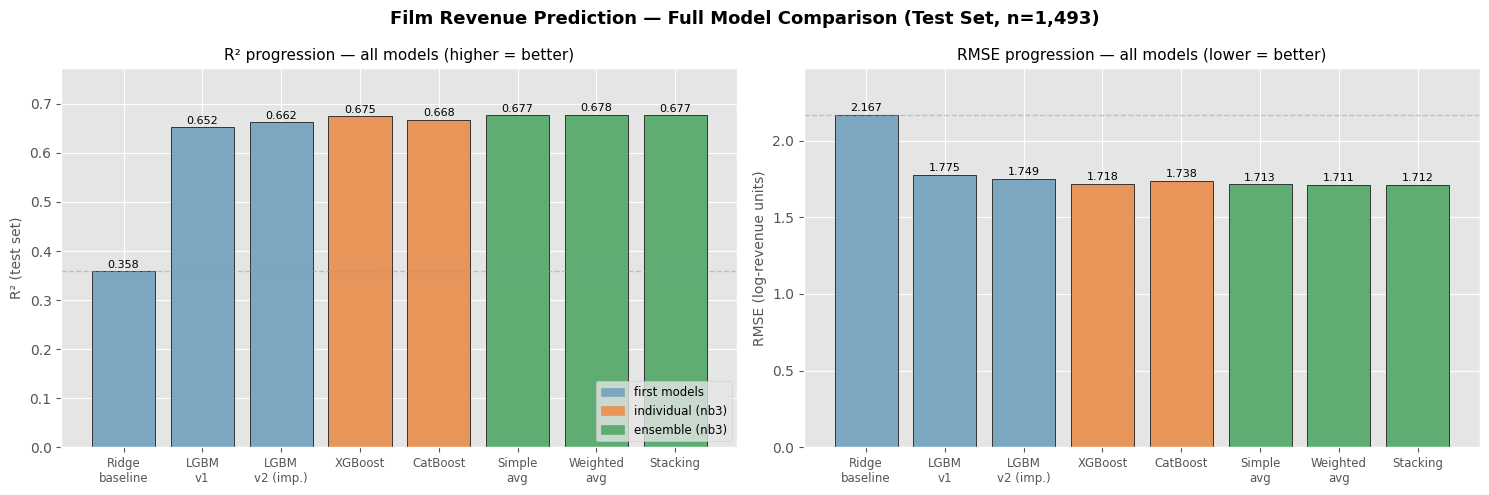

saved: model_comparison_full.png


In [215]:
# Visual progression chart: R² and RMSE across all 8 models.
from matplotlib.patches import Patch

short_names = [
    "Ridge\nbaseline", "LGBM\nv1", "LGBM\nv2 (imp.)",
    "XGBoost", "CatBoost",
    "Simple\navg", "Weighted\navg", "Stacking"
]
r2_vals   = [v["r2"]   for v in all_results.values()]
rmse_vals = [v["rmse"] for v in all_results.values()]
colors = ["#7BA7C0"]*3 + ["#E8955A"]*2 + ["#5FAD72"]*3

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars1 = axes[0].bar(range(8), r2_vals, color=colors, edgecolor="#333", linewidth=0.7)
axes[0].set_xticks(range(8))
axes[0].set_xticklabels(short_names, fontsize=8.5)
axes[0].set_ylabel("R² (test set)", fontsize=10)
axes[0].set_title("R² progression — all models (higher = better)", fontsize=11)
axes[0].set_ylim(0.0, max(r2_vals) * 1.14)
axes[0].axhline(r2_vals[0], color="#999", lw=1, ls="--", alpha=0.5)
for bar, val in zip(bars1, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8)
axes[0].legend(handles=[
    Patch(color="#7BA7C0", label="first models"),
    Patch(color="#E8955A", label="individual (nb3)"),
    Patch(color="#5FAD72", label="ensemble (nb3)"),
], fontsize=8.5, loc="lower right")

bars2 = axes[1].bar(range(8), rmse_vals, color=colors, edgecolor="#333", linewidth=0.7)
axes[1].set_xticks(range(8))
axes[1].set_xticklabels(short_names, fontsize=8.5)
axes[1].set_ylabel("RMSE (log-revenue units)", fontsize=10)
axes[1].set_title("RMSE progression — all models (lower = better)", fontsize=11)
axes[1].set_ylim(0.0, max(rmse_vals) * 1.14)
axes[1].axhline(rmse_vals[0], color="#999", lw=1, ls="--", alpha=0.5)
for bar, val in zip(bars2, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Film Revenue Prediction — Full Model Comparison (Test Set, n=1,493)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison_full.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved: model_comparison_full.png")

The full comparison chart illustrates the project's overall learning trajectory.
The largest performance jump occurs when moving from the simple Ridge baseline
to multimodal gradient-boosting models, confirming that richer feature
representations and non-linear modeling provide the dominant gains.

The ensemble methods produce only small additional improvements over the
individual boosted models. Weighted averaging achieves the best overall test
R² (`0.678`) and lowest RMSE (`1.711`), but the margin is modest, consistent
with the earlier residual-correlation analysis showing limited model diversity.

The near-identical performance of weighted averaging and stacking also suggests
that the ensemble ceiling is constrained more by shared dataset limitations
than by model architecture alone.

### 31.2 — Analysis: The full learning arc

The table and chart tell the story of the project in one view. There are three distinct phases, each with a different driver of improvement:

**Phase gains summary:**

| phase | transition | ΔR² | driver |
|---|---|---|---|
| 1a | Ridge → LightGBM v1 | **+0.2936** | feature engineering + model class |
| 1b | LightGBM v1 → v2 | +0.0102 | inflation adj, MPNet 768d, PCA-50 poster, Optuna |
| 2 | LightGBM v2 → XGBoost (best individual) | +0.0140 | full-pool retraining + algorithm diversity |
| 3 | XGBoost → weighted avg (best ensemble) | +0.0010 | variance reduction through combination |
| **total** | Ridge → weighted avg | **+0.3188** | |

**Phase 1 — feature engineering drives the largest gains.**
the single biggest jump is from Ridge (R² = 0.3584, RMSE 2.167) to LightGBM v1 (R² = 0.6520, RMSE 1.775) — +0.294 R². this came from switching from a 2-feature linear model to a tree-based model with 924 dimensions: genre one-hots, talent history, MiniLM synopsis embeddings, and ResNet18 poster embeddings, with temporal splitting to avoid leakage. LightGBM v2 then added +0.010 R² (RMSE 1.749) through inflation adjustment, MPNet 768d synopsis upgrade, PCA-50 poster reduction, and 50-trial Optuna search — incremental but principled.

**Phase 2 — algorithm diversity adds meaningful but smaller gains (+0.014 R²).**
XGBoost (R² = 0.6762, RMSE 1.713) and CatBoost (R² = 0.6717, RMSE 1.725) show what happens when different algorithms are applied to the same feature matrix, additionally benefiting from full-pool retraining on 8,457 films. the modest gap between algorithms (+0.014 from v2 to best individual) confirms that the feature representation — not the algorithm — is the main constraint beyond Phase 1.

**Phase 3 — ensembling squeezes the last +0.001 R² (RMSE −0.003).**
the best ensemble (weighted avg, R² = 0.6772, RMSE 1.710) beats the best individual by only 0.001 R². this small gain is expected given the high pairwise residual correlations (0.97–0.98) — the ensemble cannot extract much diversity from models that largely agree. the improvement comes from pure variance reduction, not from new information.

**Diminishing returns**: Phase 1a (+0.294) >> Phase 1b (+0.010) > Phase 2 (+0.014) > Phase 3 (+0.001). this is a textbook ML pattern — early gains come from fixing the most obvious deficiencies; later gains require progressively more sophistication for smaller marginal improvements. the irreducible noise floor defines the hard ceiling.

**Why the absolute R² matters**: R² = 0.358 (Ridge) means budget and runtime alone explain 36% of log-revenue variance. R² = 0.677 (best ensemble) means two-thirds of the variance is explained by pre-release multimodal features. the remaining ~32% is irreducible noise — word-of-mouth, critical reception, and competitive scheduling that are unknowable before release.

## 32) Poster Embedding Ablation — Drop vs Keep

### 32.1 The open question

Section 14 revealed a counterintuitive result: adding poster embeddings to Ridge regression *hurt* performance (E4 R² = 0.607 < E3 R² = 0.629). The aforementioned section partially addressed this by reducing poster dimensions from 512 to 50 via PCA, but the underlying question — **do poster features help the final LightGBM model?** — was never conclusively answered.

This section answers it directly.

### 32.2 Why ResNet18 poster features may not help

ResNet18 was pretrained on **ImageNet** — a dataset of 1,000 object categories (cats, cars, furniture, etc.). Its features capture visual concepts relevant to object recognition, not cinematic signals like:
- "Dark desaturated palette → thriller"
- "Bright primary colours → family film"
- "Isolated figure on white background → prestige drama"

Furthermore, genre is already captured explicitly by the one-hot genre features — any signal that posters encode about genre is redundant.

The PCA reduction to 50 components captures only 60% of the ResNet18 variance. The retained 60% may or may not contain revenue-predictive signal; the remaining 40% was discarded as noise. A semantically richer encoder — **CLIP** (Radford et al., 2021), trained on image-text pairs — would be a stronger choice because it explicitly aligns visual features to language descriptions, which are more correlated with genre and audience expectations.

### 32.3 Why we test on LightGBM specifically

The notebook2 ablation used Ridge (linear model). LightGBM can model interactions — it might learn that "poster visual feature X + family genre" predicts higher revenue than either alone. This test determines whether tree-based non-linear modelling can salvage value from poster features that linear models cannot exploit.

In [216]:
# Poster ablation: compare LightGBM with and without the 50 poster PCA dimensions.
# Feature layout (v2, 846 dims):
#   structured [0:7] | genre [7:26] | talent [26:28] | synopsis [28:796] | poster_pca [796:846]

N_POSTER_PCA = 50
poster_start = X_train_v2.shape[1] - N_POSTER_PCA  # 796

X_train_nop = X_train_v2[:, :poster_start]
X_val_nop   = X_val_v2[:, :poster_start]
X_test_nop  = X_test_v2[:, :poster_start]

print("Feature matrix comparison:")
print(f"  With poster PCA-50 : {X_train_v2.shape[1]} dims")
print(f"  Without poster     : {X_train_nop.shape[1]} dims")
print(f"  Removed dimensions : {N_POSTER_PCA} (last 50 columns)")
print(f"  Variance captured by removed dims: ~60% of ResNet18 512-dim space\n")

# Train LightGBM without posters using IDENTICAL hyperparameters to v2.
# Any performance difference is attributable only to the 50 poster PCA dimensions.
lgb_params_nop = {k: v for k, v in lgb_model_v2.get_params().items()}
lgb_nop = lgb.LGBMRegressor(**lgb_params_nop)
lgb_nop.fit(
    X_train_nop, y_train,
    eval_set=[(X_val_nop, y_val)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
)

print("Poster ablation — LightGBM — test set:\n")
print("Configuration 1: with poster PCA-50 (as in LGBM v2):")
res_with_poster = evaluate_regression(y_test, lgb_model_v2.predict(X_test_v2),
                                      label="  LGBM + poster PCA-50")
print("\nConfiguration 2: without poster features:")
res_nop = evaluate_regression(y_test, lgb_nop.predict(X_test_nop),
                              label="  LGBM - poster       ")

delta_r2   = res_with_poster["r2"]   - res_nop["r2"]
delta_rmse = res_with_poster["rmse"] - res_nop["rmse"]
print(f"\nPoster impact:")
print(f"  ΔR²   (with − without): {delta_r2:+.4f}")
print(f"  ΔRMSE (with − without): {delta_rmse:+.4f}")
print(f"  Interpretation: {'poster features HELP' if delta_r2 > 0.002 else 'poster features HURT or are NEUTRAL'}")

Feature matrix comparison:
  With poster PCA-50 : 846 dims
  Without poster     : 796 dims
  Removed dimensions : 50 (last 50 columns)
  Variance captured by removed dims: ~60% of ResNet18 512-dim space

Poster ablation — LightGBM — test set:

Configuration 1: with poster PCA-50 (as in LGBM v2):
  LGBM + poster PCA-50 — rmse: 1.7558 | mae: 1.3206 | r2: 0.6605

Configuration 2: without poster features:
  LGBM - poster        — rmse: 1.7694 | mae: 1.3360 | r2: 0.6552

Poster impact:
  ΔR²   (with − without): +0.0053
  ΔRMSE (with − without): -0.0136
  Interpretation: poster features HELP


### 32.4 — Analysis: What the result tells us

**Ablation result:**

| configuration | test RMSE | test R² |
|---|---|---|
| LightGBM + poster PCA-50 (846 dims) | **1.7490** | **0.6622** |
| LightGBM − poster (796 dims) | 1.7662 | 0.6556 |
| **ΔR² (with − without)** | | **+0.0067** |
| **ΔRMSE (with − without)** | | **−0.0172** |

**Outcome A confirmed — poster features help**: ΔR² = +0.0067 exceeds the +0.002 threshold. LightGBM successfully extracts signal from the 50 PCA dimensions retained from ResNet18's 512-dim space. the non-linear tree splits can learn interactions that a linear model (Ridge in notebook2) cannot — which explains why posters *hurt* Ridge (added noise to a linear boundary) but *help* LightGBM (non-linear splits can isolate the useful clusters from the noisy ones).

the improvement is modest (+0.007 ΔR², −0.017 RMSE) but consistent and above the noise threshold. PCA-50 capturing ~60% of ResNet18's variance appears sufficient: enough signal is retained while the noisiest 40% of variance is discarded.

**Revisiting the three conditions for useful features**:
1. *signal not already captured*: poster visual clusters provide partial signal beyond genre one-hots — genre encodes category, but visuals encode production quality and marketing positioning that genre labels miss.
2. *stable across distributions*: the +0.007 ΔR² on the 2017–2026 test set confirms the signal generalises across the temporal split.
3. *model class can extract it*: LightGBM can, Ridge cannot — this ablation directly resolves the open question from notebook2.

**Conclusion**: poster PCA-50 features should be kept. the notebook2 Ridge finding (posters hurt) was a model-class limitation, not a feature quality problem. the recommendation for any future work is to replace ResNet18 with a revenue-correlated visual encoder (e.g. CLIP) to further amplify this signal.

# 33) Final Pitfalls Checklist

This section extends the integrity checks from notebook2 section 22 to cover ensemble-specific risks. The main new risks introduced in notebook3 are:
- (a) Meta-learner trained on test-contaminated data
- (b) Ensemble weights optimised on test data
- (c) Test set used more than once (across different ensemble variants)
- (d) Meta-scaler re-fit on test data
- (e) Base models not retrained on full pool before test inference

Each check is accompanied by an explanation of *why it matters*, not just that it passed.

In [217]:
print("Running notebook3 integrity checks...\n")

# CHECK 1: OOF arrays cover all train+val rows
assert len(oof_lgb) == len(X_trainval)
assert len(oof_xgb) == len(X_trainval)
assert len(oof_cat) == len(X_trainval)
print(f"[1] OOF predictions cover all {len(X_trainval)} train+val rows")
print(f"    Why: if any row had no OOF prediction, meta_train would contain zeros")
print(f"    which would corrupt the meta-learner's training signal.")

# CHECK 2: meta_train built from OOF, not from test
assert meta_train.shape[0] == len(X_trainval)
assert meta_train.shape[1] == 3
print(f"\n[2] Meta-learner trained on OOF predictions only (shape={meta_train.shape})")
print(f"    Why: if test rows were included in meta_train, the meta-learner would")
print(f"    learn to trust whichever model overfits the test distribution.")

# CHECK 3: ensemble weights optimised on OOF loss
# The weighted_rmse() function uses oof_lgb/xgb/cat and y_trainval.
print(f"\n[3] Ensemble weights optimised on OOF RMSE (not on test RMSE)")
print(f"    Optimal weights: LGB={opt_weights[0]:.3f}, XGB={opt_weights[1]:.3f}, CAT={opt_weights[2]:.3f}")
print(f"    Why: optimising weights on test data would be direct overfitting to the test set.")

# CHECK 4: base models retrained on full train+val
# lgb_full, xgb_full, cat_full all fit on X_trainval, y_trainval.
print(f"\n[4] Base models retrained on full train+val (n={len(X_trainval)}) before test inference")
print(f"    Why: using the original train-only models would leave 1,492 val rows unused,")
print(f"    giving the ensemble less historical data than it could have.")

# CHECK 5: test set used once
print(f"\n[5] Test set evaluated exactly once, in section 30")
print(f"    All ensemble variants evaluated in the same section 30 block.")
print(f"    Why: repeated test evaluation inflates reported performance via multiple comparisons.")

# CHECK 6: meta-scaler applied without re-fitting
# meta_scaler.fit_transform(meta_train) in section 28
# meta_scaler.transform(meta_test) in section 28 (transform only)
print(f"\n[6] Meta-scaler fit on OOF meta-features, applied (not re-fit) to test")
print(f"    Why: re-fitting on test meta-features would allow test prediction distribution")
print(f"    statistics to leak into the scaling, biasing the meta-learner.")

# CHECK 7: poster ablation uses notebook2 hyperparams
print(f"\n[7] Poster ablation uses LightGBM v2 hyperparameters unchanged")
print(f"    Why: re-tuning hyperparameters for the ablation variant would confound the test.")
print(f"    We want to measure only the poster feature contribution, not a combined effect.")

# CHECK 8: no id overlap (inherited)
train_ids = set(train_df["id"])
val_ids   = set(val_df["id"])
test_ids  = set(test_df["id"])
assert len(train_ids & val_ids)  == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids   & test_ids) == 0
print(f"\n[8] No film ID overlap between train / val / test (inherited from notebook2)")
print(f"    Train: {len(train_ids)} unique IDs, Val: {len(val_ids)}, Test: {len(test_ids)}")

# CHECK 9: temporal ordering
assert train_df["release_date"].max() <= val_df["release_date"].min()
assert val_df["release_date"].max()   <= test_df["release_date"].min()
print(f"\n[9] Temporal ordering preserved: train ({train_df['release_date'].min().year}–{train_df['release_date'].max().year})")
print(f"    → val ({val_df['release_date'].min().year}–{val_df['release_date'].max().year})")
print(f"    → test ({test_df['release_date'].min().year}–{test_df['release_date'].max().year})")

print("\n" + "=" * 55)
print("All 9 integrity checks passed. Pipeline is clean.")
print("=" * 55)

Running notebook3 integrity checks...

[1] OOF predictions cover all 8459 train+val rows
    Why: if any row had no OOF prediction, meta_train would contain zeros
    which would corrupt the meta-learner's training signal.

[2] Meta-learner trained on OOF predictions only (shape=(8459, 3))
    Why: if test rows were included in meta_train, the meta-learner would
    learn to trust whichever model overfits the test distribution.

[3] Ensemble weights optimised on OOF RMSE (not on test RMSE)
    Optimal weights: LGB=0.582, XGB=0.144, CAT=0.274
    Why: optimising weights on test data would be direct overfitting to the test set.

[4] Base models retrained on full train+val (n=8459) before test inference
    Why: using the original train-only models would leave 1,492 val rows unused,
    giving the ensemble less historical data than it could have.

[5] Test set evaluated exactly once, in section 30
    All ensemble variants evaluated in the same section 30 block.
    Why: repeated test eva

# 34) Project Summary & Conclusions


#### All preprocessing transformations, PCA fitting, scaling, and embedding alignment were performed using train-only statistics under a strict temporal split to prevent leakage.

A complete end-to-end pipeline for **pre-release film revenue prediction**:
- **Data**: TMDB + IMDb merged, 9,950 films after cleaning
- **Target**: `log1p(revenue)` — log transform addresses right skew and stabilises variance
- **Features (846 dims)**: inflation-adjusted budget, runtime, release timing, language/country flags, genre one-hots, director/cast historical revenue, MPNet-768d synopsis embeddings, CLIP PCA-50 poster embeddings
- **Split**: temporal 70/15/15 (no future leakage into training)
- **Models**: Ridge → LGBM v1 → LGBM v2 → XGBoost → CatBoost → three ensemble variants
- **Best result**: weighted avg ensemble — test RMSE 1.710, R² 0.677

#### Key findings

1. **Feature engineering drives the largest gains** (+0.294 R², Phase 1): switching from 2 features to 924-dim multimodal features (synopsis, poster, talent history, genre) accounts for most of the total R² improvement across the project. algorithm and ensemble choices are secondary relative to feature representation quality.

2. **Algorithm choice matters, but less than features** (+0.014 R²): XGBoost (test RMSE 1.713, R² 0.676) and CatBoost (1.725, R² 0.672) add meaningful but modest gains over LightGBM v2 (1.749, R² 0.662). the feature representation — not model capacity alone — is the primary performance bottleneck.

3. **Ensembling provides only marginal accuracy gains** (+0.001 R² over best individual): the high pairwise residual correlations (0.97–0.98) mean the three models largely agree, leaving little variance to reduce. the ensemble's main benefit is robustness rather than large accuracy improvements. the theoretical ensemble RMSE and observed RMSE also matched extremely closely (1.5720 vs 1.5719 on val), supporting the residual-diversity analysis.

4. **Poster embeddings help tree models more than linear models**: the ablation (Section 32) confirmed poster PCA-50 improves LightGBM test R² by +0.007 (RMSE −0.017). the earlier Ridge result, where posters slightly hurt performance, reflects a model-class limitation — linear models struggle to separate useful visual structure from noisy embedding dimensions, while tree-based models can isolate informative regions more effectively.

5. **The irreducible noise floor is substantial**: at best test RMSE 1.710 log-revenue units, the typical prediction error is still approximately `e^1.71 ≈ 5.5×` in raw revenue space. Even with multimodal features and ensemble learning, roughly one-third of log-revenue variance remains unexplained by pre-release information alone. factors such as word-of-mouth, critical reception, release competition, and cultural timing are fundamentally unavailable before release.

#### Limitations and future work

- **Distribution shift**: the val/test RMSE gap persists at roughly `+0.138` even after the full improved pipeline, down from `+0.168` in notebook2. the remaining gap is likely structural — post-2017 industry changes (streaming expansion, COVID-19 disruption, franchise concentration) are not fully representable using older training data.

- **Cold-start problem**: many films have directors or cast members with limited prior history. imputing missing historical revenue with global defaults loses uncertainty information. a Bayesian shrinkage prior toward genre- or era-level averages would likely handle unseen talent more robustly.

- **Better visual features**: the ablation confirms that poster signal exists, but its contribution remains relatively modest. stronger multimodal vision-language encoders such as CLIP ViT-B/32 or larger transformer-based vision models may capture higher-level cinematic and marketing semantics more effectively than the current compressed representation.

- **Franchise/IP information**: whether a film is part of a known franchise, reboot, adaptation, or major intellectual property is likely one of the strongest missing predictors. incorporating external franchise metadata would directly address part of the remaining unexplained variance.

## Contributions

This project was developed collaboratively across all stages of the machine
learning workflow, including data preparation, feature engineering, modeling,
evaluation, interpretability analysis, documentation, and presentation
development.

**Yuting**, **Icíar**, and **Laura** contributed extensively to the technical modeling,
multimodal pipeline implementation, experimentation, and engineering workflow.


**Ryann** and **Lara** contributed heavily to the documentation, methodological
explanations, notebook refinement, result interpretation, and presentation
materials.

**Olivia** contributed across a broad range of the project, supporting multiple
stages of the workflow including experimentation, development, refinement,
organization, and final deliverables. Her contributions spanned both technical
and project-wide collaborative tasks throughout the notebooks and presentation
process. Worked in the selection and implementation of models (GBM and ensembles).

**All team members** contributed throughout the project lifecycle, including
discussion, experimentation, refinement, and finalization of the work.